In [ ]:
# Get daily constraint ranked by the abs RT - DA 
from functions import (
    get_recent_constraint_mvalue,
    get_node_dfax_from_constraint_num,
    get_hourly_mvalue_for_constraint_num,
    get_constraint_node_prices_from_constraint_num,
    get_constraints_node_price,
    get_metrics_for_nodes,
    get_recent_direction_accuracy,
    get_weather_date,
    predict_tomorrow_percentile,
    analyze_constraint_by_zone,
    plot_constraint_seasonality,
    plot_recent_hourly_distribution,
)
import pandas as pd

In [2]:
now = pd.Timestamp.now(tz='US/Central')
days_ahead = 2 if now.hour >= 10 else 1
bid_dt = (now + pd.Timedelta(days=days_ahead)).strftime('%Y-%m-%d')
print(bid_dt)

2026-06-11


In [ ]:
dt = (pd.Timestamp(bid_dt) - pd.Timedelta(days=7)).strftime('%Y-%m-%d')
mvalue= get_recent_constraint_mvalue(dt, dt)
dfax= get_node_dfax_from_constraint_num(mvalue)

start_dt: 2026-06-10, end_dt: 2026-06-10, Market: SPP
Fetching RT mvalues...
Fetching DA mvalues...
RT constraints: 21, DA constraints: 103
Fetching constraint details...


,oops_constraint_num,rt_total,da_total,rt_da,abs_rt_da_diff,monitored,contingency
0,878969,0.0000,-9497.9755,9497.9755,9497.9755,lnlenexa-shwnmsn5,kcpl:pflumm5craig:161:1:7
1,776592,0.0000,-5799.6488,5799.6488,5799.6488,xfmrduncan-duncan,wfec:anadarkofletch3comanch2:138
2,850374,0.0000,-4867.7505,4867.7505,4867.7505,lnmaud_tap-earlsbrh,okge:muskogeeseminole:345:1:11
3,445929,0.0000,-3834.6813,3834.6813,3834.6813,lnquail-skyln,okge:arcad7nowst1:345:1:11
4,649753,0.0000,-3805.7336,3805.7336,3805.7336,lnrussett-sbrown,okge:brown2bodlecaney1:138:7:34
5,880643,0.0000,-3499.6451,3499.6451,3499.6451,lneeur-vaug_rev23,wr:n345neordg:345:1:11
6,503288,-2578.0224,0.0000,-2578.0224,2578.0224,lnlenexa-shwnmsn5,kcpl:pflumm5craig:161:1:7
7,775436,0.0000,-2489.6192,2489.6192,2489.6192,xfmrsiouxcy-siouxcy,waue:siouxcyxfkv5a3:23016113.8
8,805090,0.0000,-2163.8736,2163.8736,2163.8736,xfmrnowst1-nowst1,okge:nowst1xfxf3t:34513813.8:3
9,791481,0.0000,-2065.4853,2065.4853,2065.4853,lnosage_og-webbtap4,grdaokge:clevlnd7whtetail:345:1:


RT active constraint-days: 466
DA active constraint-days: 1340
   oops_constraint_num          dt  hr  rt_mvalue  da_mvalue      rt_da
0               441249  2025-01-17   1        0.0  -877.6421   877.6421
1               441249  2025-01-17   2        0.0  -896.0814   896.0814
2               441249  2025-01-17   3        0.0  -827.9997   827.9997
3               441249  2025-01-17   4        0.0  -813.1219   813.1219
4               441249  2025-01-17   5        0.0 -1045.9326  1045.9326

Merged hourly rows: 15766


,oops_constraint_num,dt,hr,rt_mvalue,da_mvalue,rt_da,monitored,contingency
0,441249,2025-01-17,1,0.0000,-877.6421,877.6421,lnaur1241-rdspg5,cswsspa:eurekaspeurk_spabeaver1
1,441249,2025-01-17,2,0.0000,-896.0814,896.0814,lnaur1241-rdspg5,cswsspa:eurekaspeurk_spabeaver1
2,441249,2025-01-17,3,0.0000,-827.9997,827.9997,lnaur1241-rdspg5,cswsspa:eurekaspeurk_spabeaver1
3,441249,2025-01-17,4,0.0000,-813.1219,813.1219,lnaur1241-rdspg5,cswsspa:eurekaspeurk_spabeaver1
4,441249,2025-01-17,5,0.0000,-1045.9326,1045.9326,lnaur1241-rdspg5,cswsspa:eurekaspeurk_spabeaver1
...,...,...,...,...,...,...,...,...
15761,886006,2026-06-09,22,-12.1625,0.0000,-12.1625,lnwashit1-sw_sta,okge:normhllminco:345:1:13
15762,886006,2026-06-09,23,-9.4935,0.0000,-9.4935,lnwashit1-sw_sta,okge:normhllminco:345:1:13
15763,886006,2026-06-09,24,-17.4637,0.0000,-17.4637,lnwashit1-sw_sta,okge:normhllminco:345:1:13
15764,886006,2026-06-10,1,-8.0818,0.0000,-8.0818,lnwashit1-sw_sta,okge:normhllminco:345:1:13


Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']


monitored
lneeur-vaug_rev23               5
lnftthomp-ftrandl               8
lnommarlo4-rsh_sprg_rev23      14
lnctnwd1-pine                  43
xfmrnowst1-nowst1              66
lnlenexa-shwnmsn5              92
lnmaud_tap-earlsbrh           104
lnwashit1-sw_sta              127
xfmrlex1611-lex1611           299
xfmrsiouxcy-siouxcy           459
lnfirstcrk-roanrdge           527
lnaur1241-rdspg5              658
lnquail-skyln                 820
xfmrduncan-duncan            1463
lnosage_og-webbtap4          1821
lnrussett-sbrown             5538


Constraint  : 'lneeur-vaug_rev23'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0003  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lneeur-vaug_rev23,4,rz4_spp_res_zonal_wind_forecast_f,0.0003,0.0,-1.0
1,lneeur-vaug_rev23,4,rz4_spp_res_zonal_load_forecast_f,0.0003,0.0,-1.0


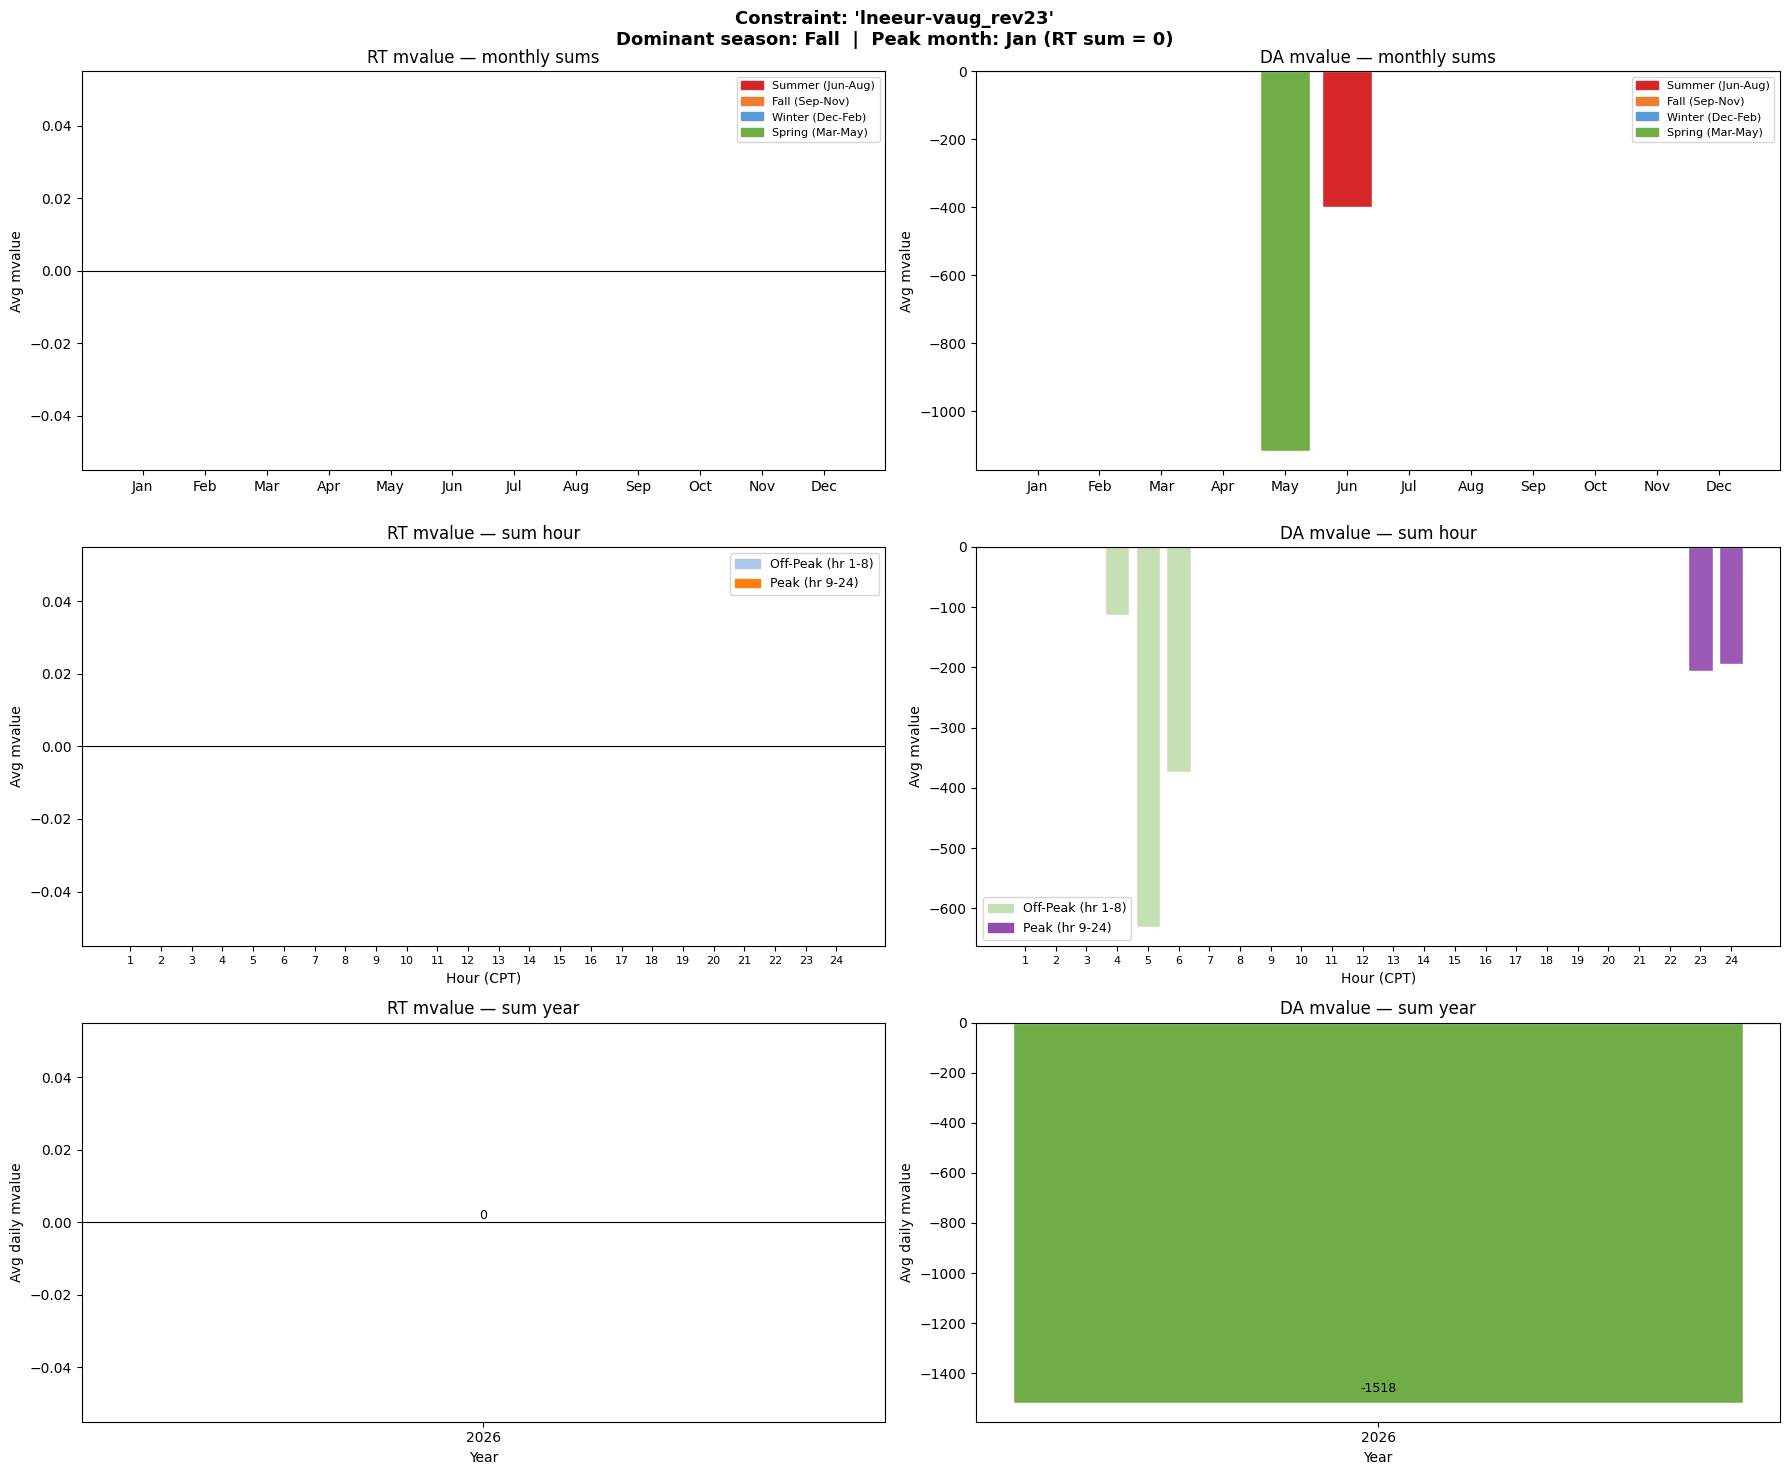

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):    -400.28  |  off-peak (hr 1-8):   -1117.59
'lneeur-vaug_rev23'  |  2026-05-30 → 2026-06-09  |  1 days


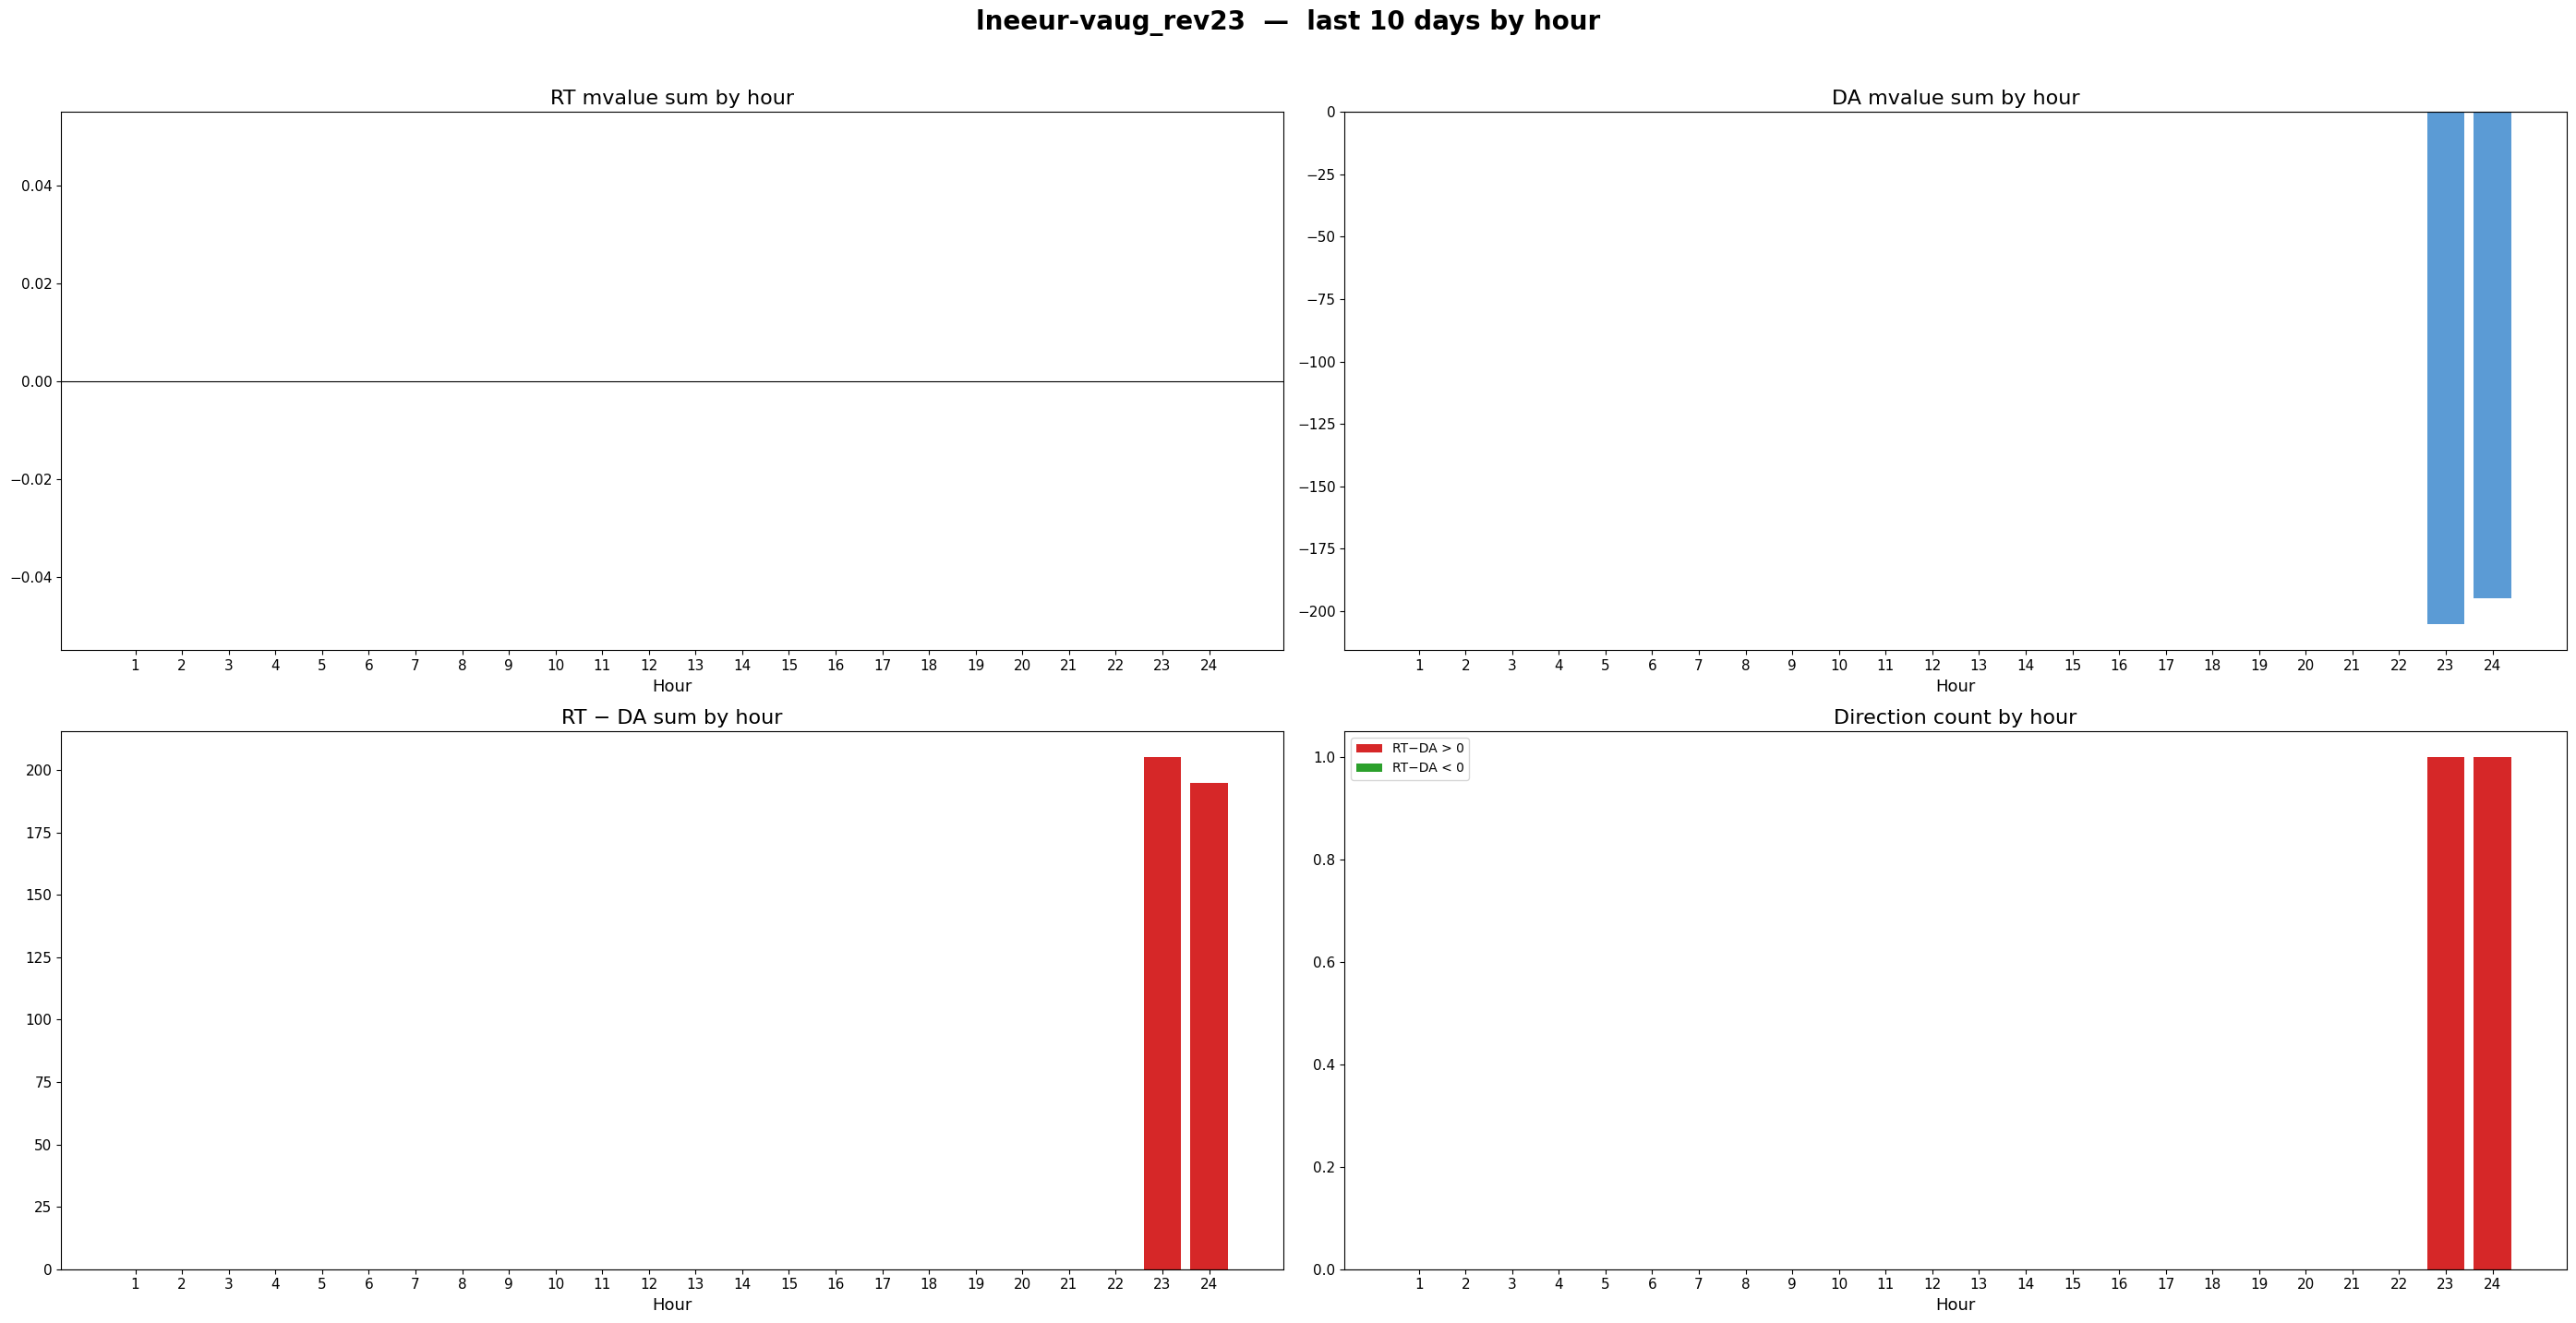

lneeur-vaug_rev23 could not find the dfax value


Constraint  : 'lnftthomp-ftrandl'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0005  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnftthomp-ftrandl,4,rz4_spp_res_zonal_load_forecast_f,0.0005,0.0023,4.0
0,lnftthomp-ftrandl,4,rz4_spp_res_zonal_wind_forecast_f,0.0005,0.0000,-1.0


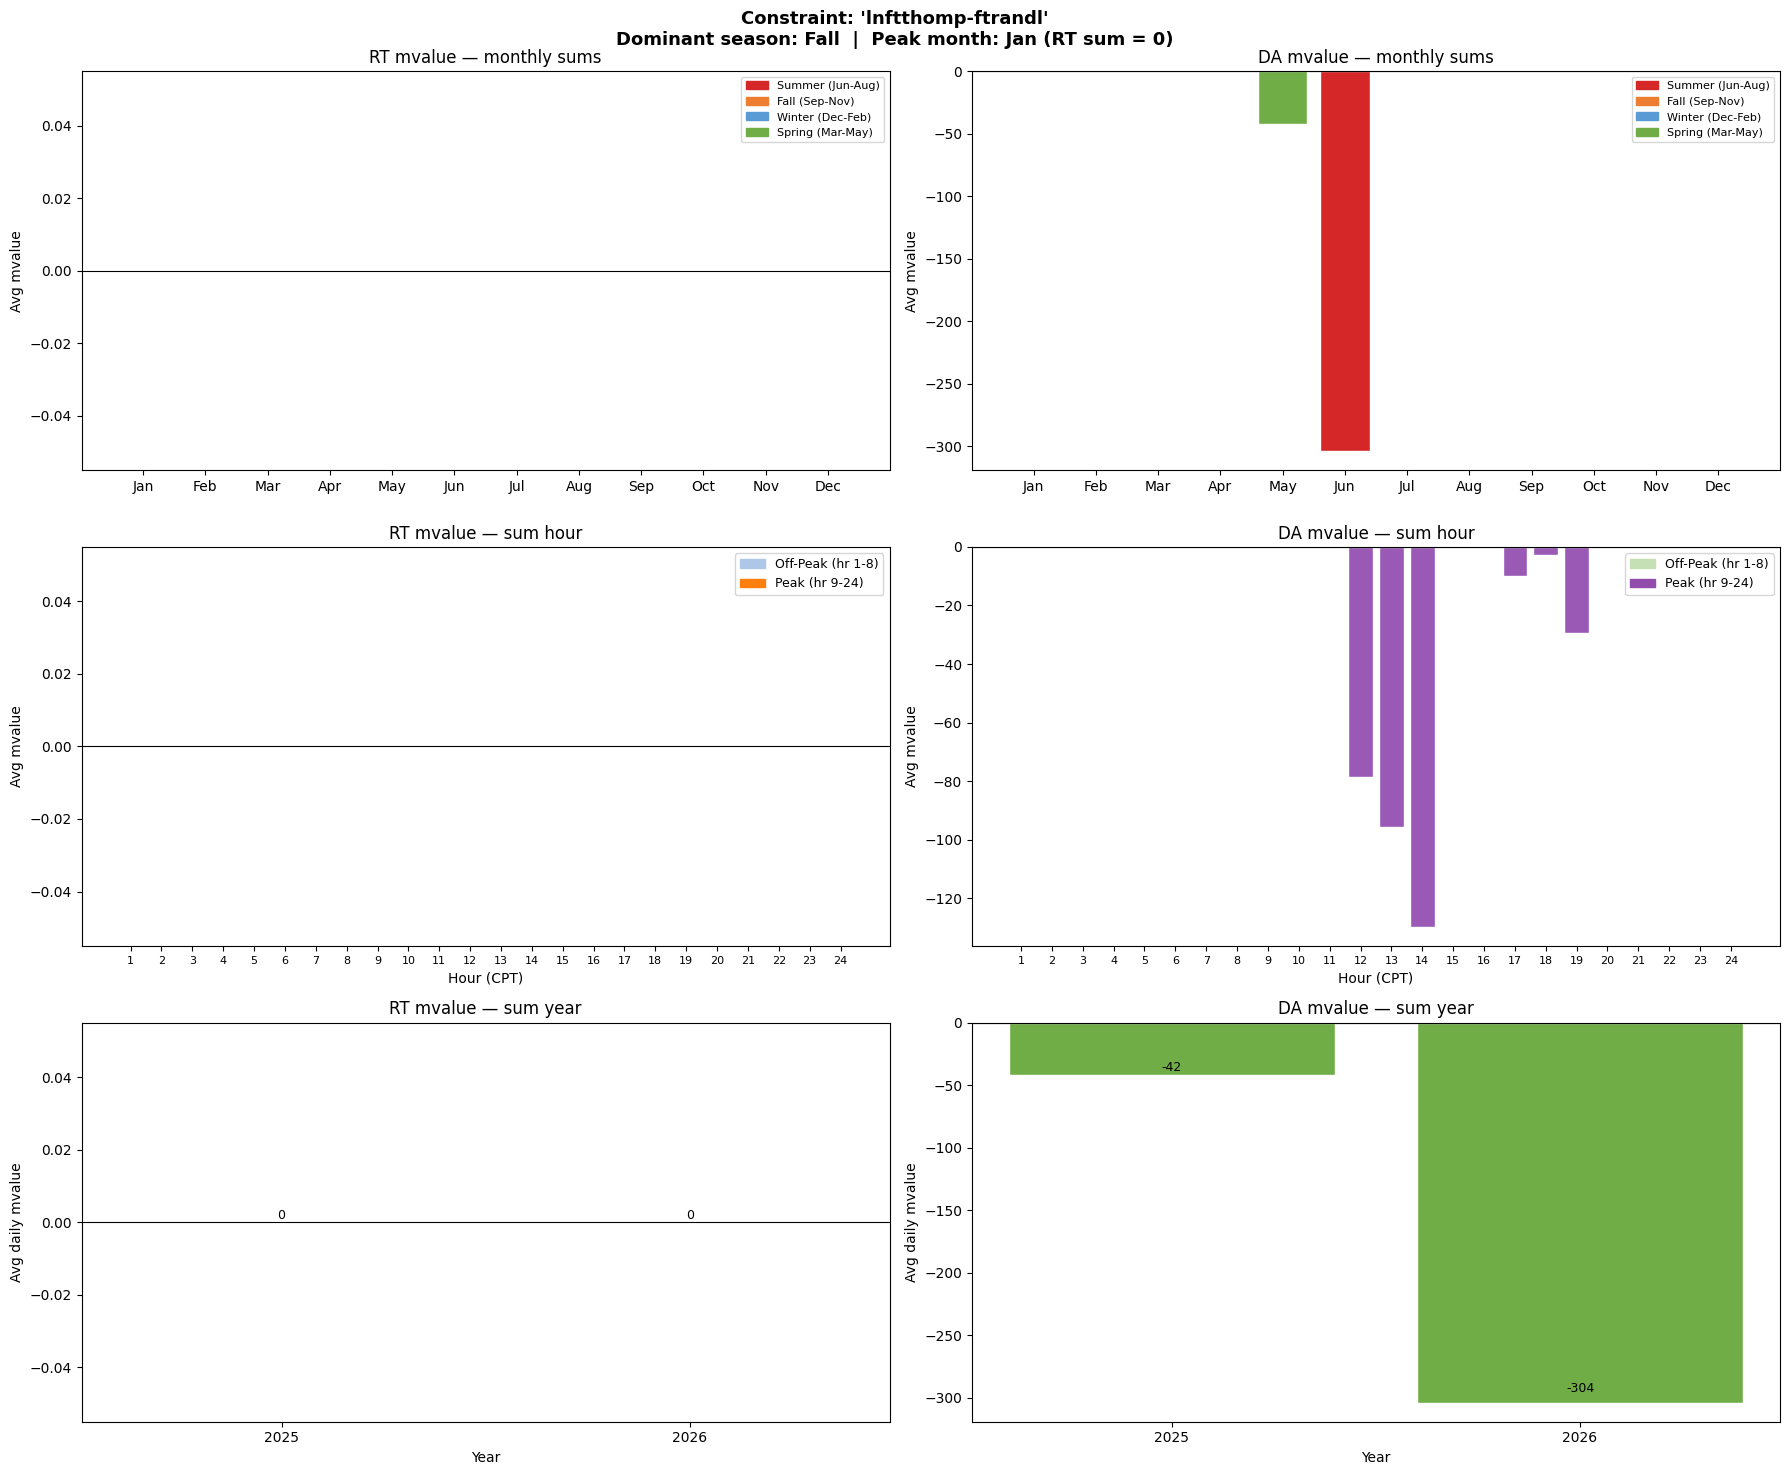

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):    -346.00  |  off-peak (hr 1-8):       0.00
'lnftthomp-ftrandl'  |  2026-05-30 → 2026-06-09  |  2 days


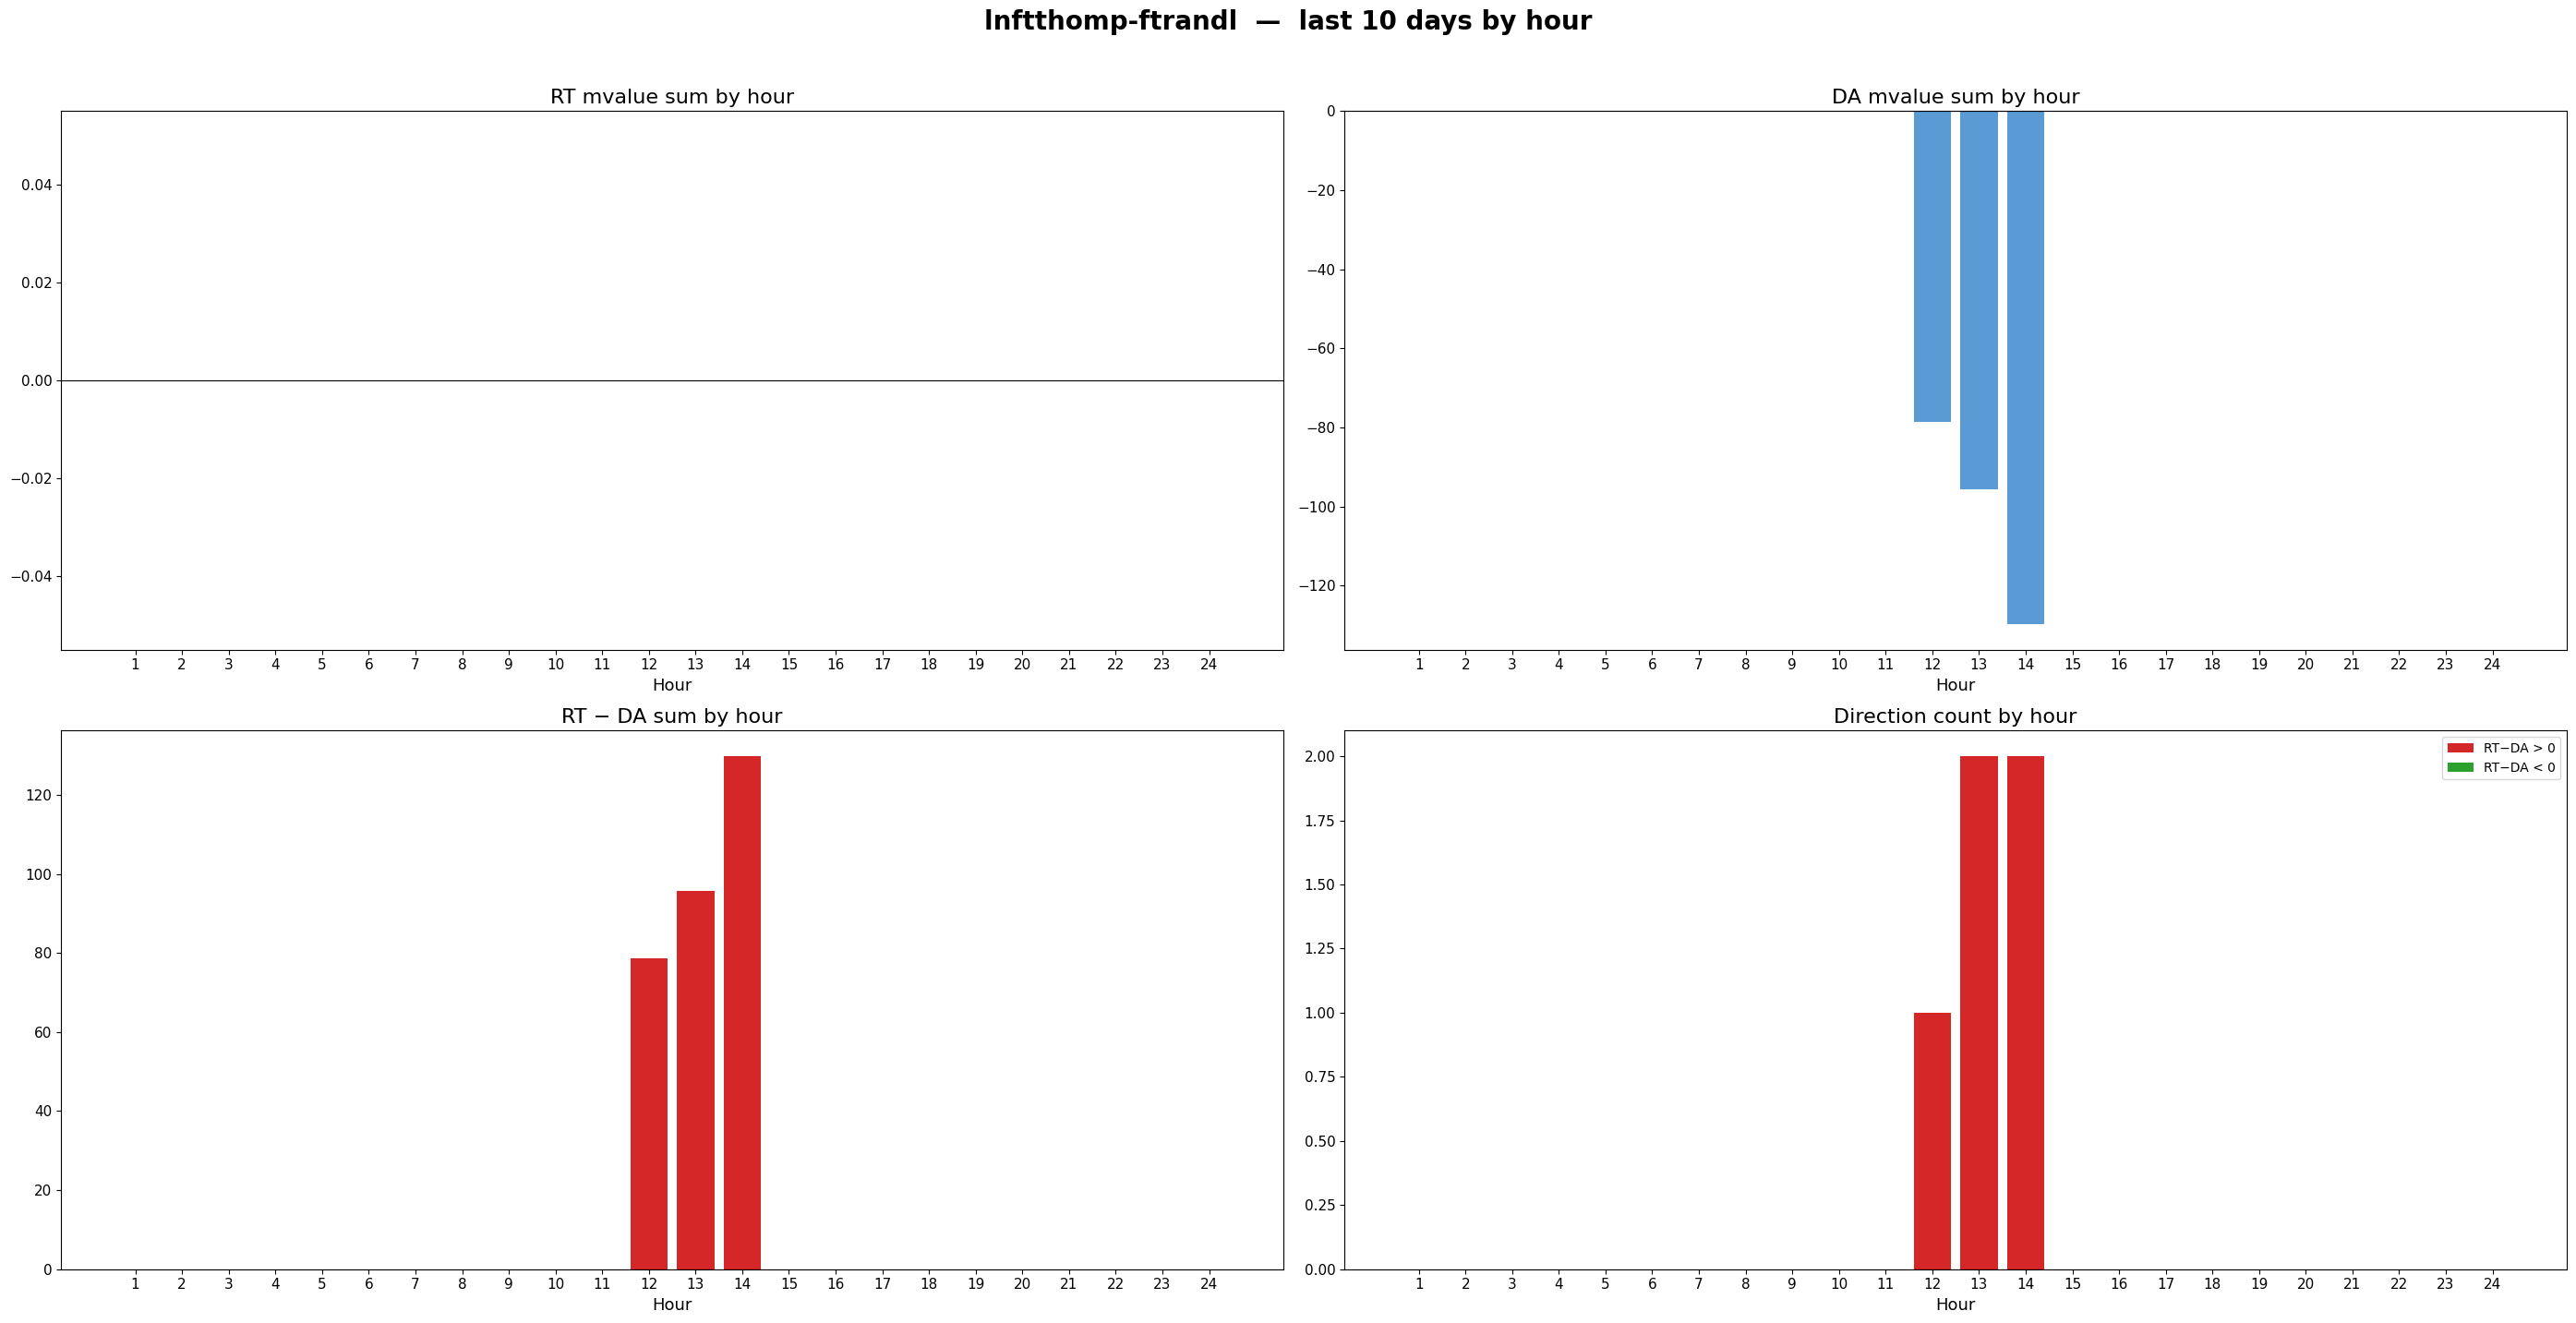

lnftthomp-ftrandl could not find the dfax value


Constraint  : 'lnommarlo4-rsh_sprg_rev23'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0008  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnommarlo4-rsh_sprg_rev23,4,rz4_spp_res_zonal_load_forecast_f,0.0008,0.0126,14.71
0,lnommarlo4-rsh_sprg_rev23,4,rz4_spp_res_zonal_wind_forecast_f,0.0008,0.0011,0.43


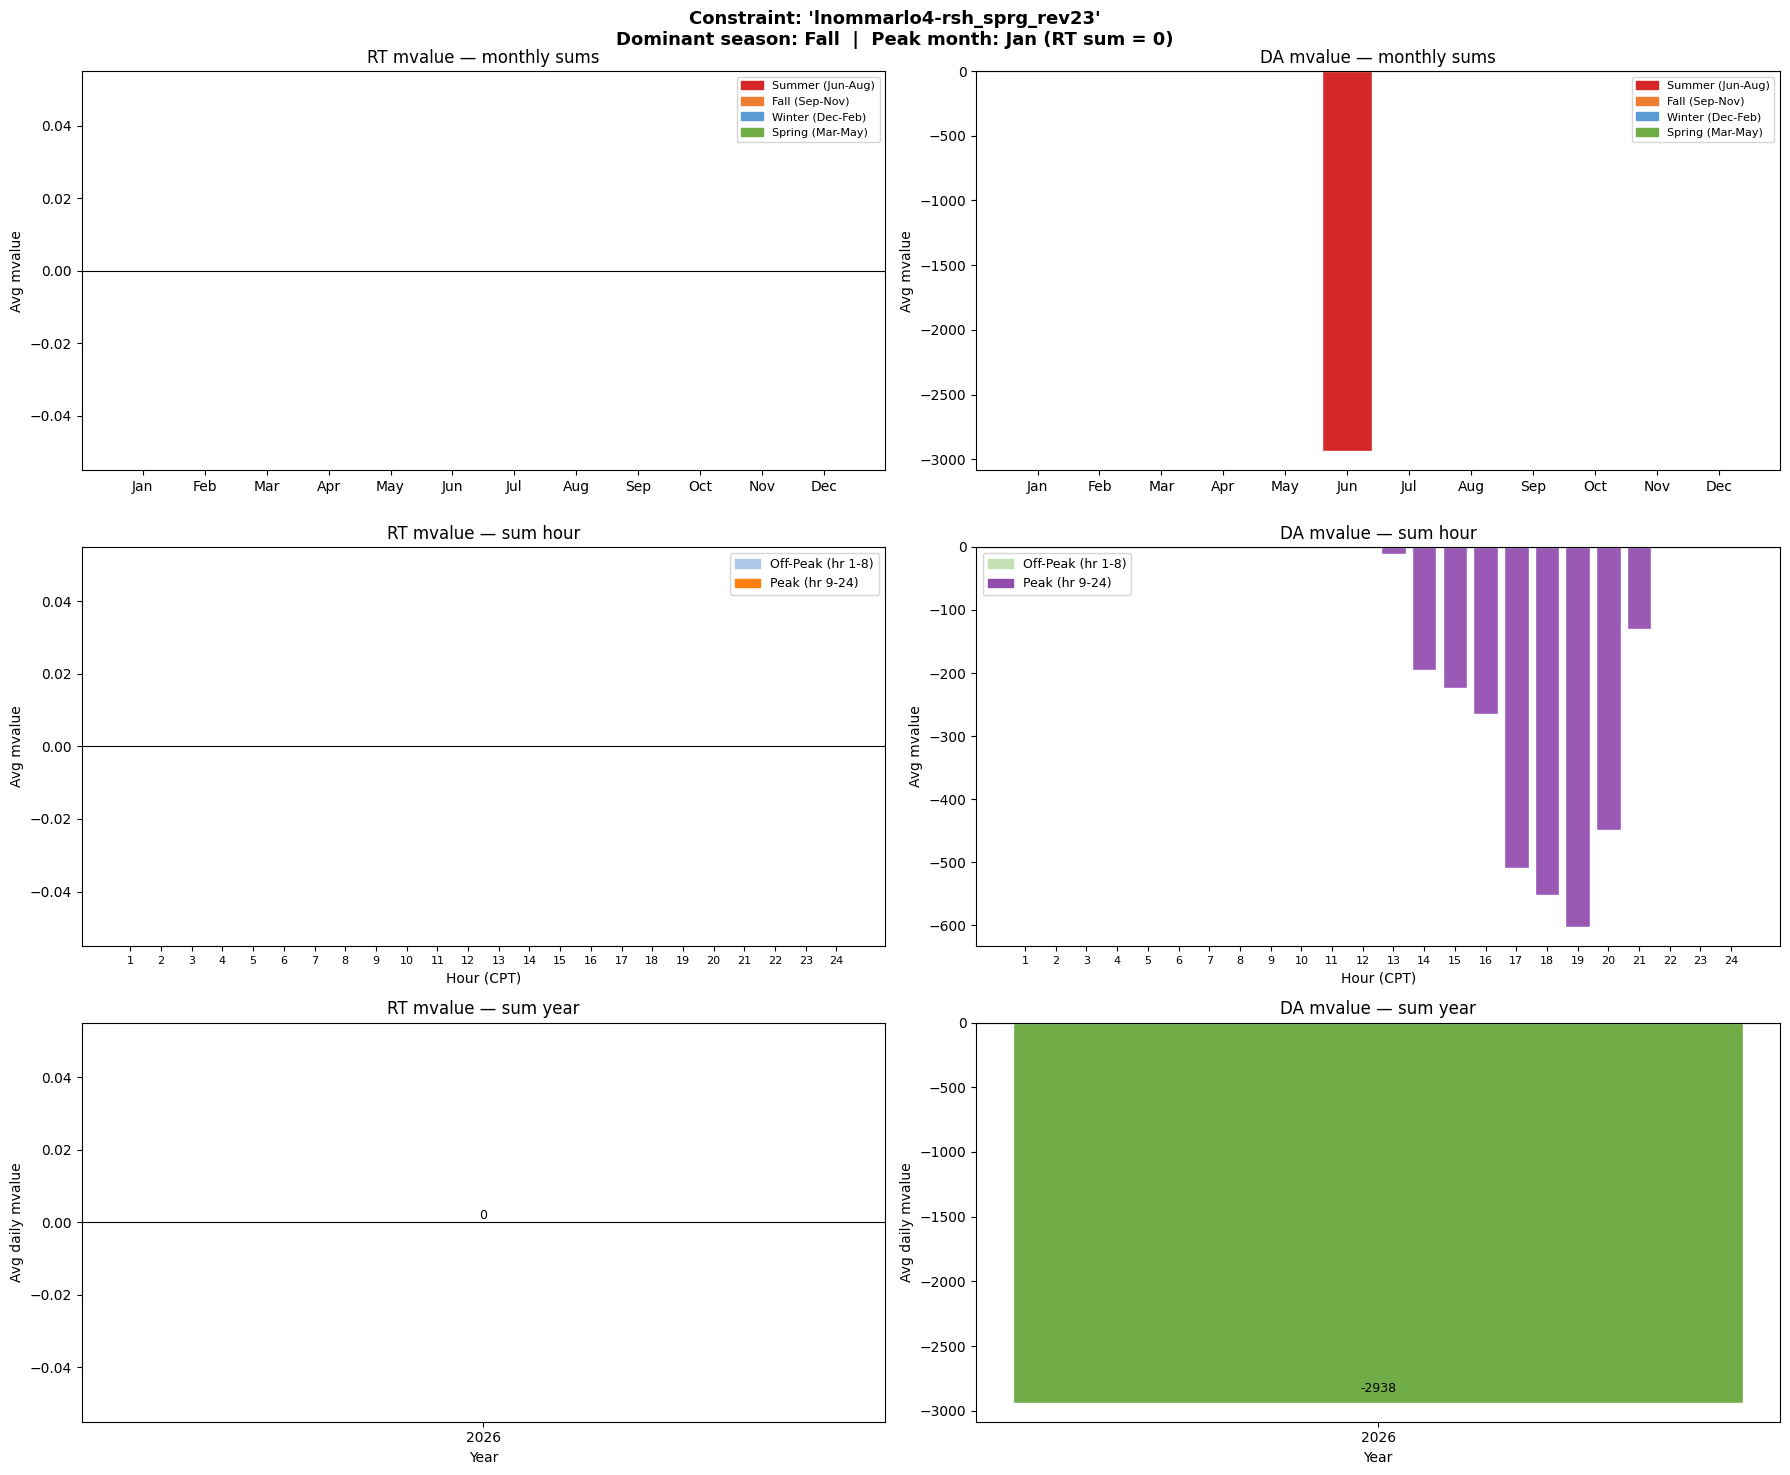

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):   -2938.41  |  off-peak (hr 1-8):       0.00
'lnommarlo4-rsh_sprg_rev23'  |  2026-05-30 → 2026-06-09  |  2 days


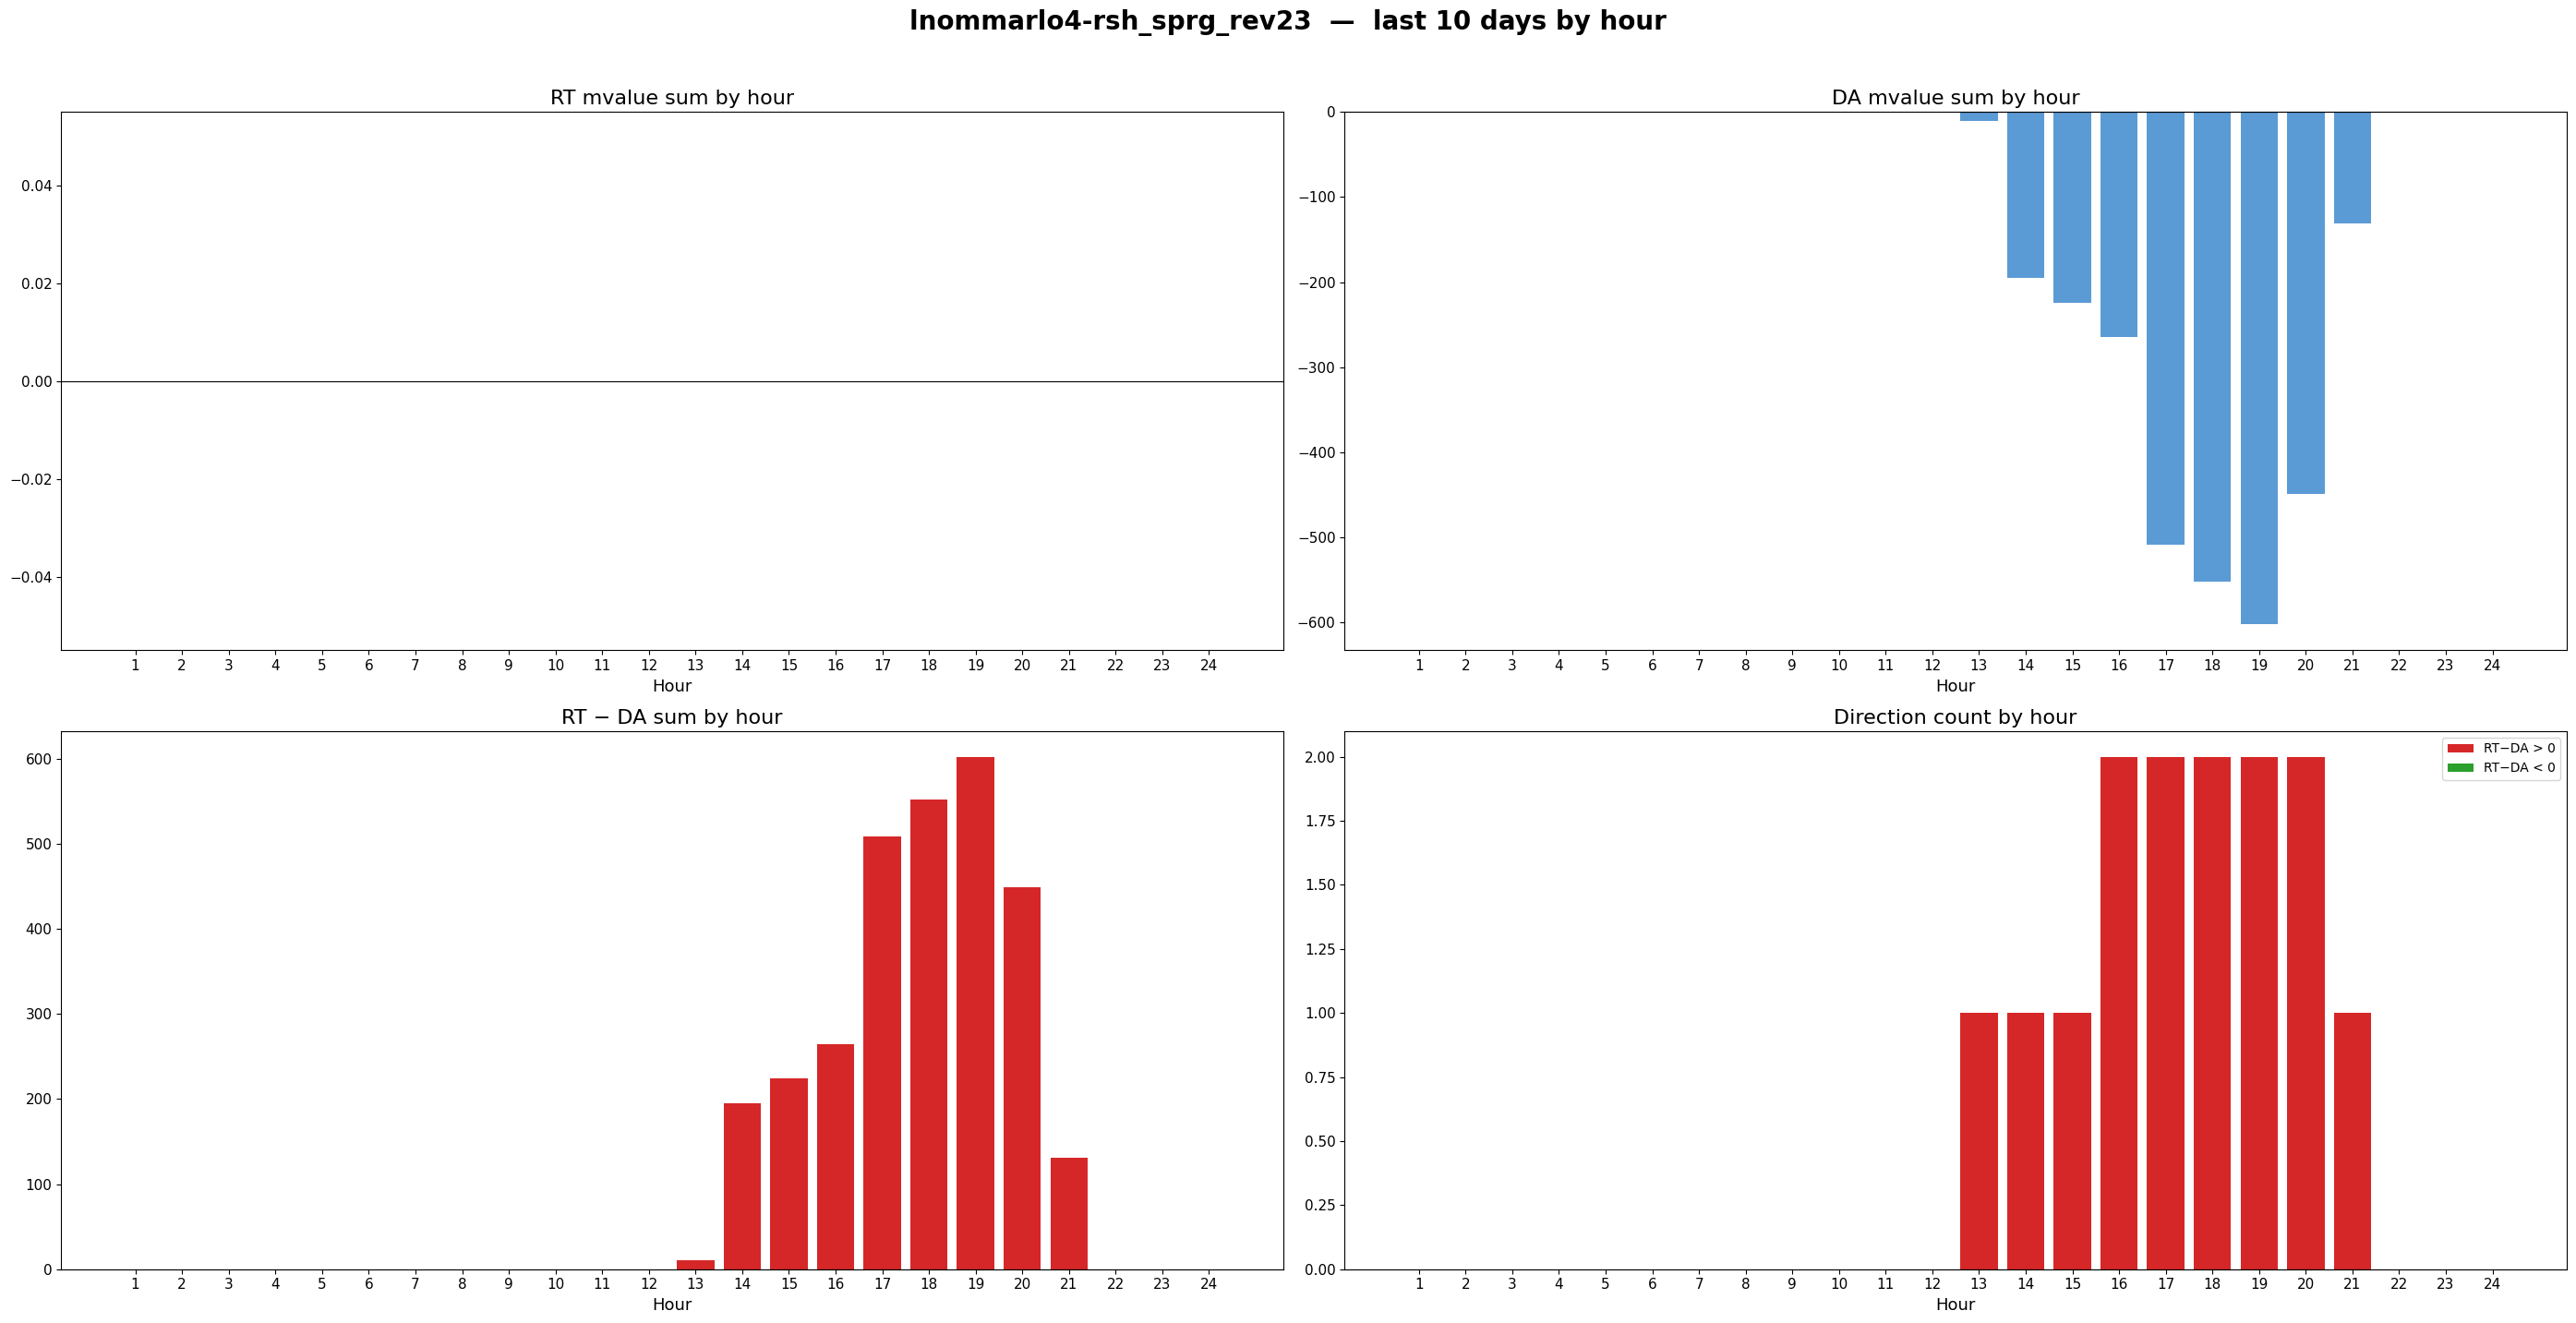

lnommarlo4-rsh_sprg_rev23 could not find the dfax value


Constraint  : 'lnctnwd1-pine'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0025  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnctnwd1-pine,4,rz4_spp_res_zonal_load_forecast_f,0.0025,0.0114,3.65
0,lnctnwd1-pine,4,rz4_spp_res_zonal_wind_forecast_f,0.0025,0.0046,0.86


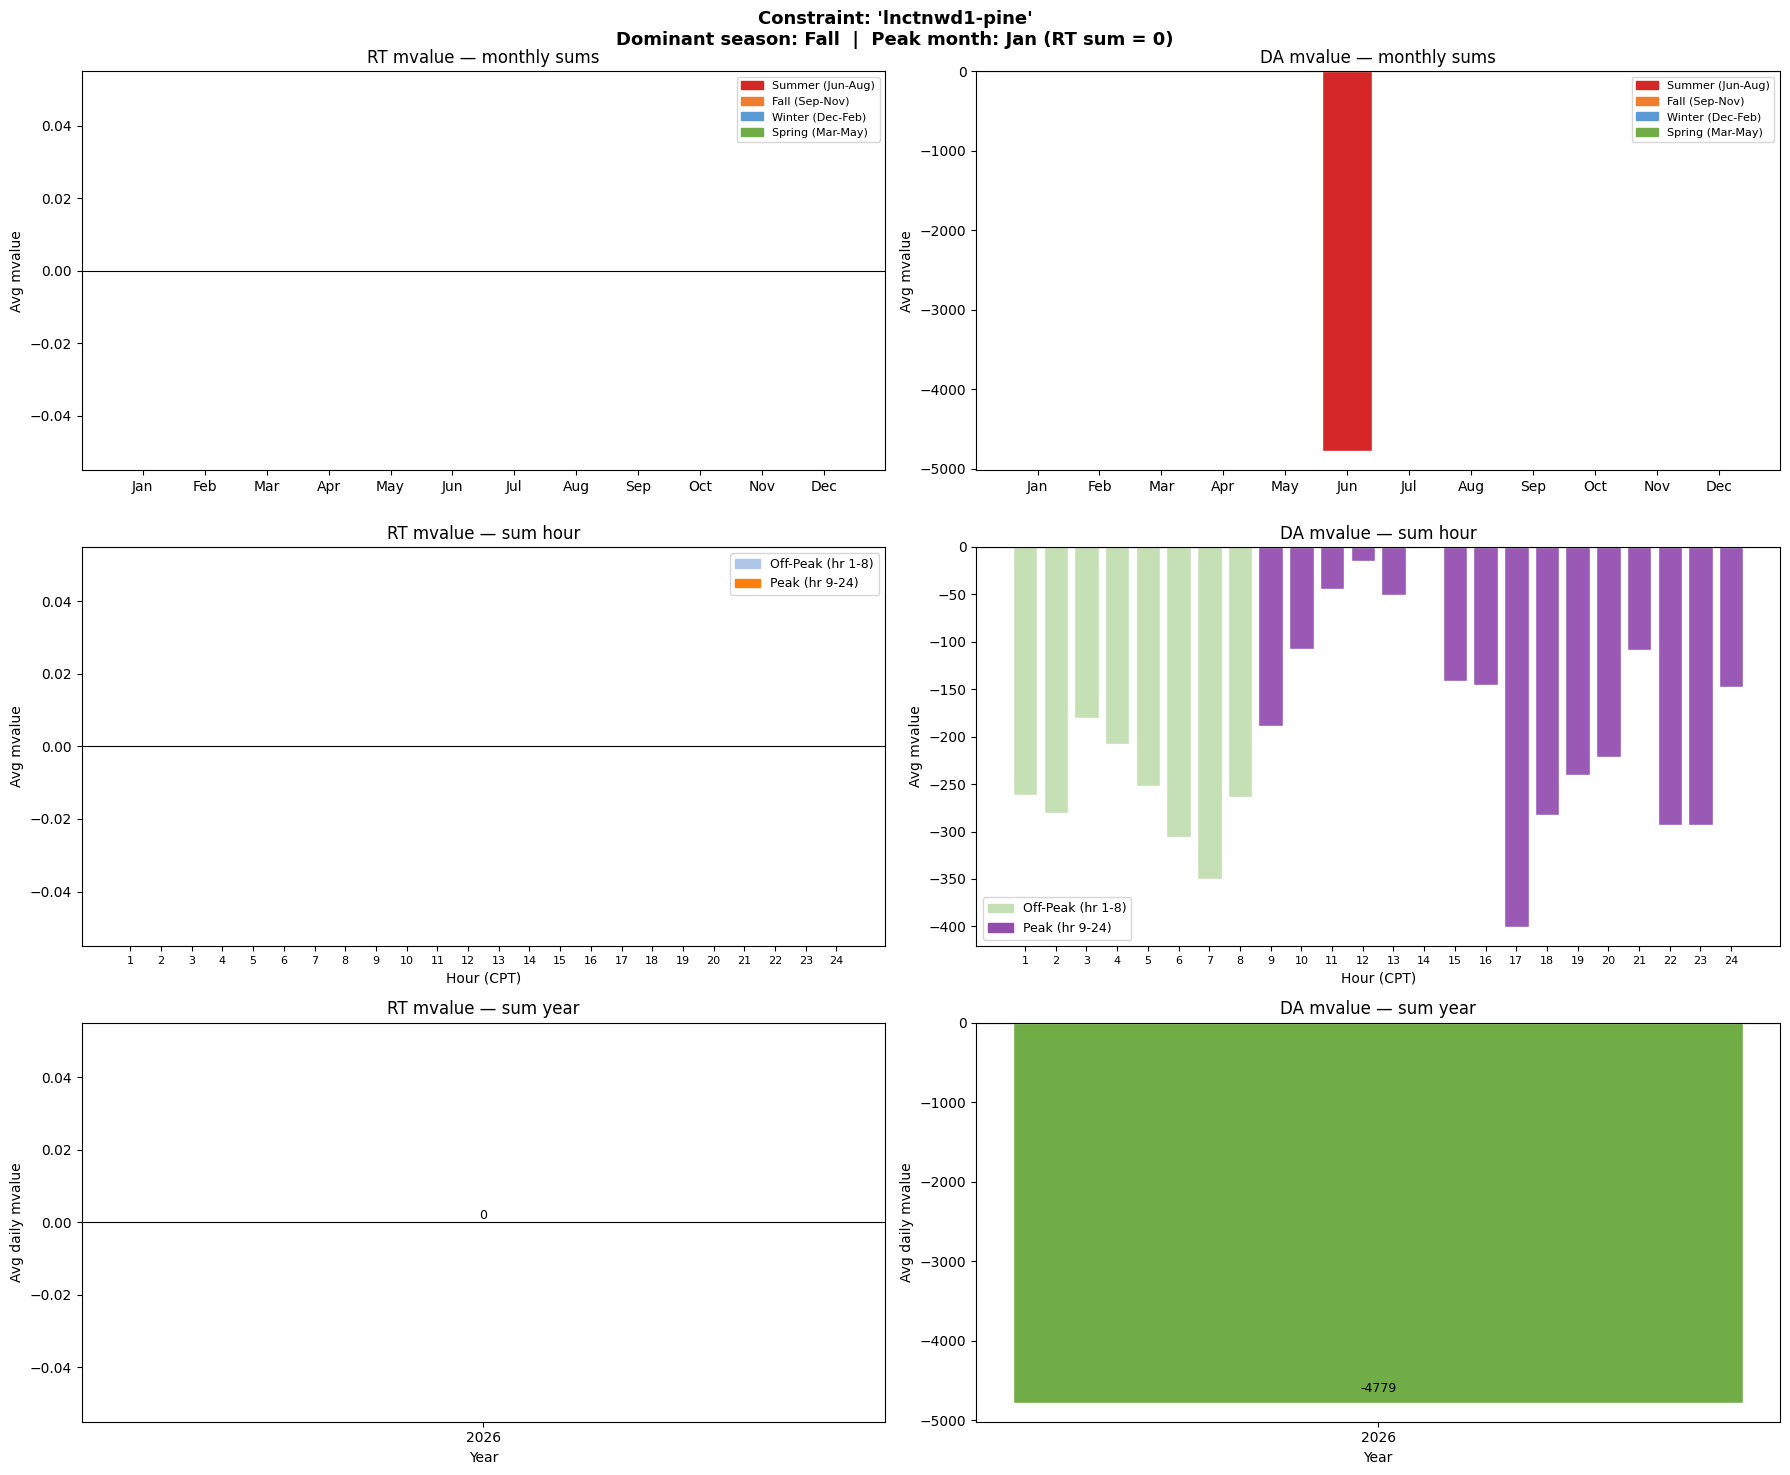

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):   -2678.51  |  off-peak (hr 1-8):   -2100.26
'lnctnwd1-pine'  |  2026-05-30 → 2026-06-09  |  3 days


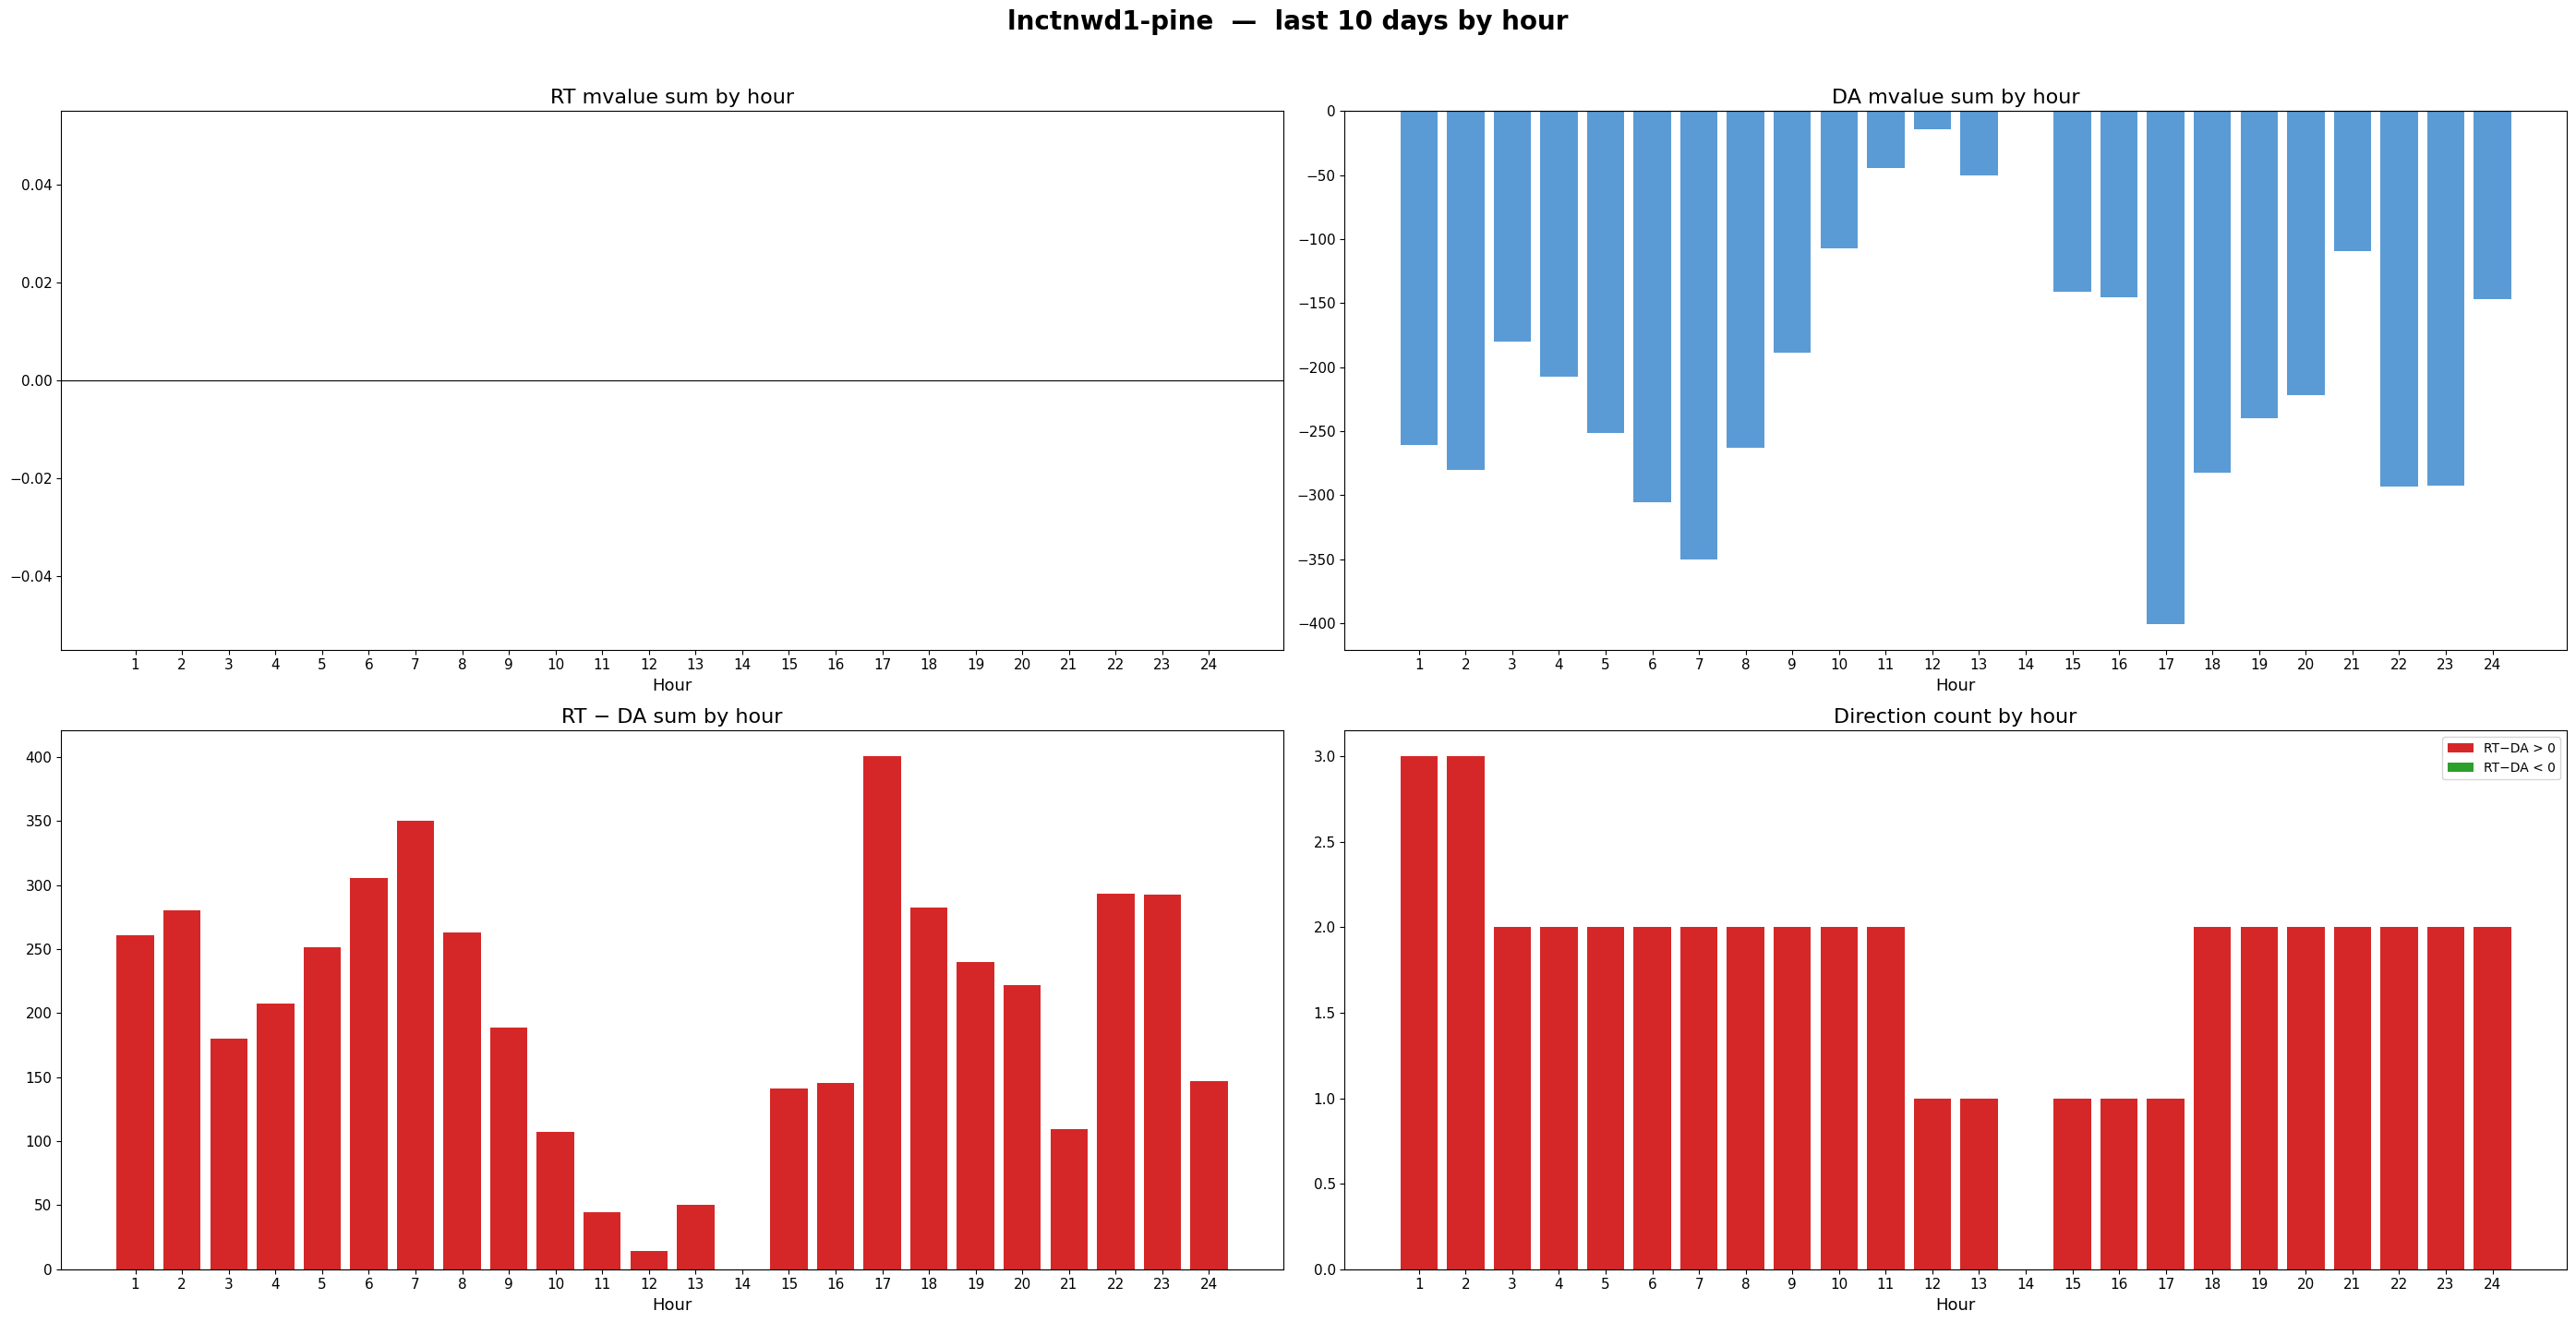

lnctnwd1-pine could not find the dfax value


Constraint  : 'xfmrnowst1-nowst1'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0038  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,xfmrnowst1-nowst1,4,rz4_spp_res_zonal_load_forecast_f,0.0038,0.0217,4.75
0,xfmrnowst1-nowst1,4,rz4_spp_res_zonal_wind_forecast_f,0.0038,0.0080,1.12


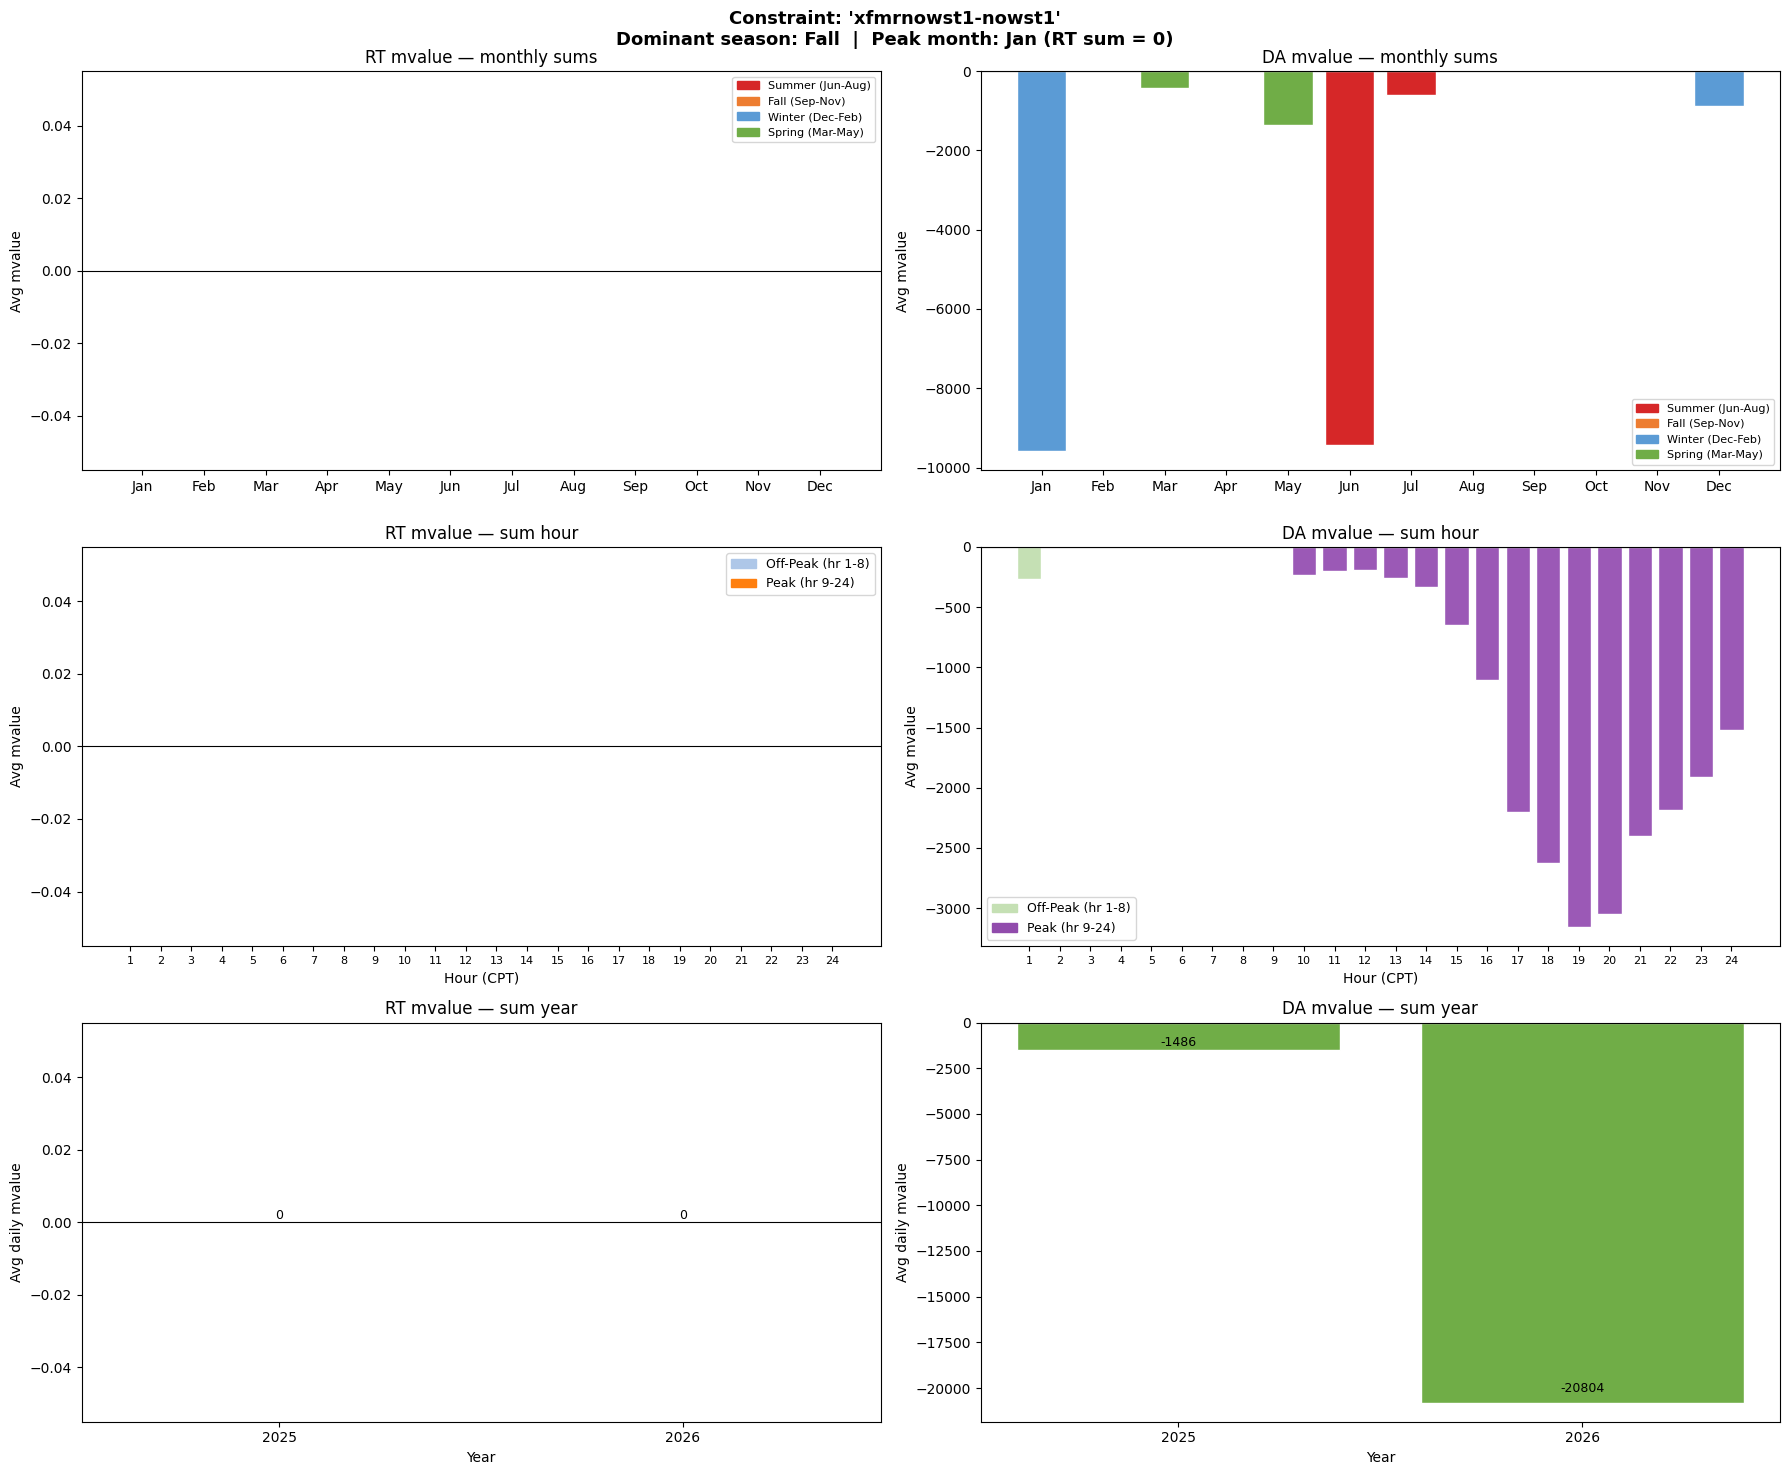

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -22022.57  |  off-peak (hr 1-8):    -267.40
'xfmrnowst1-nowst1'  |  2026-05-30 → 2026-06-09  |  7 days


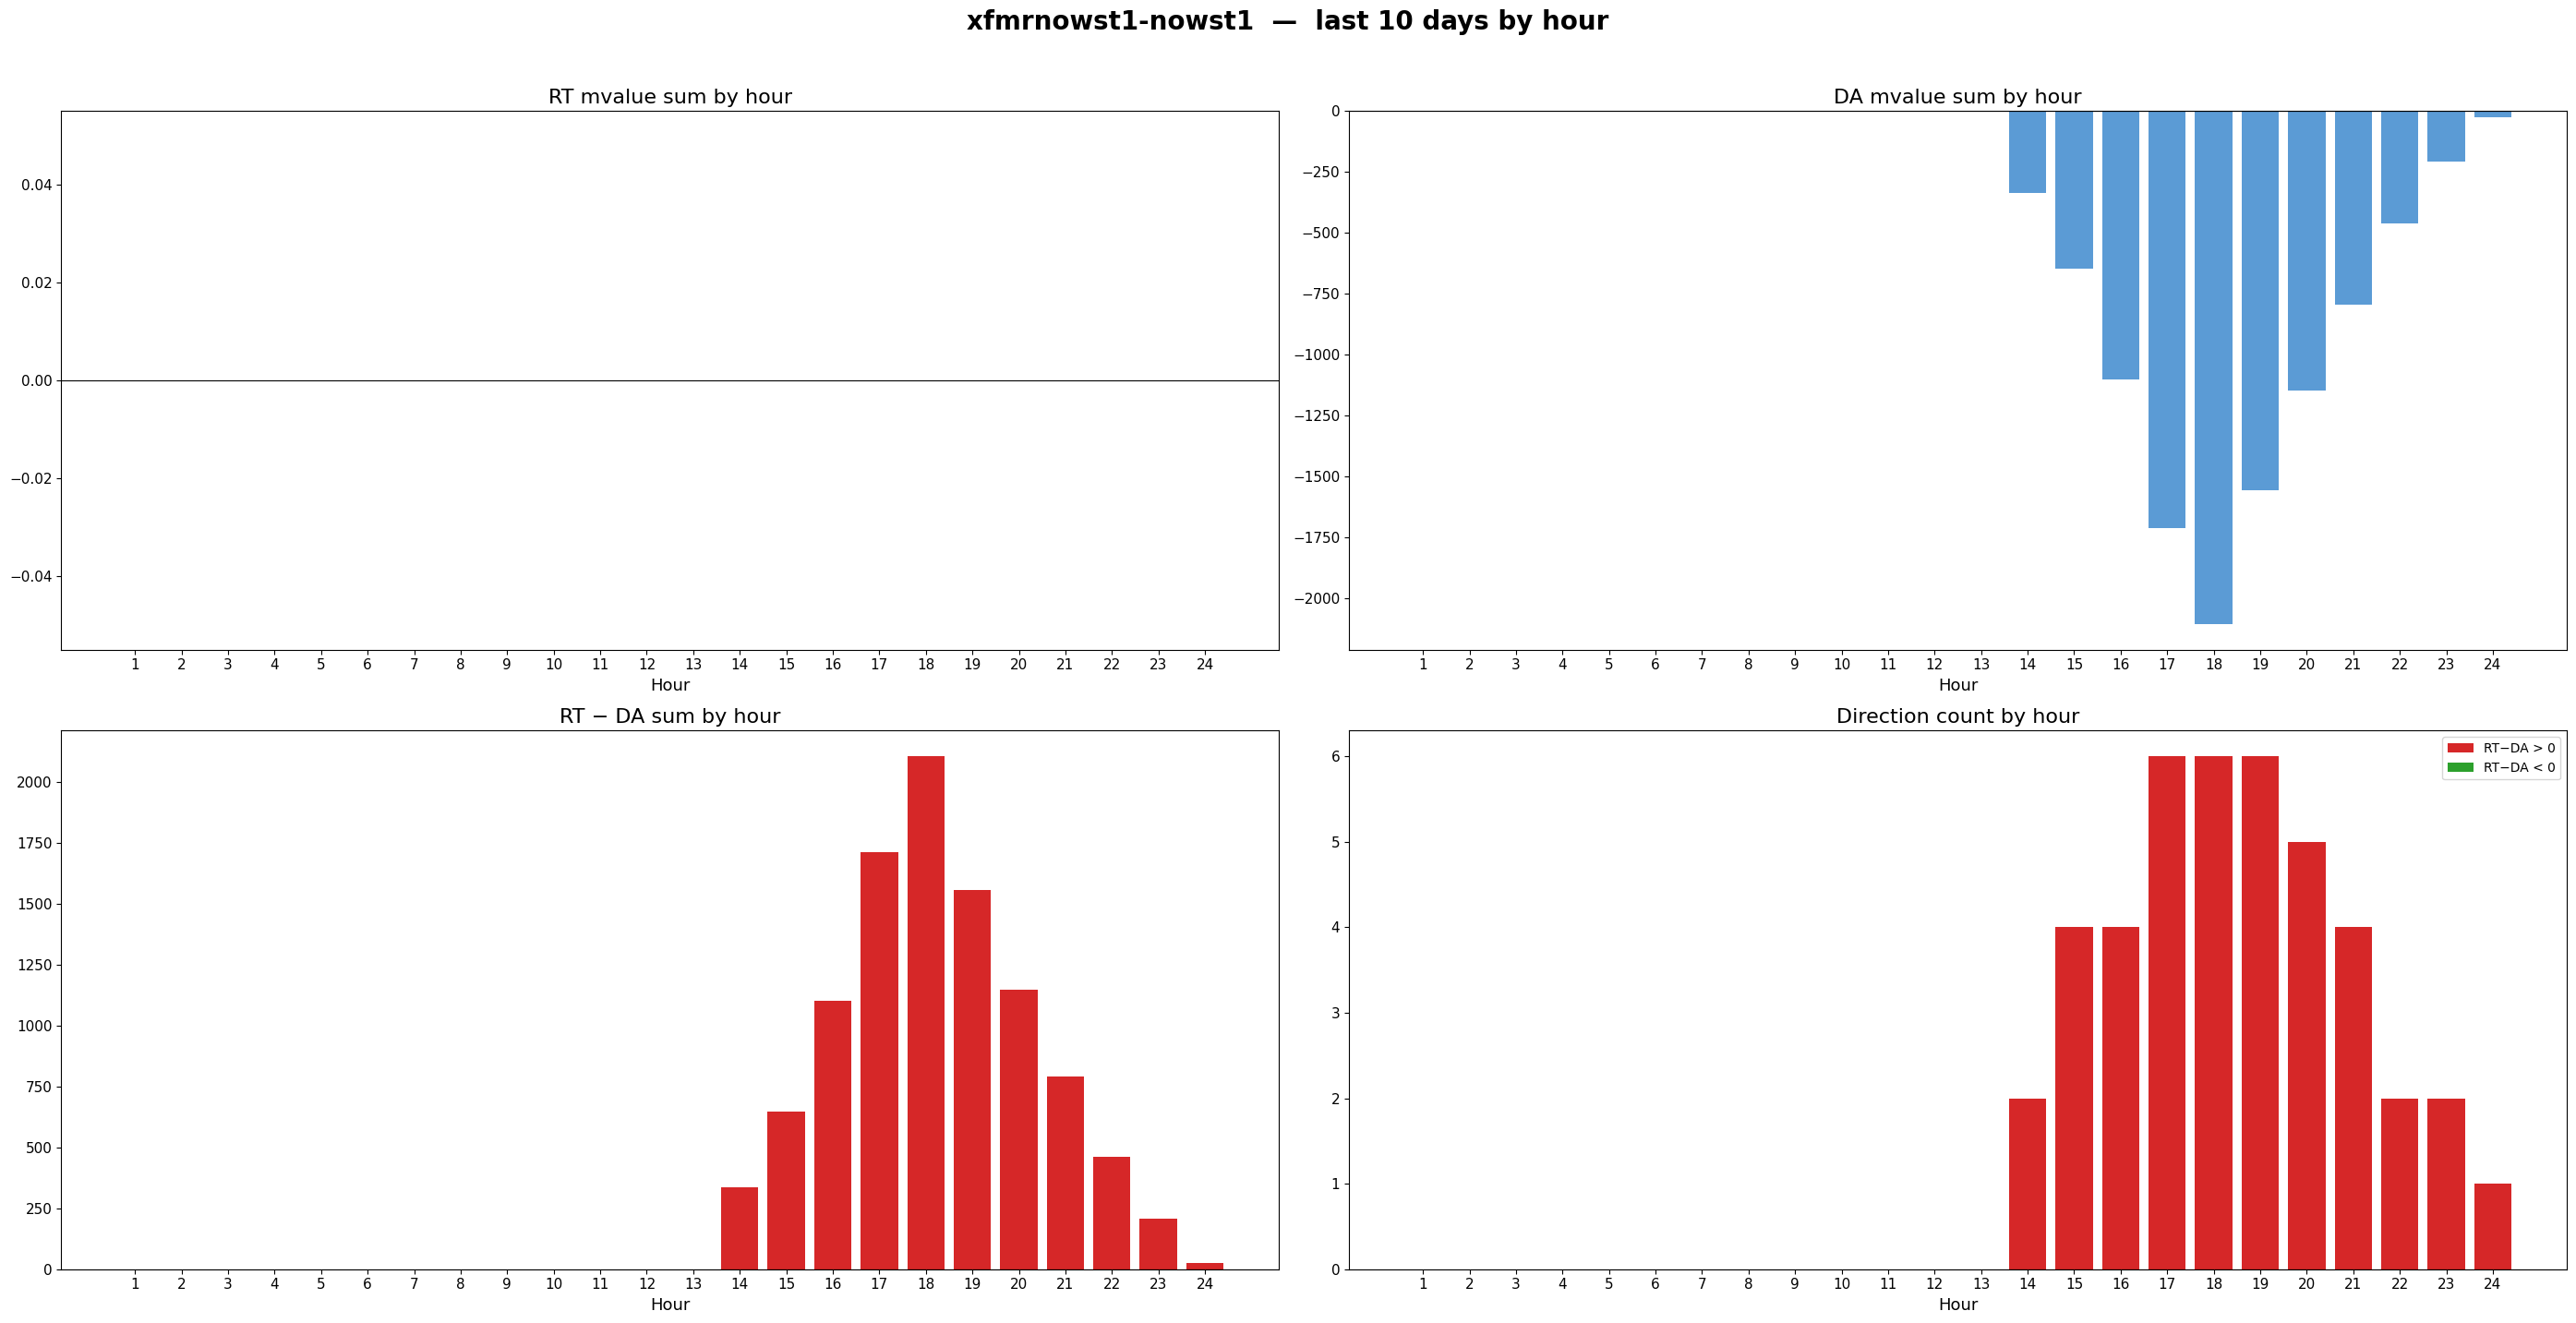

xfmrnowst1-nowst1 could not find the dfax value


Constraint  : 'lnlenexa-shwnmsn5'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0053  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnlenexa-shwnmsn5,4,rz4_spp_res_zonal_load_forecast_f,0.0053,0.0103,0.96
0,lnlenexa-shwnmsn5,4,rz4_spp_res_zonal_wind_forecast_f,0.0053,0.0046,-0.13


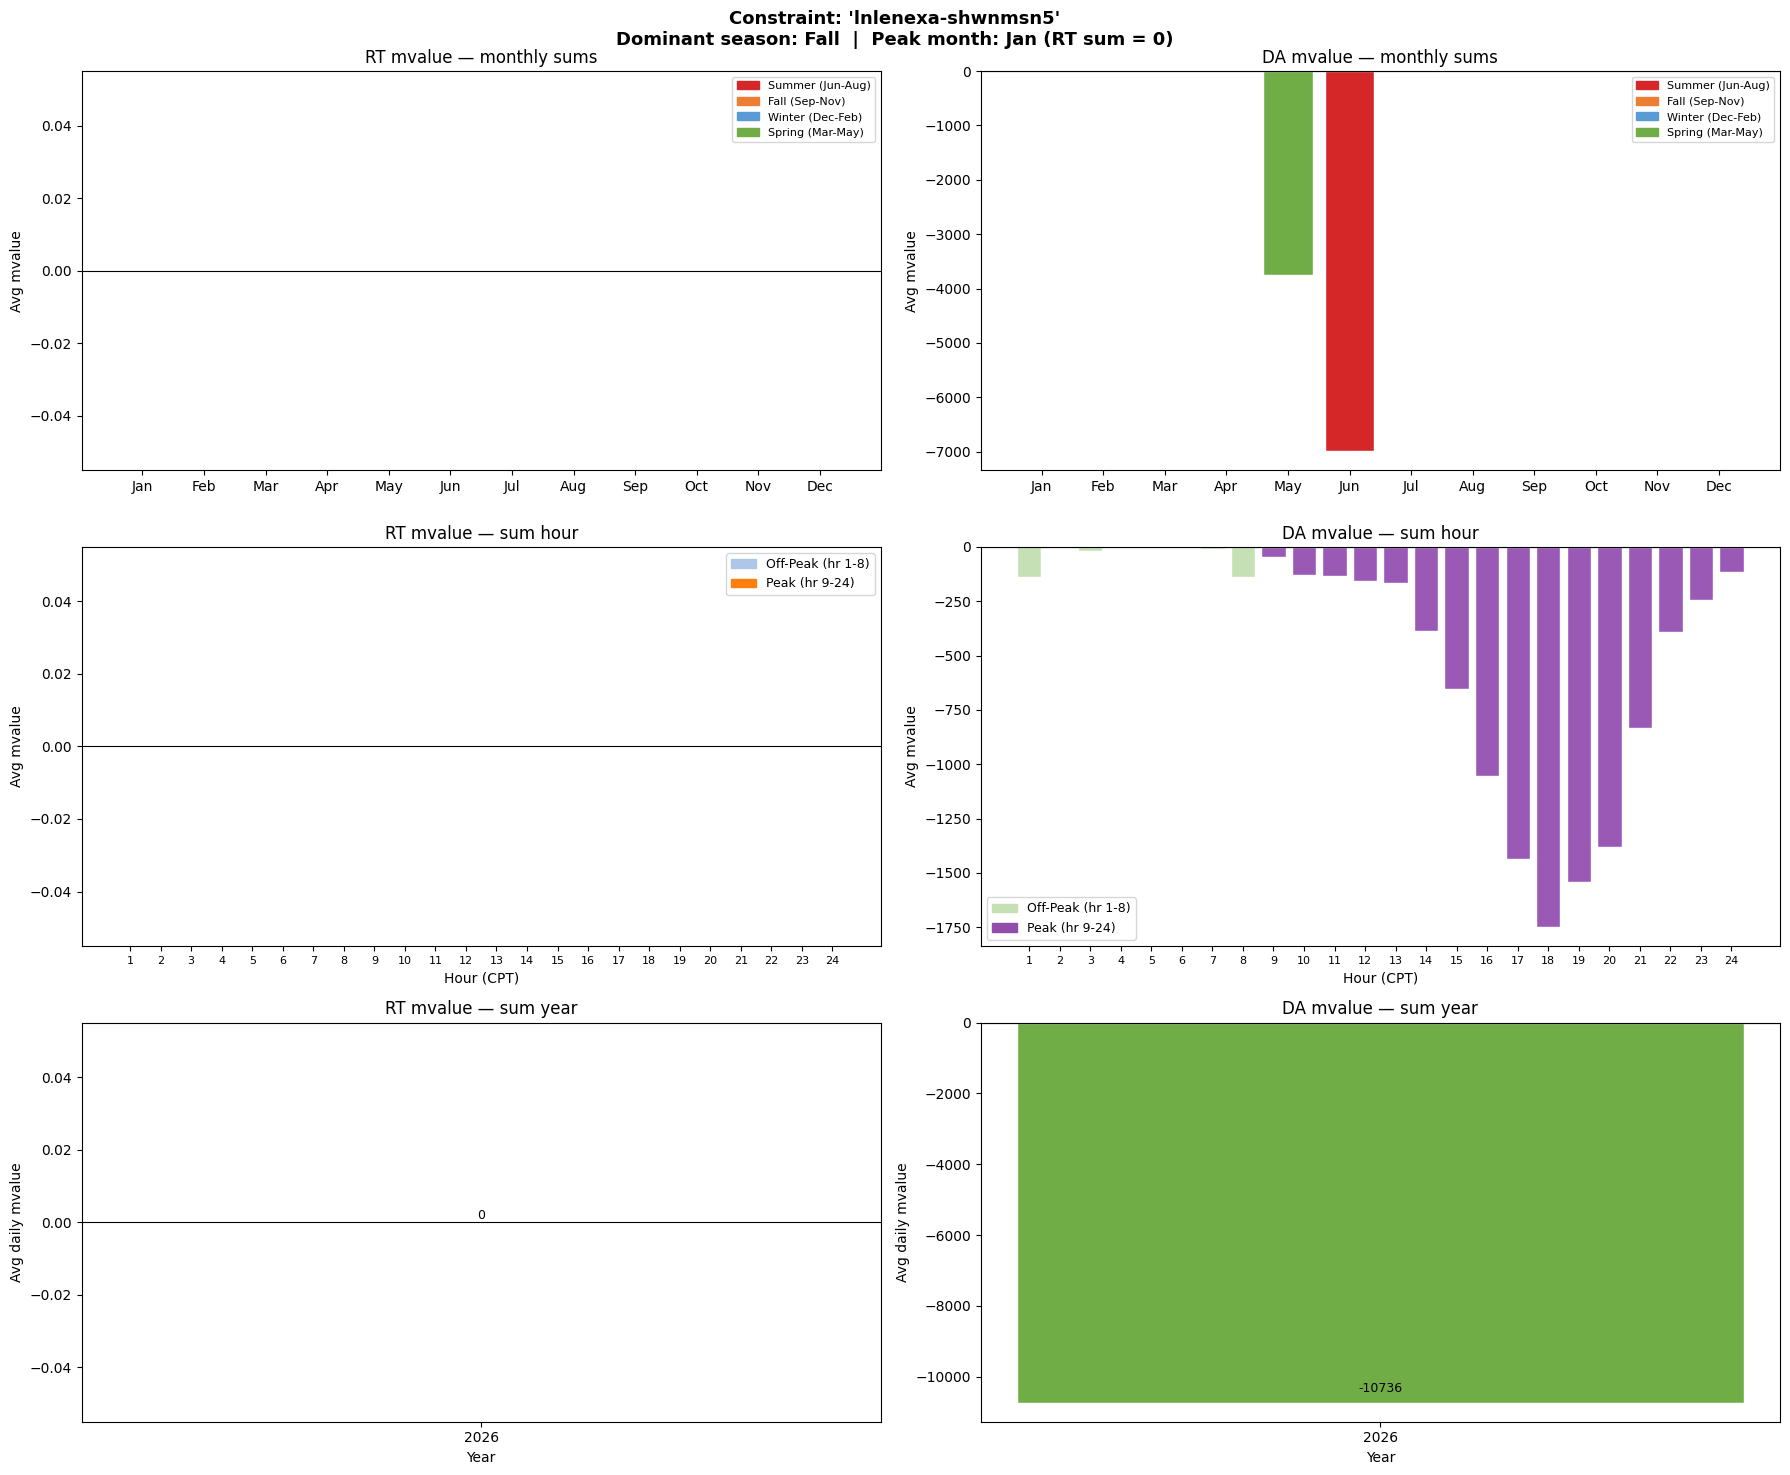

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -10423.74  |  off-peak (hr 1-8):    -311.91
'lnlenexa-shwnmsn5'  |  2026-05-30 → 2026-06-09  |  6 days


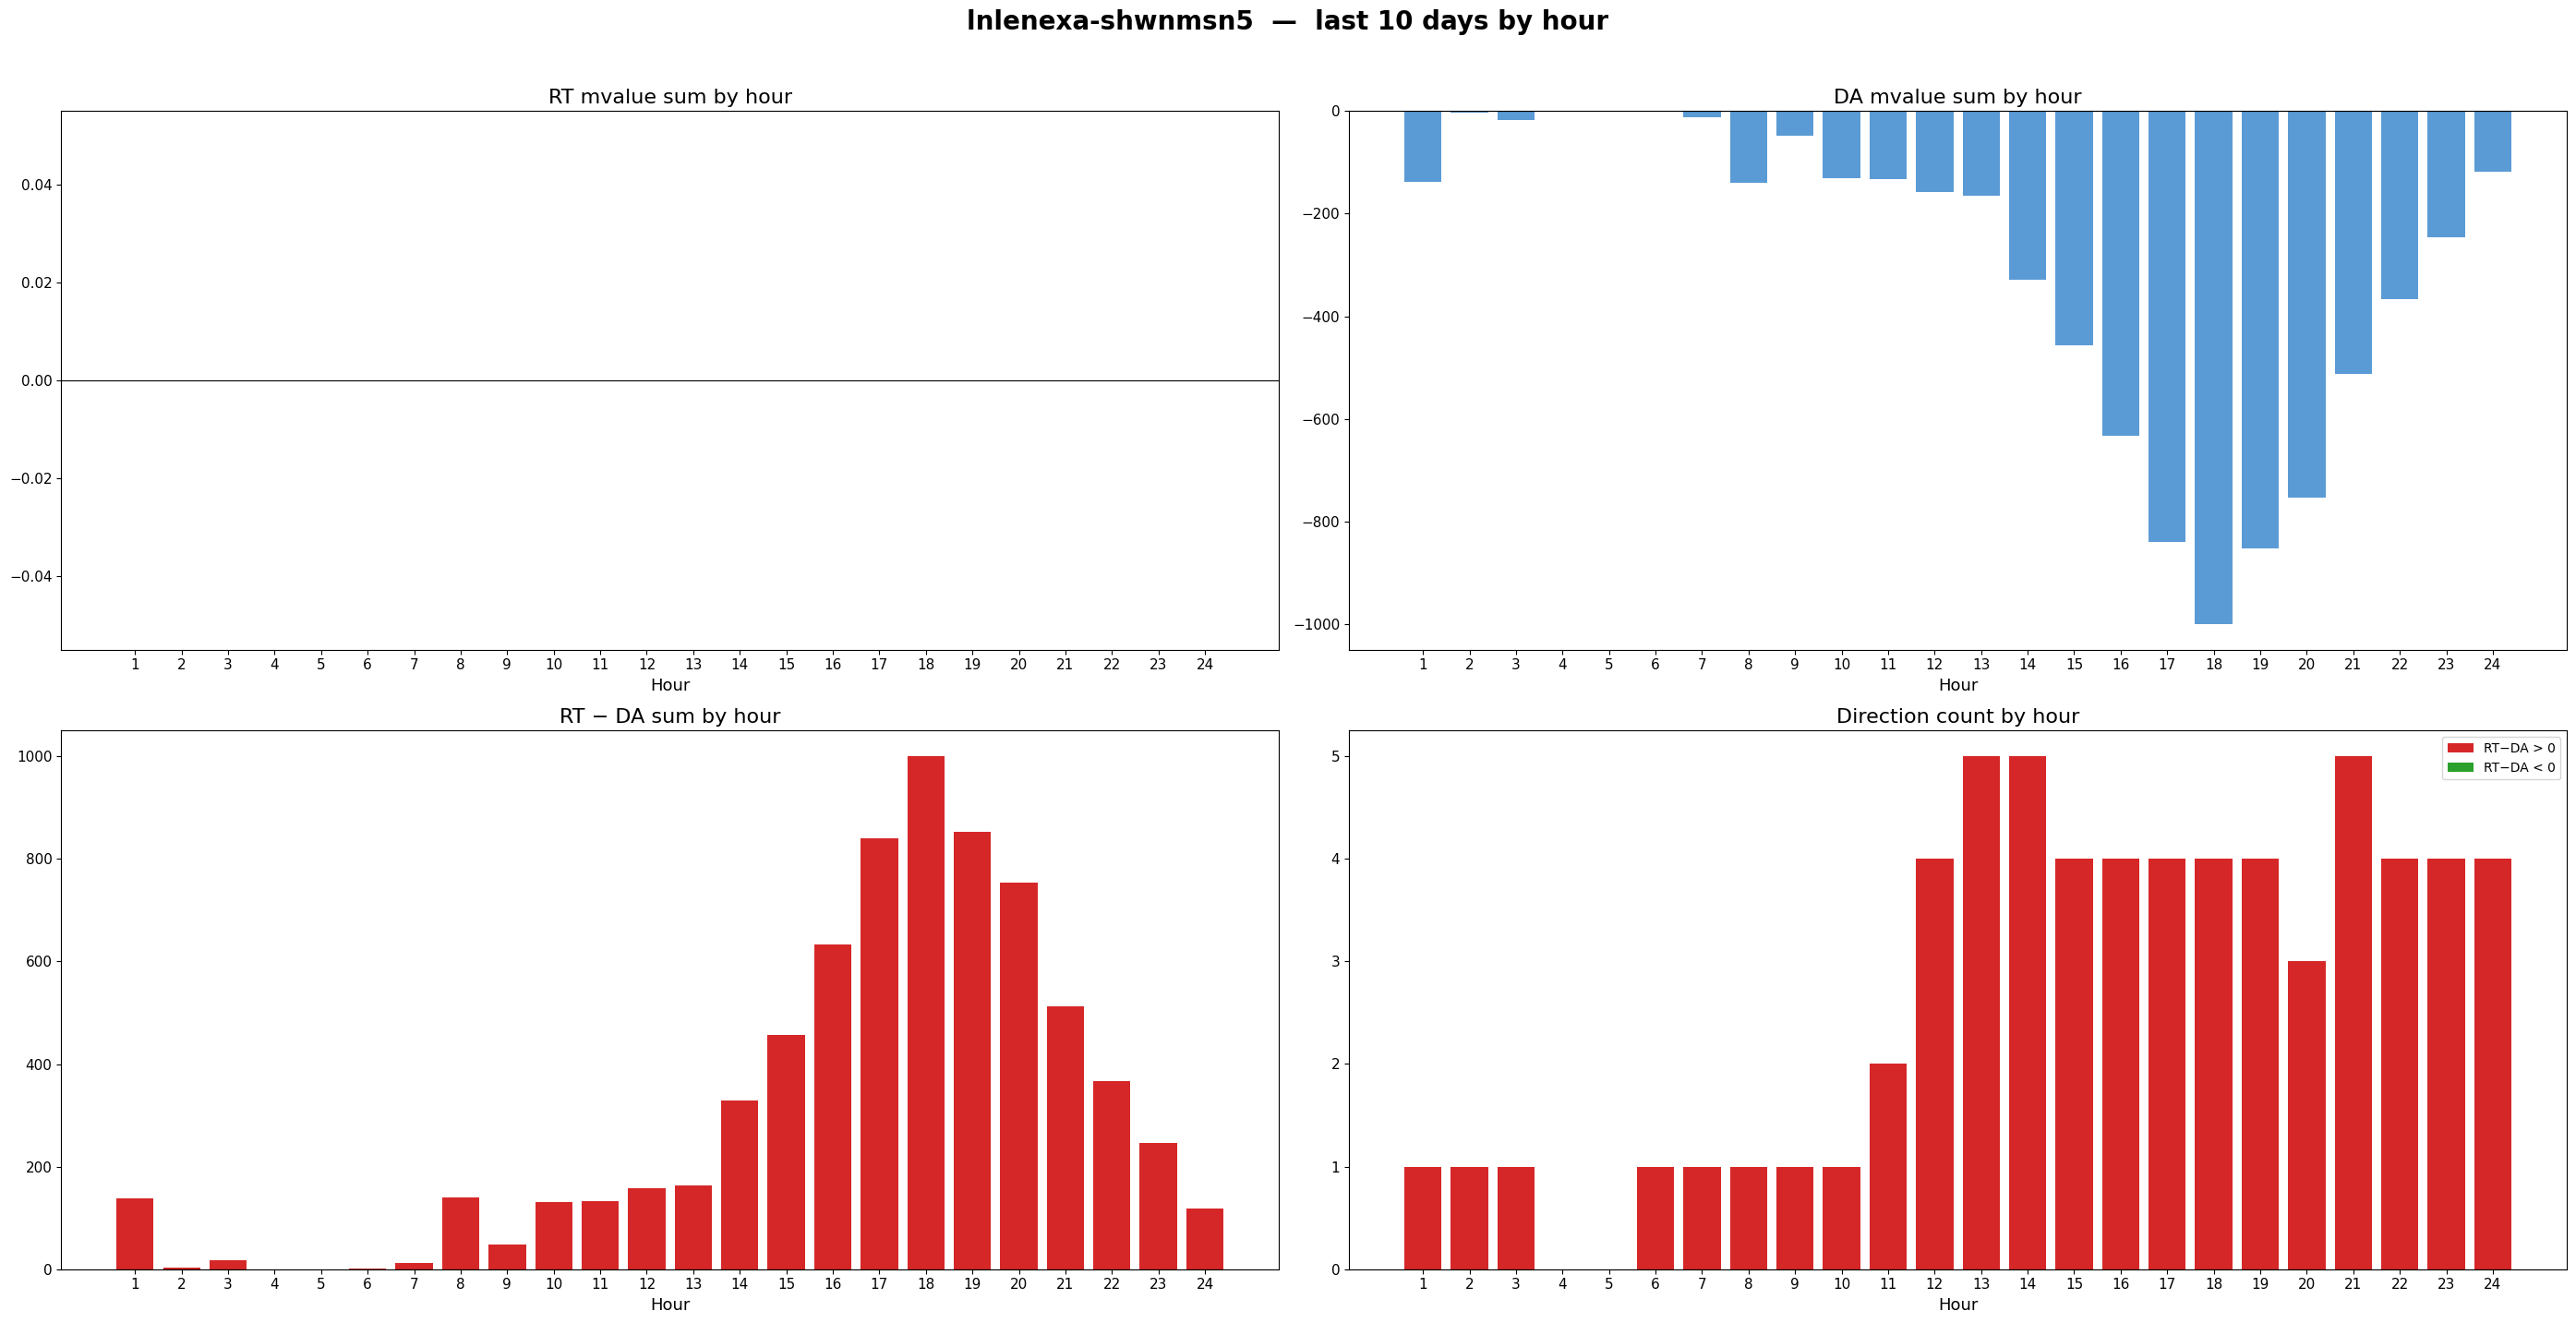

lnlenexa-shwnmsn5 could not find the dfax value


Constraint  : 'lnmaud_tap-earlsbrh'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0060  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnmaud_tap-earlsbrh,4,rz4_spp_res_zonal_wind_forecast_f,0.006,0.0286,3.81
1,lnmaud_tap-earlsbrh,4,rz4_spp_res_zonal_load_forecast_f,0.006,0.0034,-0.42


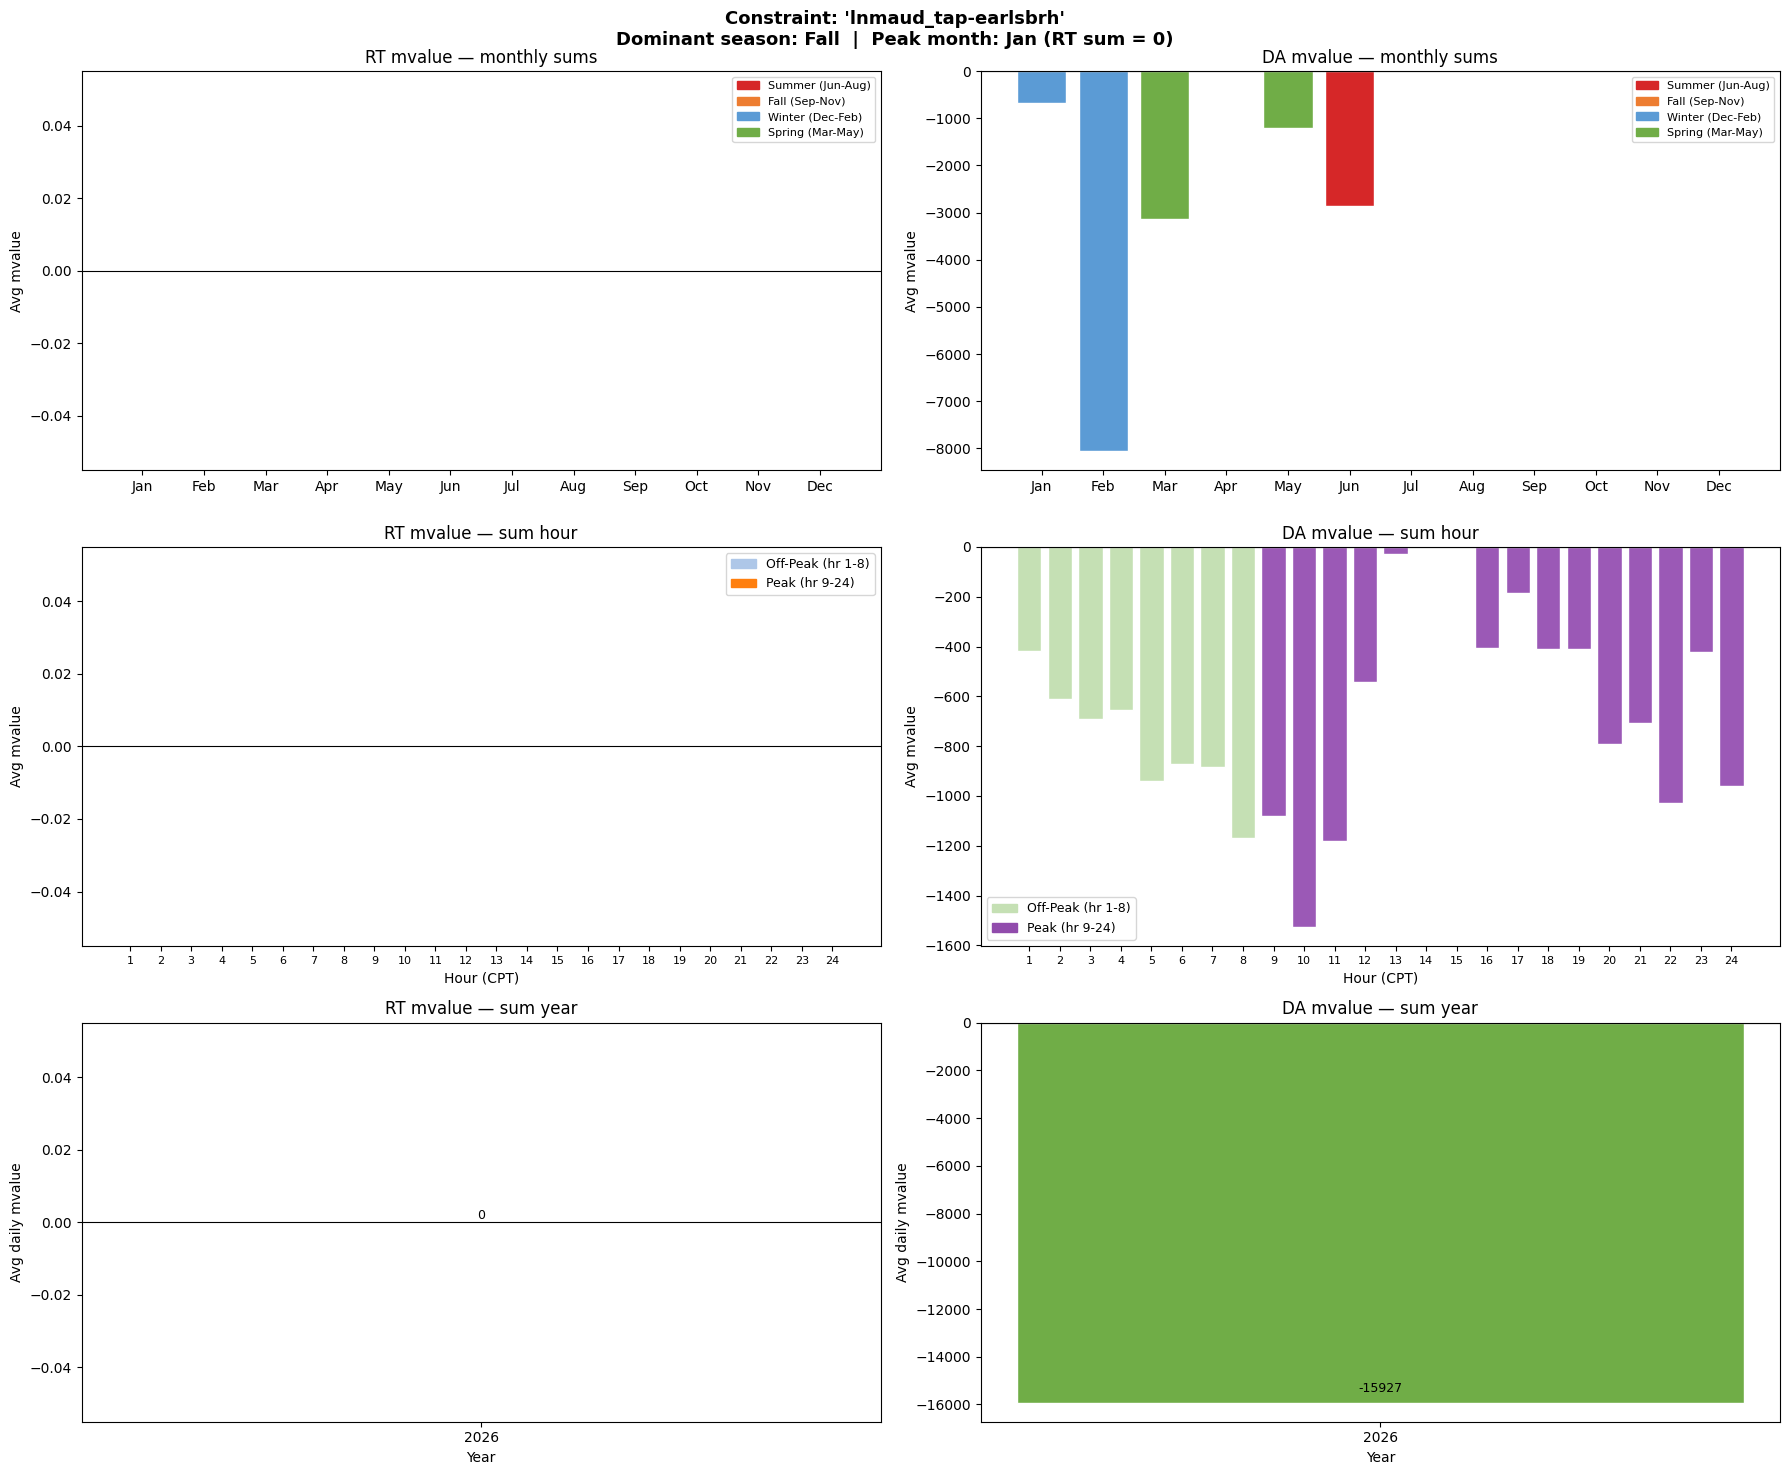

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):   -9677.61  |  off-peak (hr 1-8):   -6248.89
'lnmaud_tap-earlsbrh'  |  2026-05-30 → 2026-06-09  |  4 days


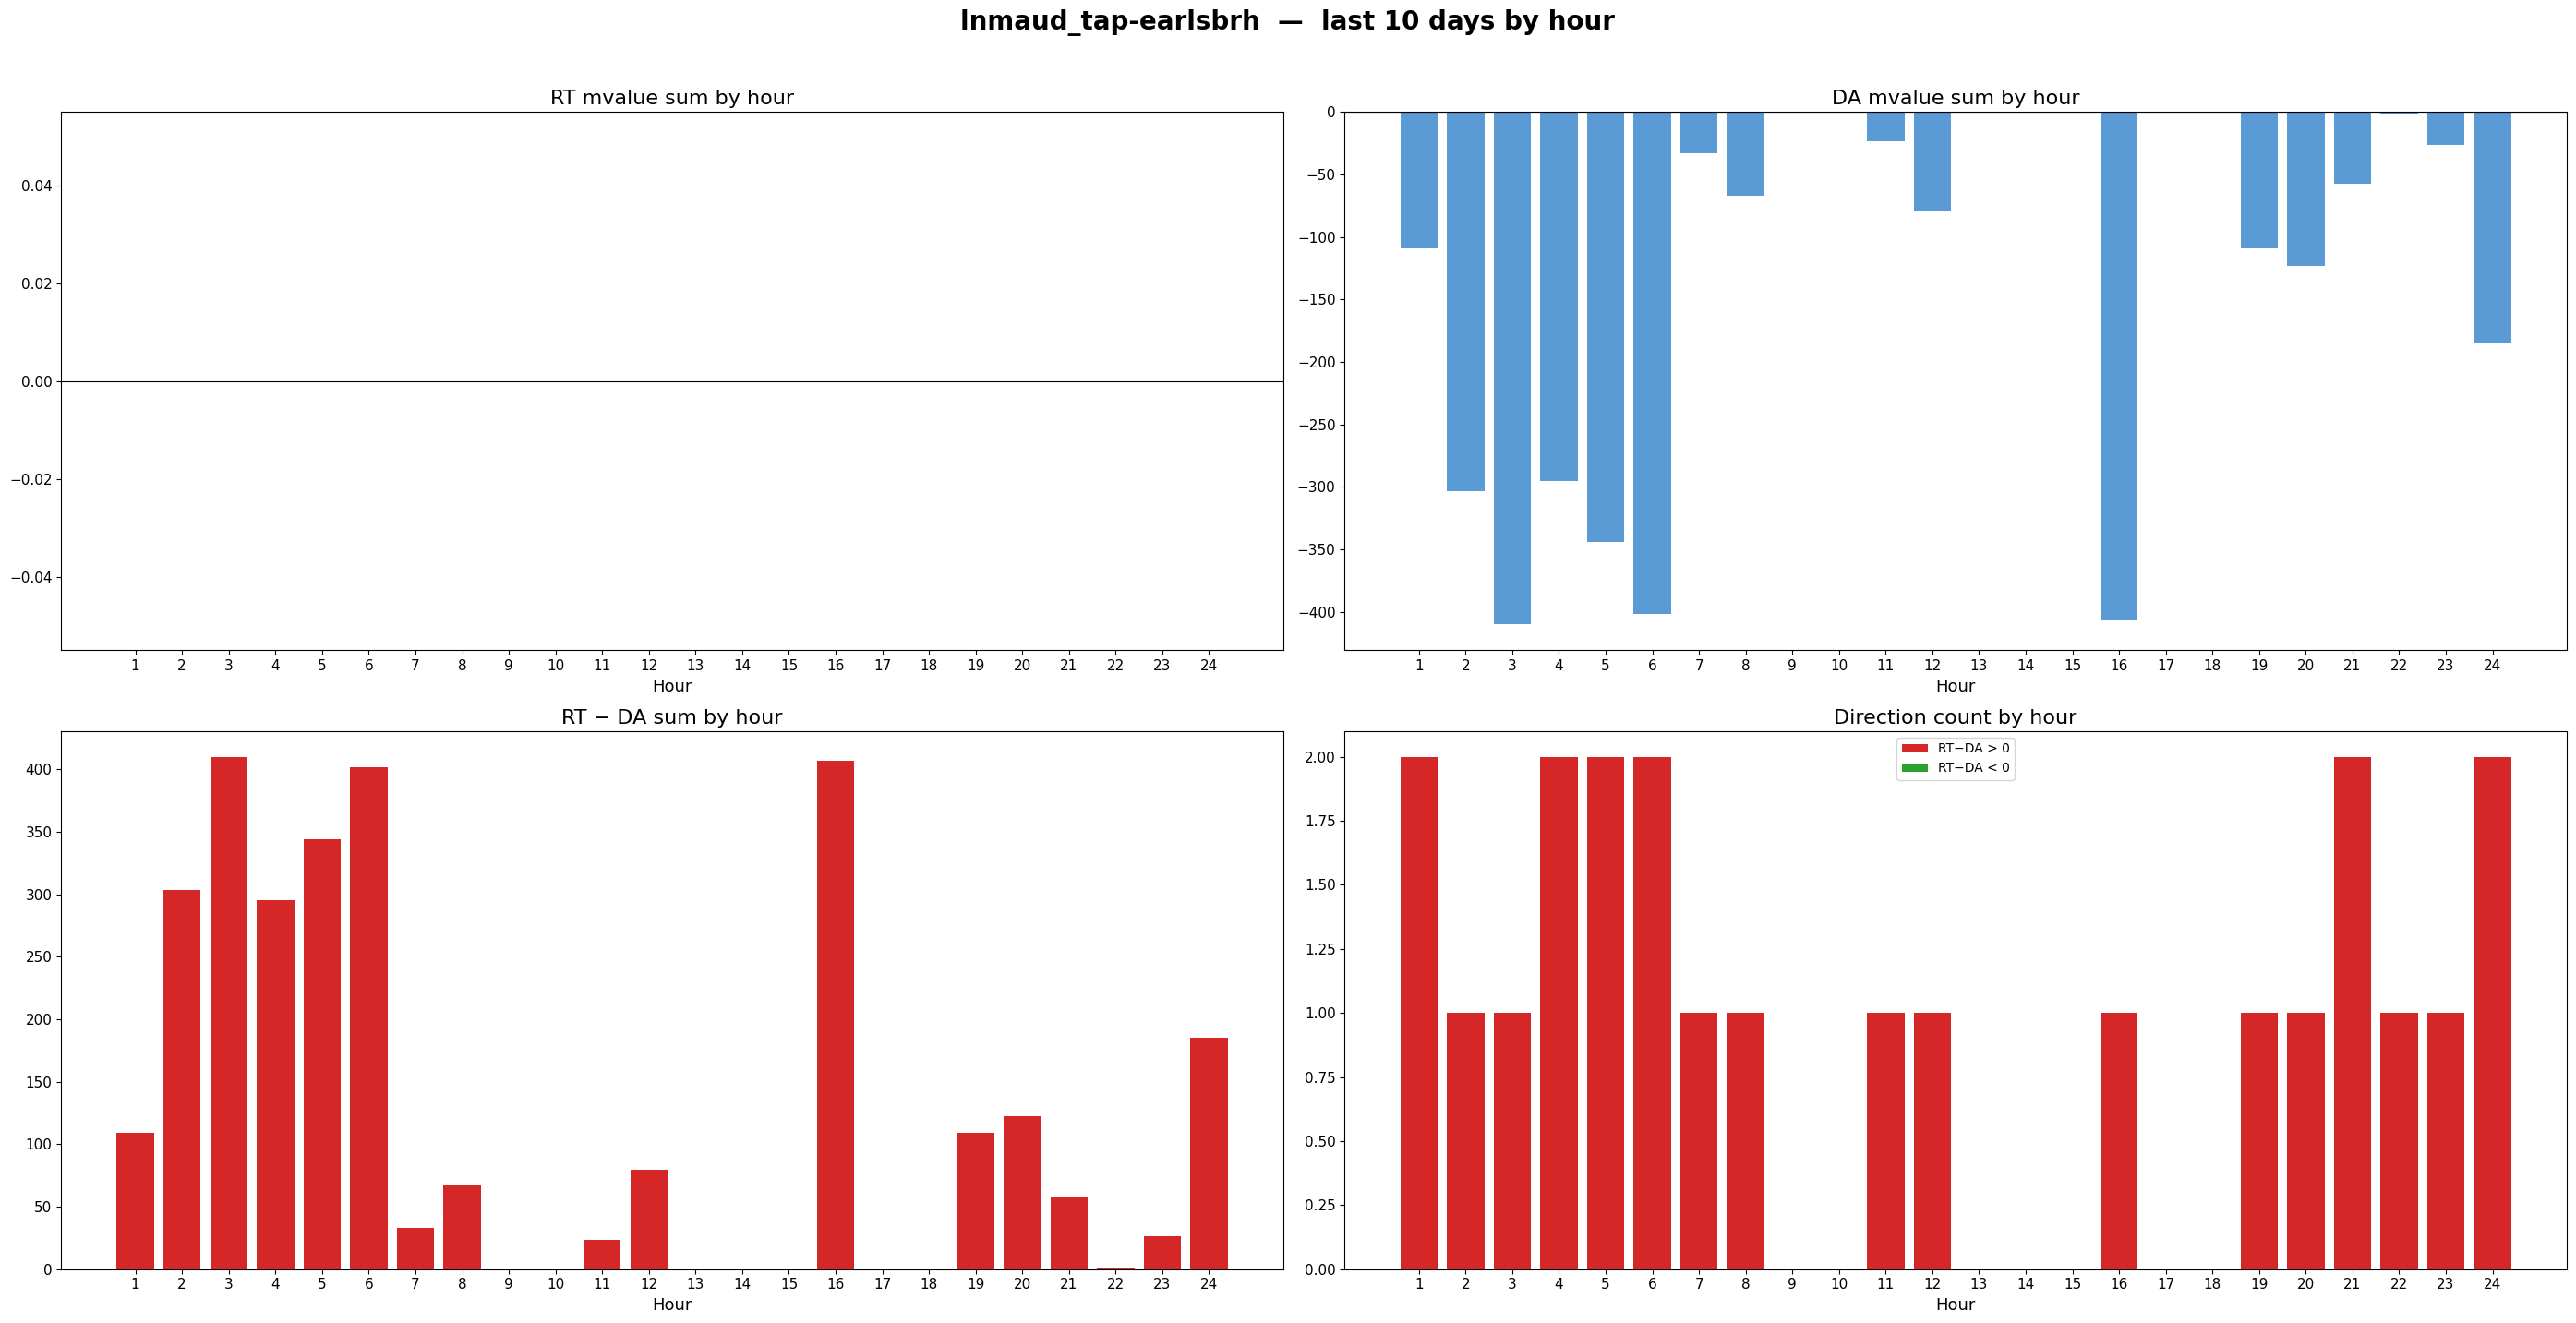

lnmaud_tap-earlsbrh could not find the dfax value


Constraint  : 'lnwashit1-sw_sta'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0068  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnwashit1-sw_sta,4,rz4_spp_res_zonal_load_forecast_f,0.0068,0.0149,1.20
0,lnwashit1-sw_sta,4,rz4_spp_res_zonal_wind_forecast_f,0.0068,0.0046,-0.32


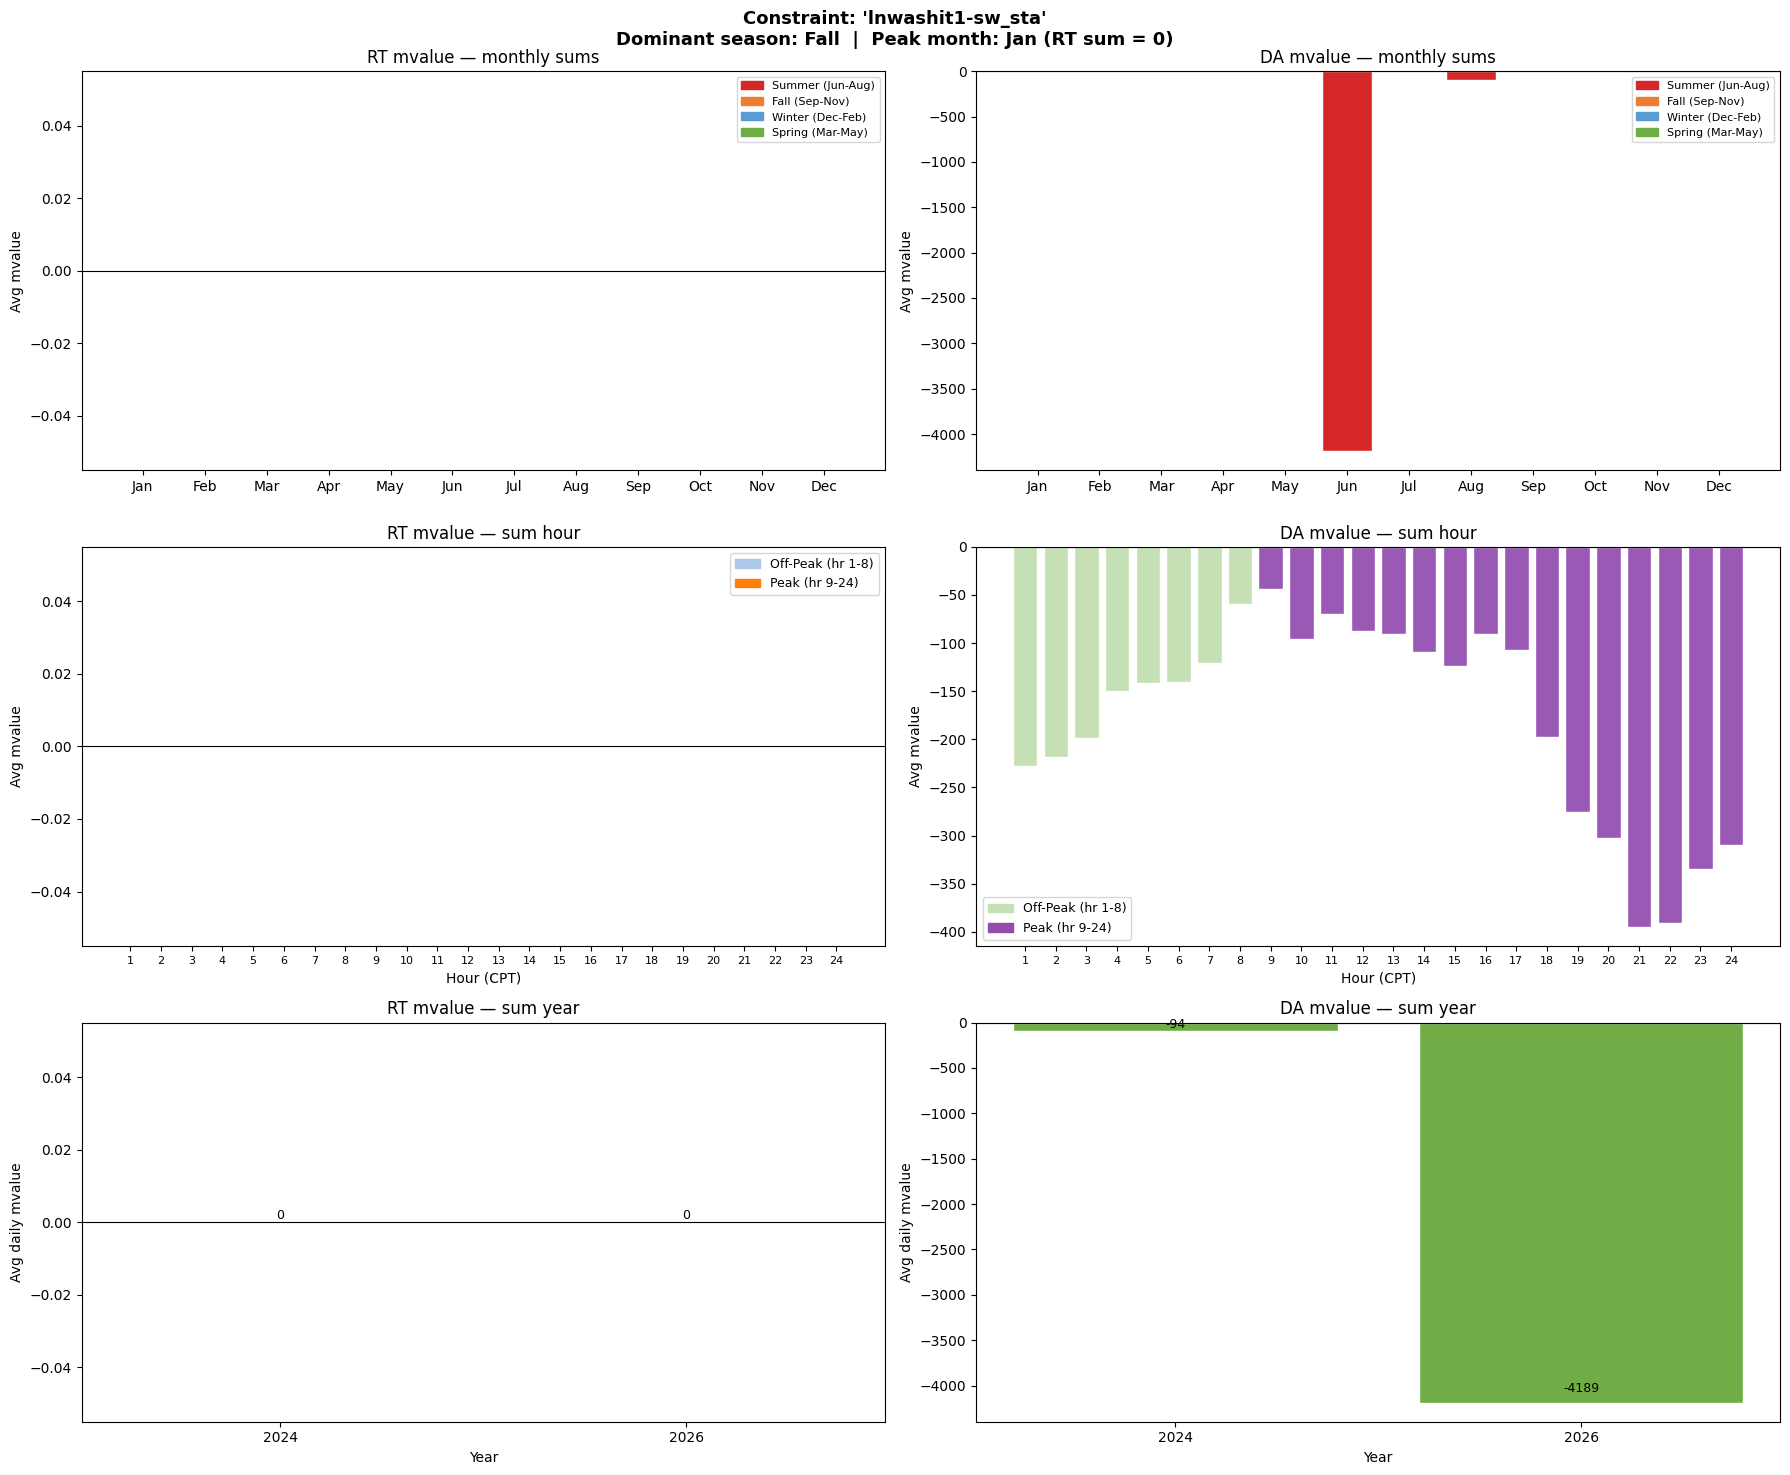

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):   -3025.56  |  off-peak (hr 1-8):   -1257.26
'lnwashit1-sw_sta'  |  2026-05-30 → 2026-06-09  |  9 days


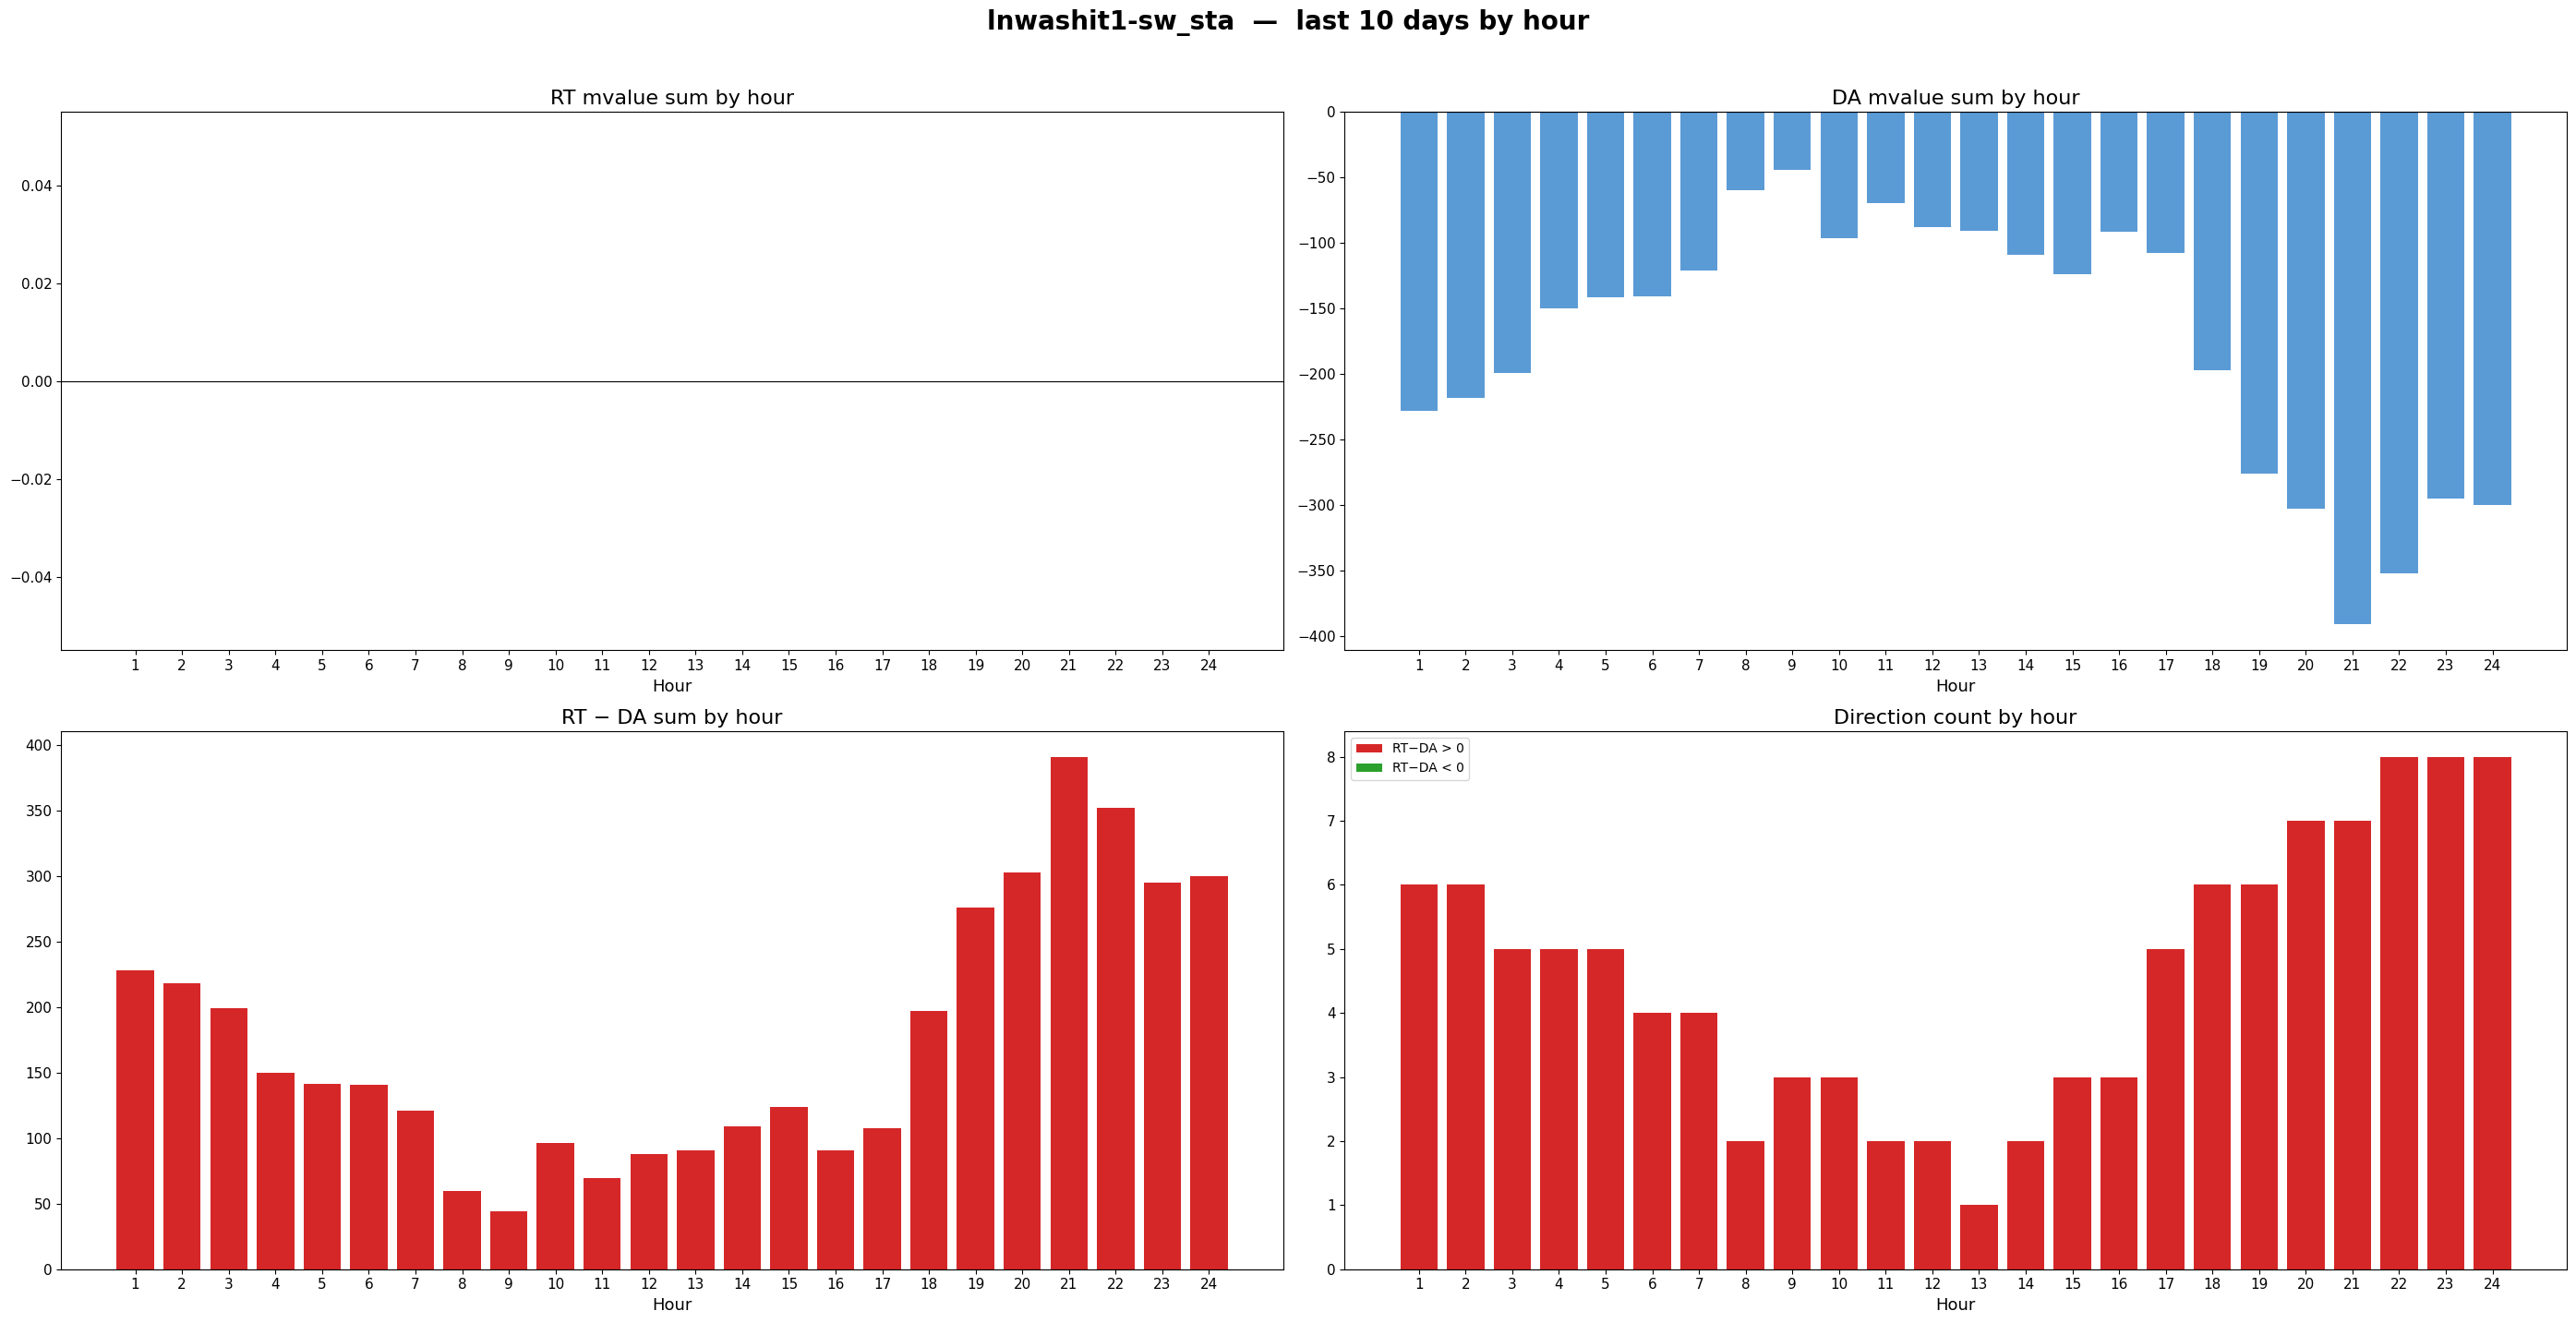

lnwashit1-sw_sta could not find the dfax value


Constraint  : 'xfmrlex1611-lex1611'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0171  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,xfmrlex1611-lex1611,4,rz4_spp_res_zonal_wind_forecast_f,0.0171,0.0412,1.41
1,xfmrlex1611-lex1611,4,rz4_spp_res_zonal_load_forecast_f,0.0171,0.0034,-0.80


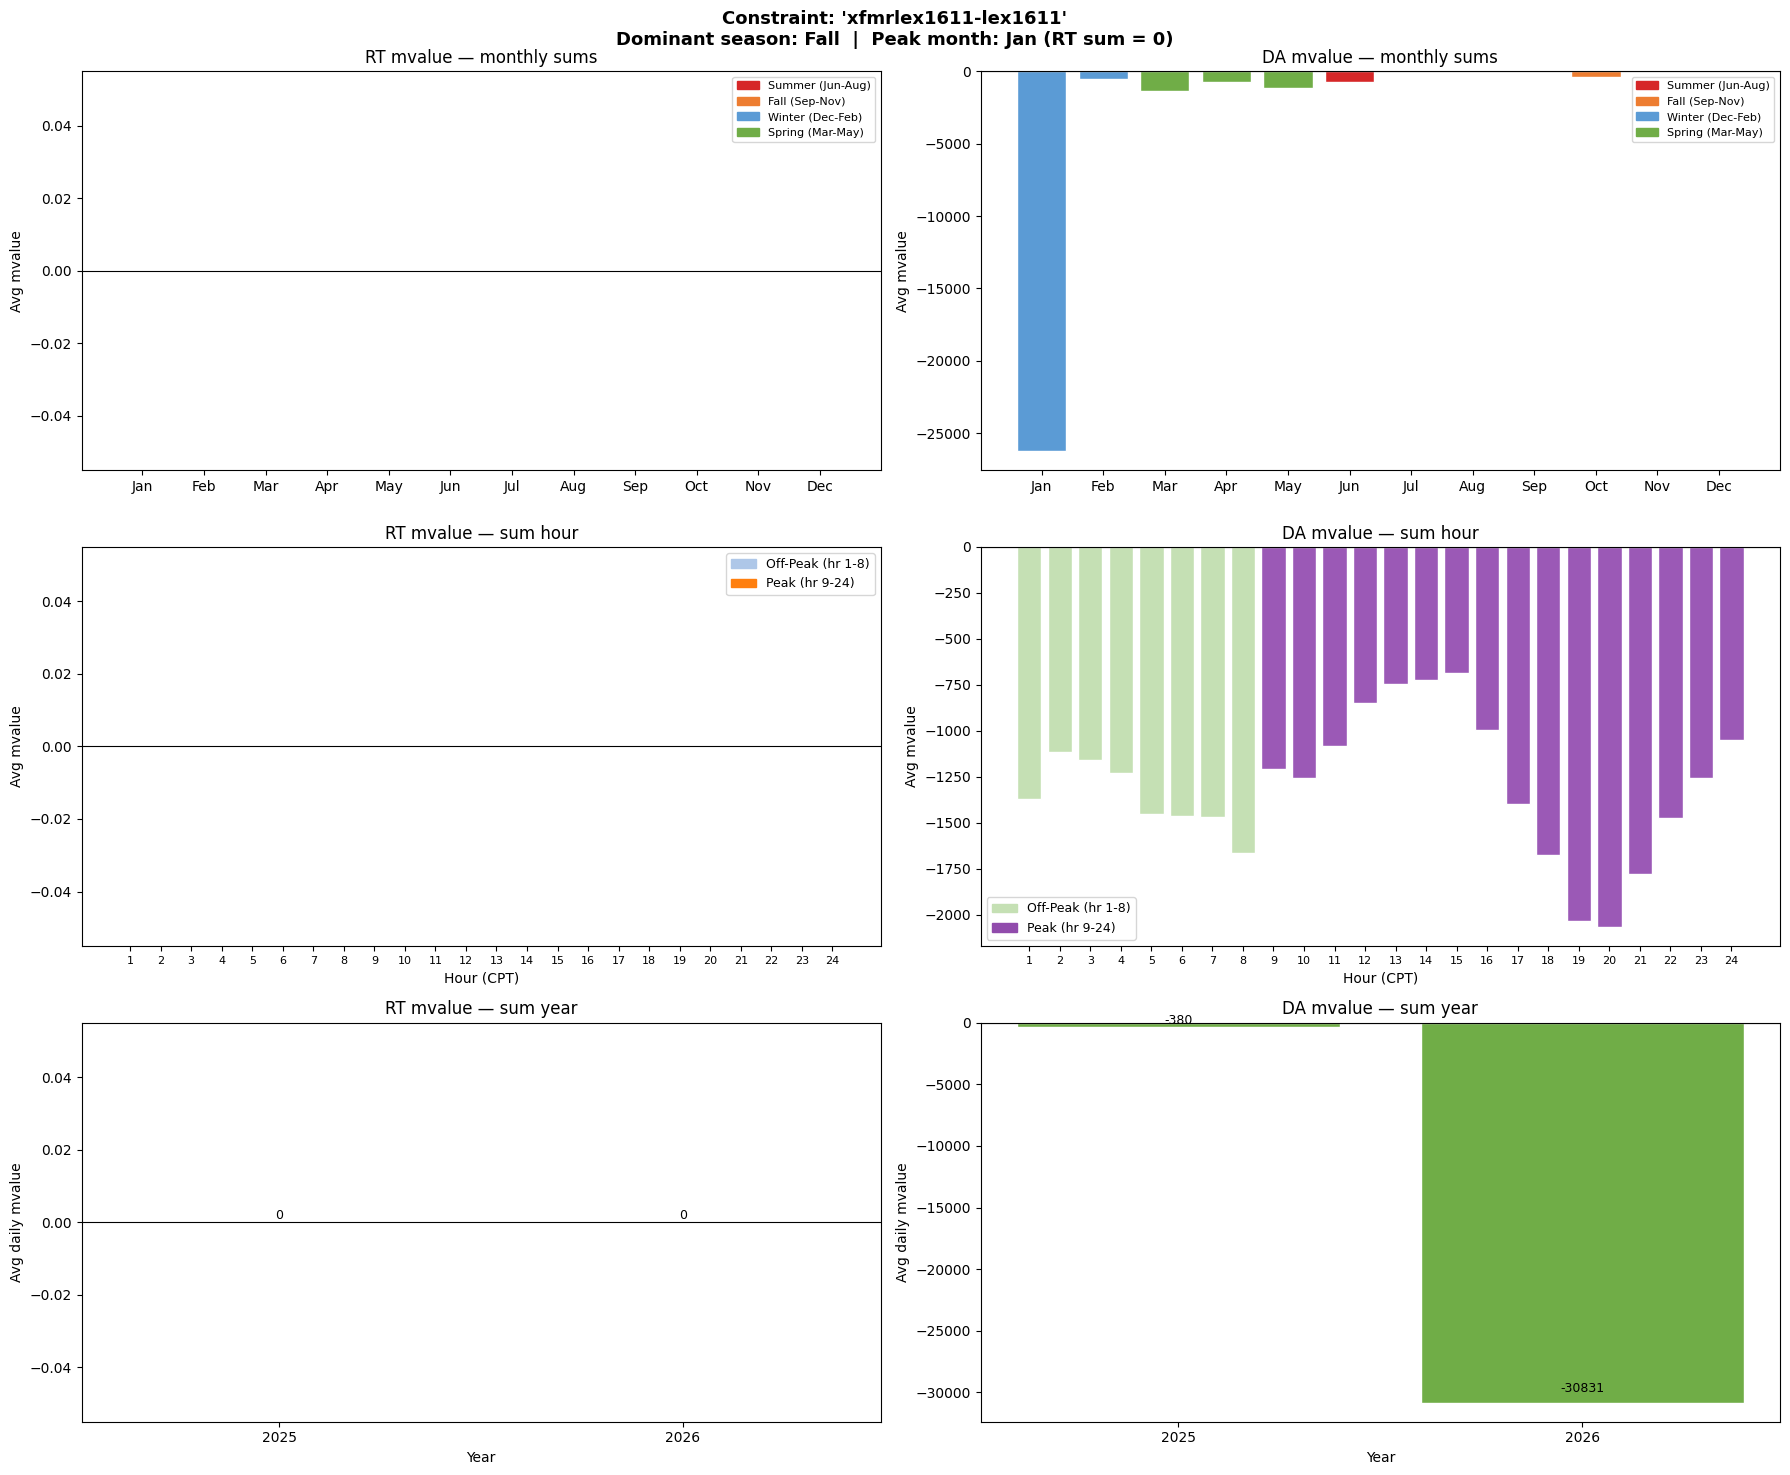

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -20284.17  |  off-peak (hr 1-8):  -10927.17
'xfmrlex1611-lex1611'  |  2026-05-30 → 2026-06-09  |  4 days


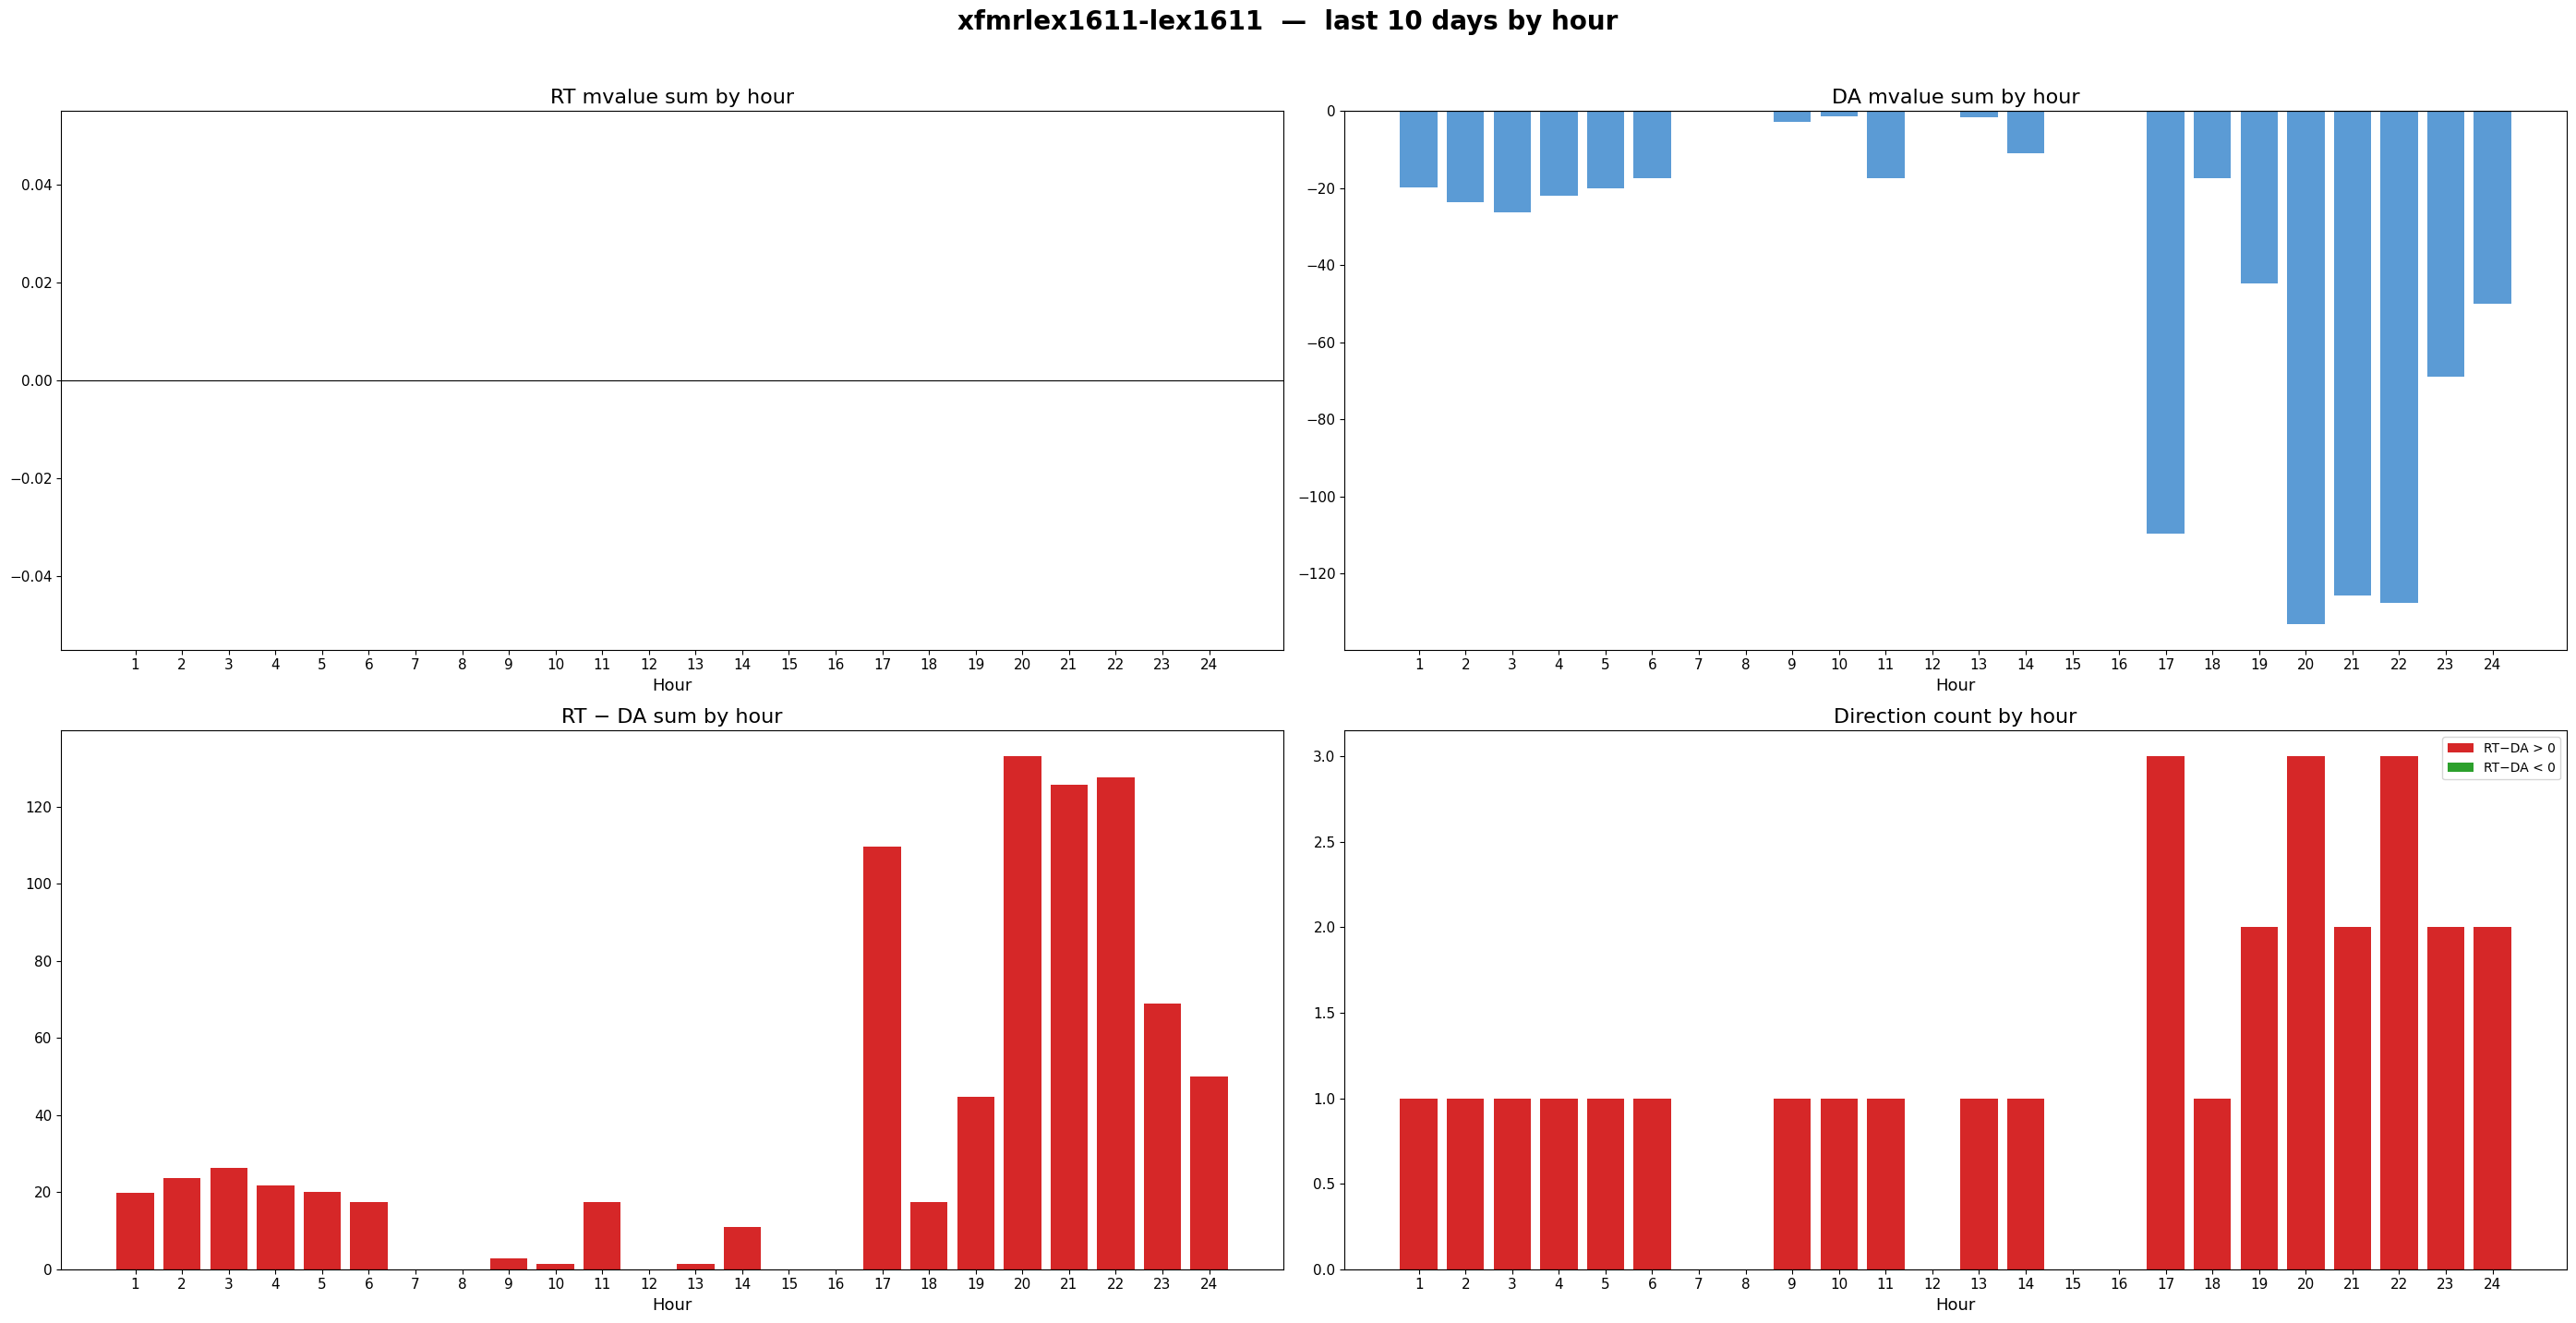

xfmrlex1611-lex1611 could not find the dfax value


Constraint  : 'xfmrsiouxcy-siouxcy'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0263  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,xfmrsiouxcy-siouxcy,4,rz4_spp_res_zonal_load_forecast_f,0.0263,0.1087,3.14
0,xfmrsiouxcy-siouxcy,4,rz4_spp_res_zonal_wind_forecast_f,0.0263,0.0011,-0.96


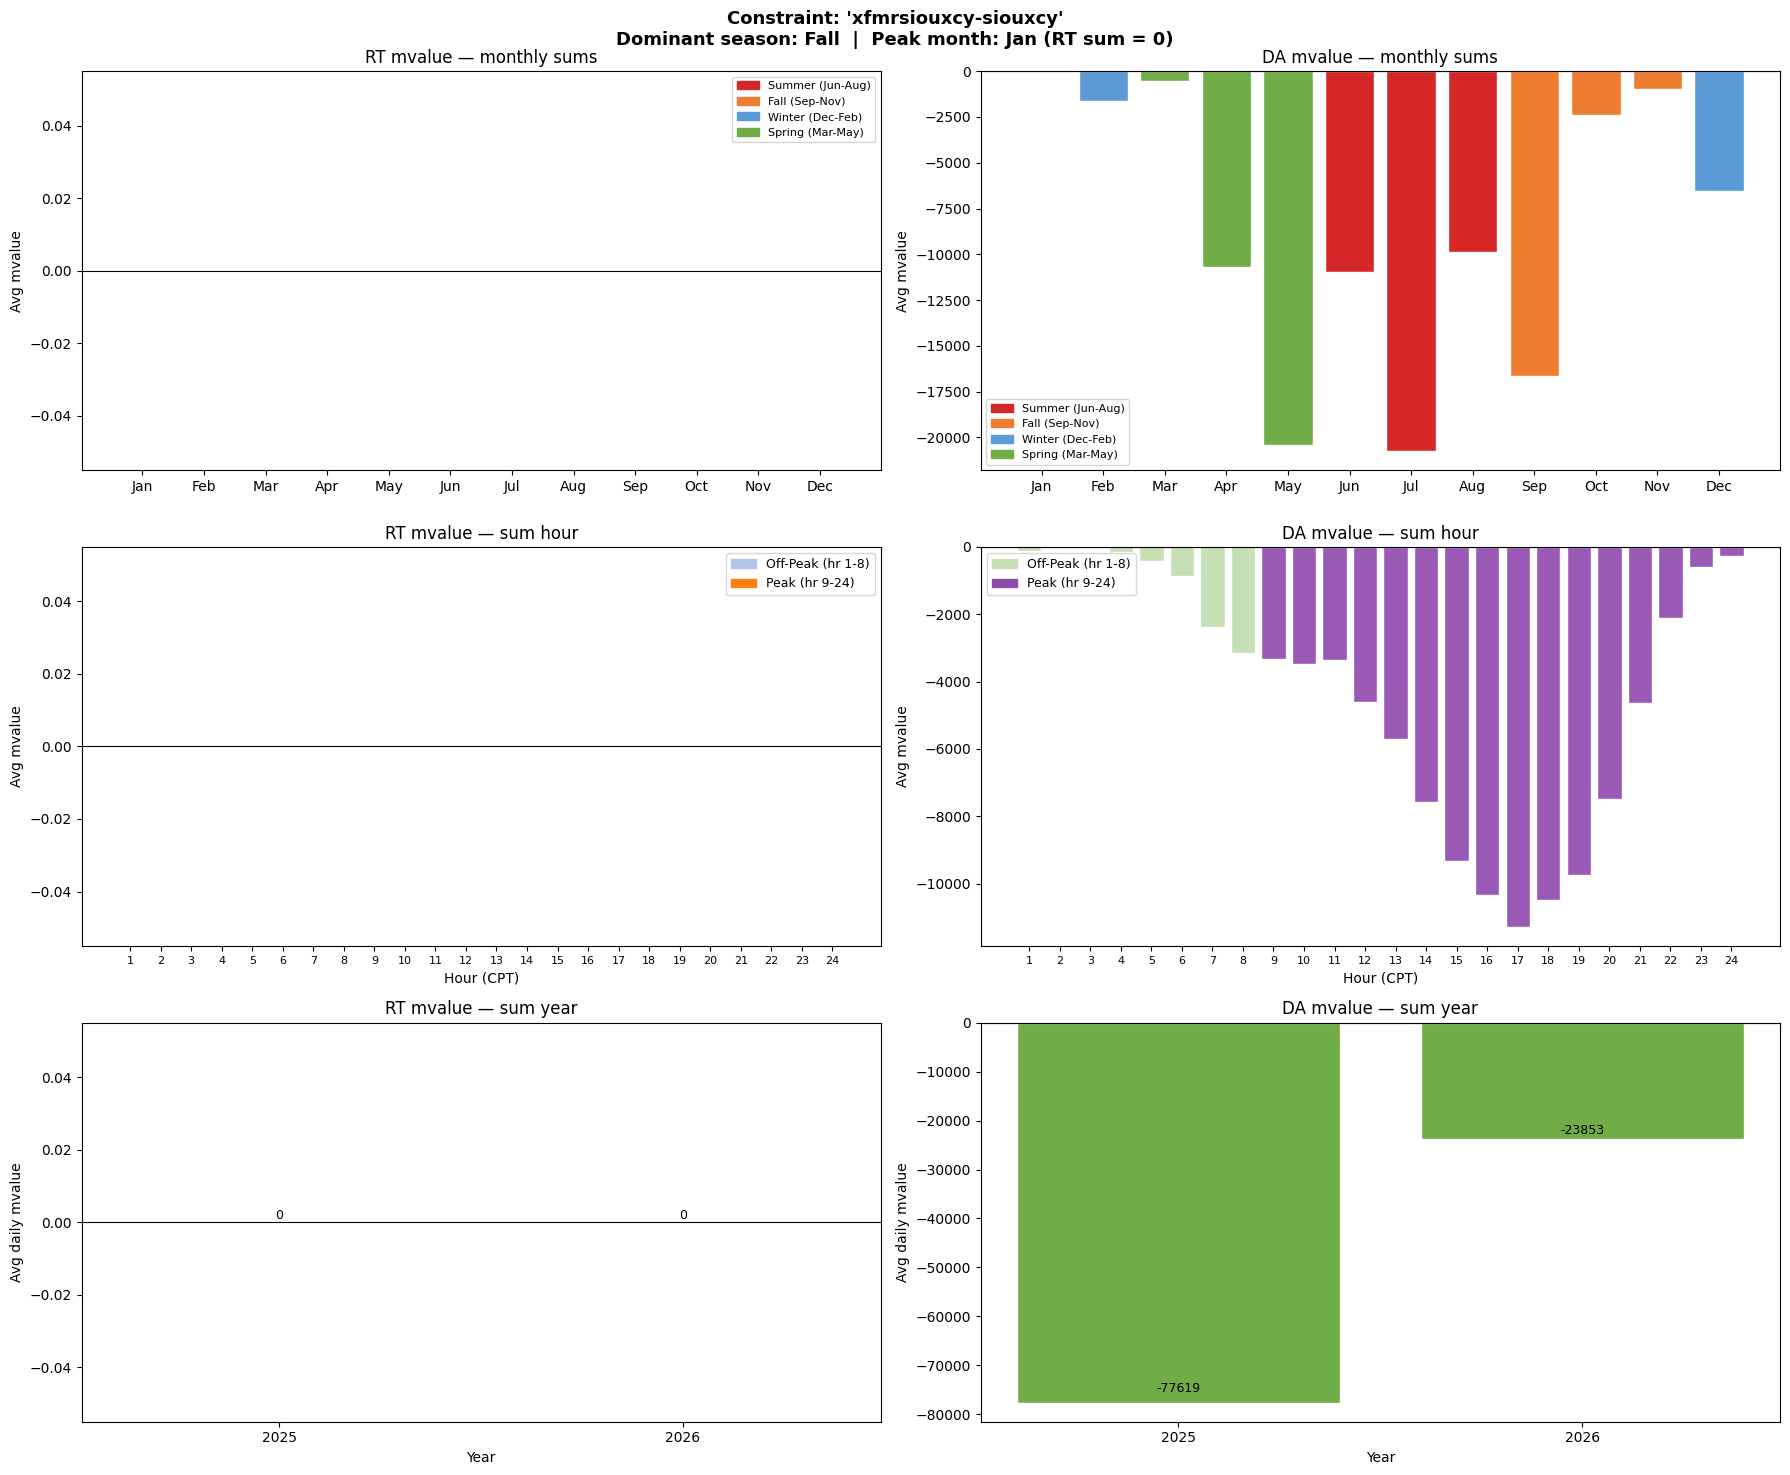

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -94365.17  |  off-peak (hr 1-8):   -7106.97
'xfmrsiouxcy-siouxcy'  |  2026-05-30 → 2026-06-09  |  7 days


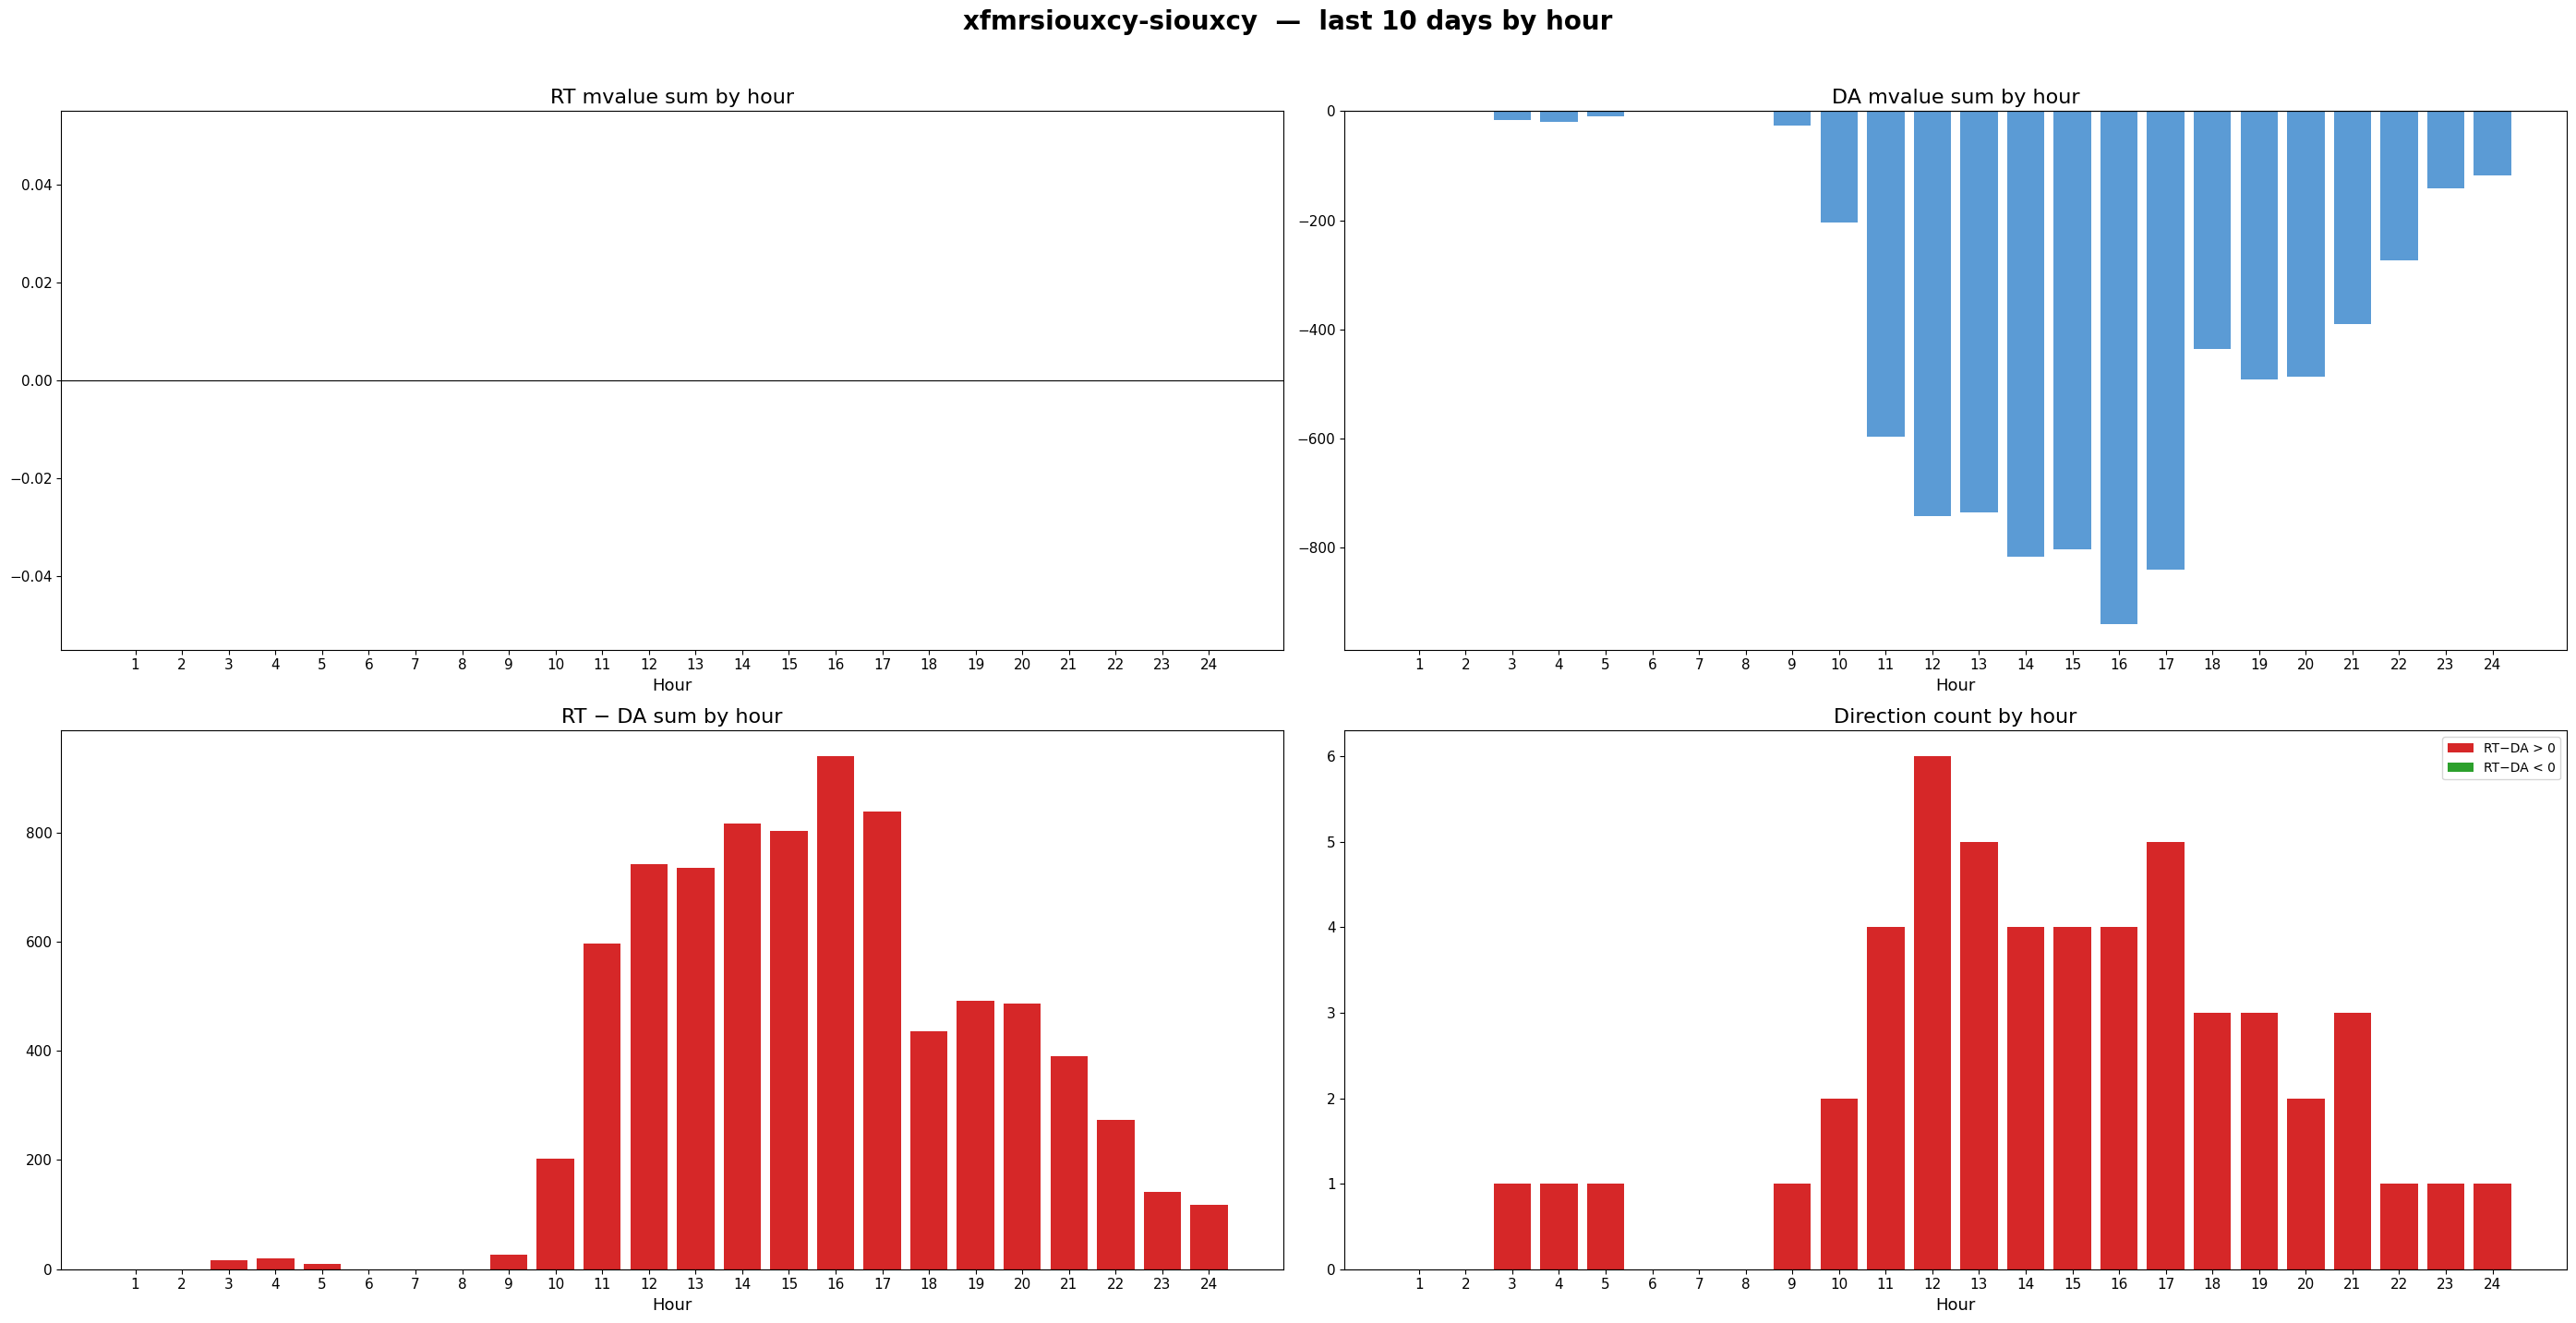


Total rows: 17901

  xfmrsiouxcy-siouxcy


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1176,0.1367,0.346354,0.757642,-30.258584,-15.749474,458.0
1,857,0.1029,0.326135,0.744541,-22.776945,-12.033454,458.0
2,934,0.1138,0.325326,0.748908,-25.189663,-13.079846,458.0
3,935,0.0963,0.315080,0.735808,-21.316033,-10.490388,458.0
4,900,0.0926,0.313282,0.733624,-20.497037,-10.165346,458.0
5,873,0.0879,0.313122,0.733624,-19.456690,-10.120847,458.0
6,938,0.1184,0.311671,0.744541,-26.207874,-12.261770,458.0
7,930,0.0903,0.310443,0.733624,-19.987931,-10.352895,458.0
8,904,0.1170,0.310398,0.744541,-25.897984,-12.027404,458.0
9,1233,0.1170,0.310398,0.744541,-25.897984,-12.027404,458.0


Constraint  : 'lnfirstcrk-roanrdge'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0302  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnfirstcrk-roanrdge,4,rz4_spp_res_zonal_load_forecast_f,0.0302,0.0938,2.11
0,lnfirstcrk-roanrdge,4,rz4_spp_res_zonal_wind_forecast_f,0.0302,0.0835,1.77


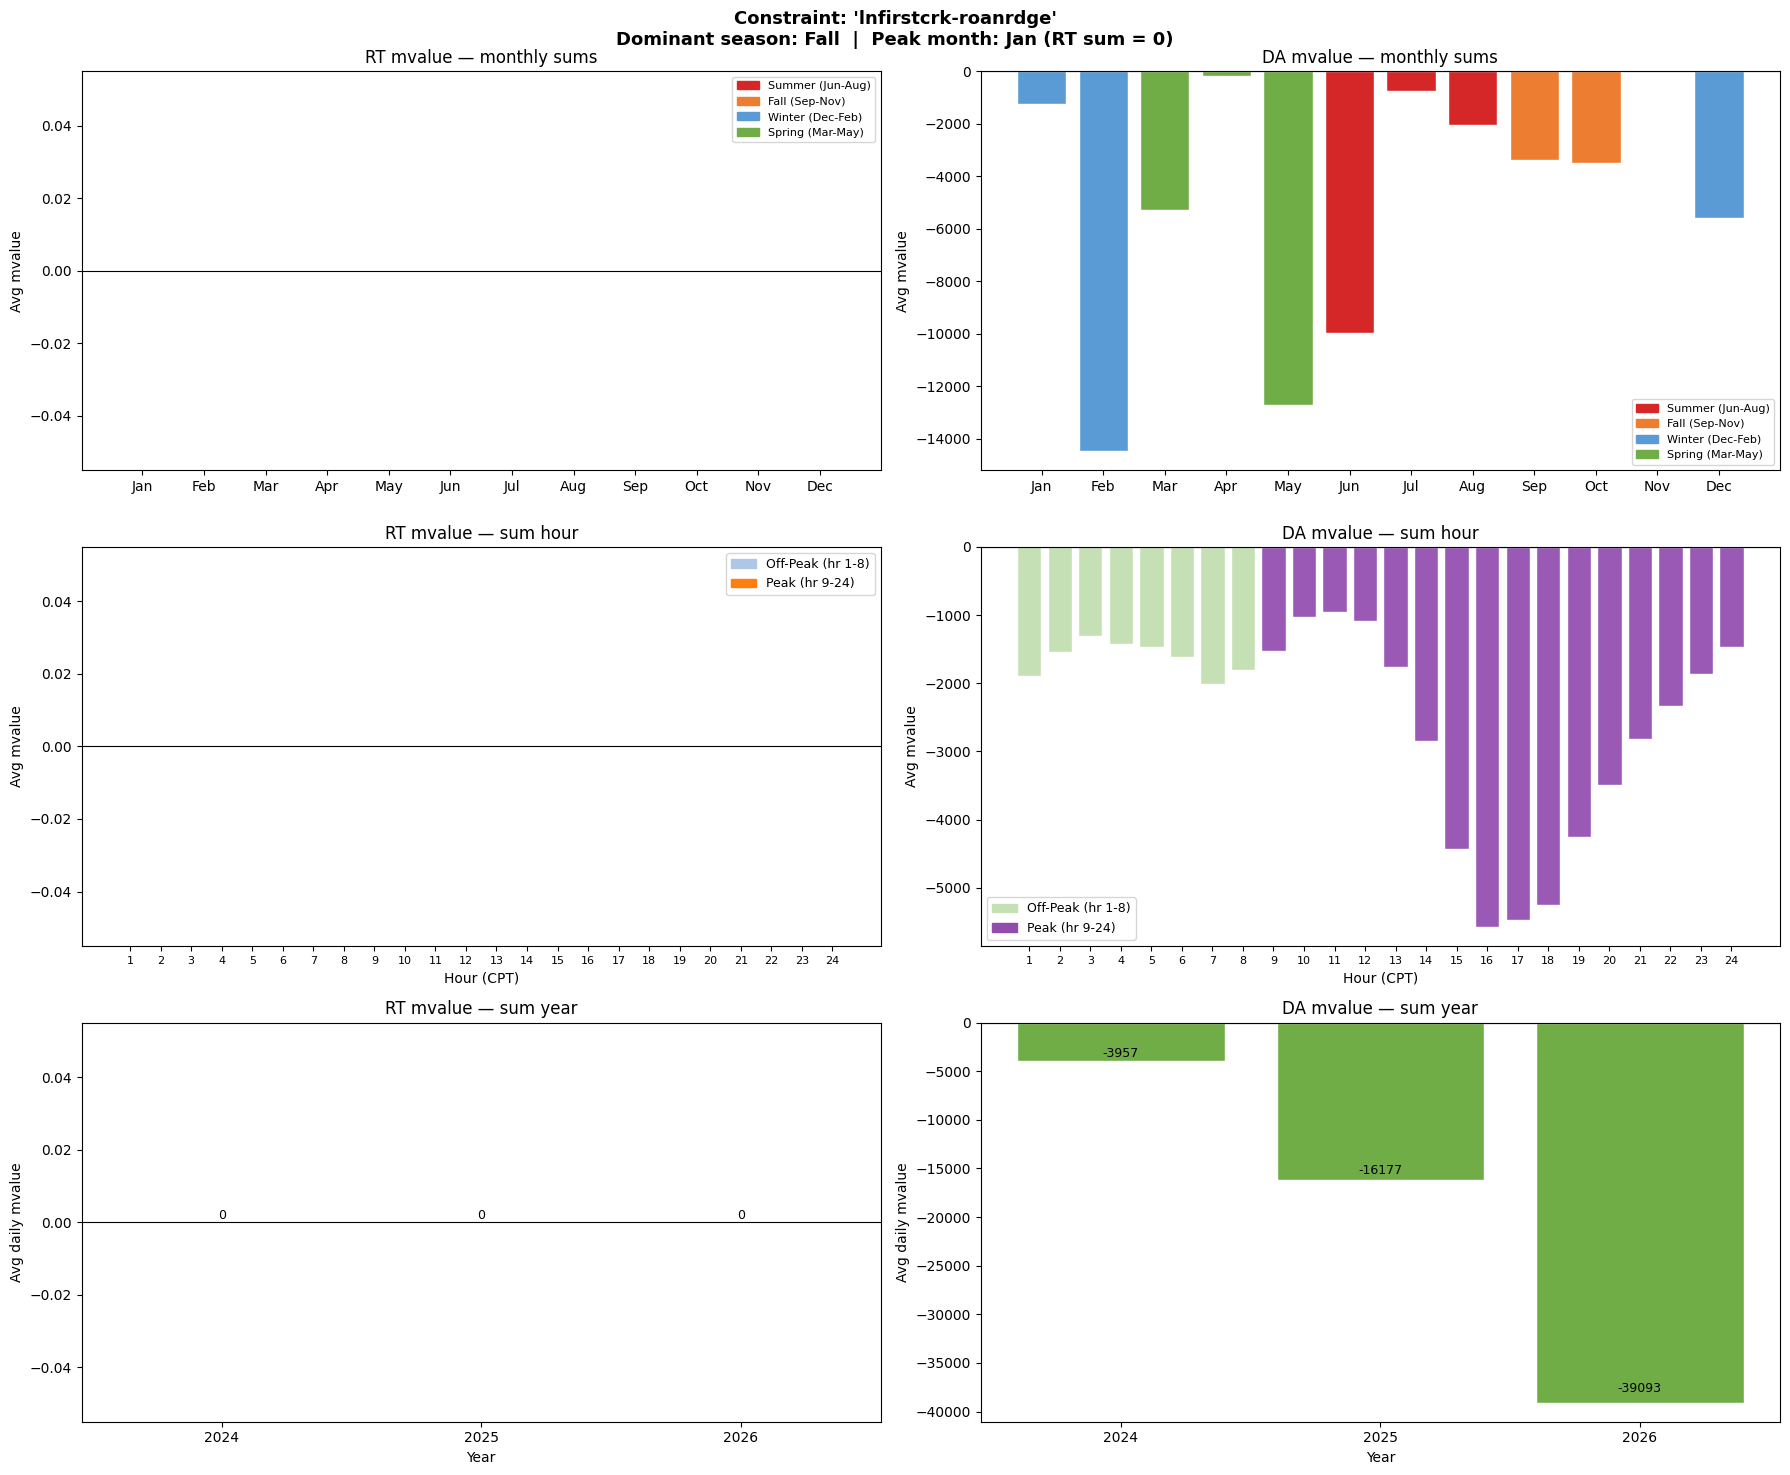

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -46168.30  |  off-peak (hr 1-8):  -13058.66
'lnfirstcrk-roanrdge'  |  2026-05-30 → 2026-06-09  |  6 days


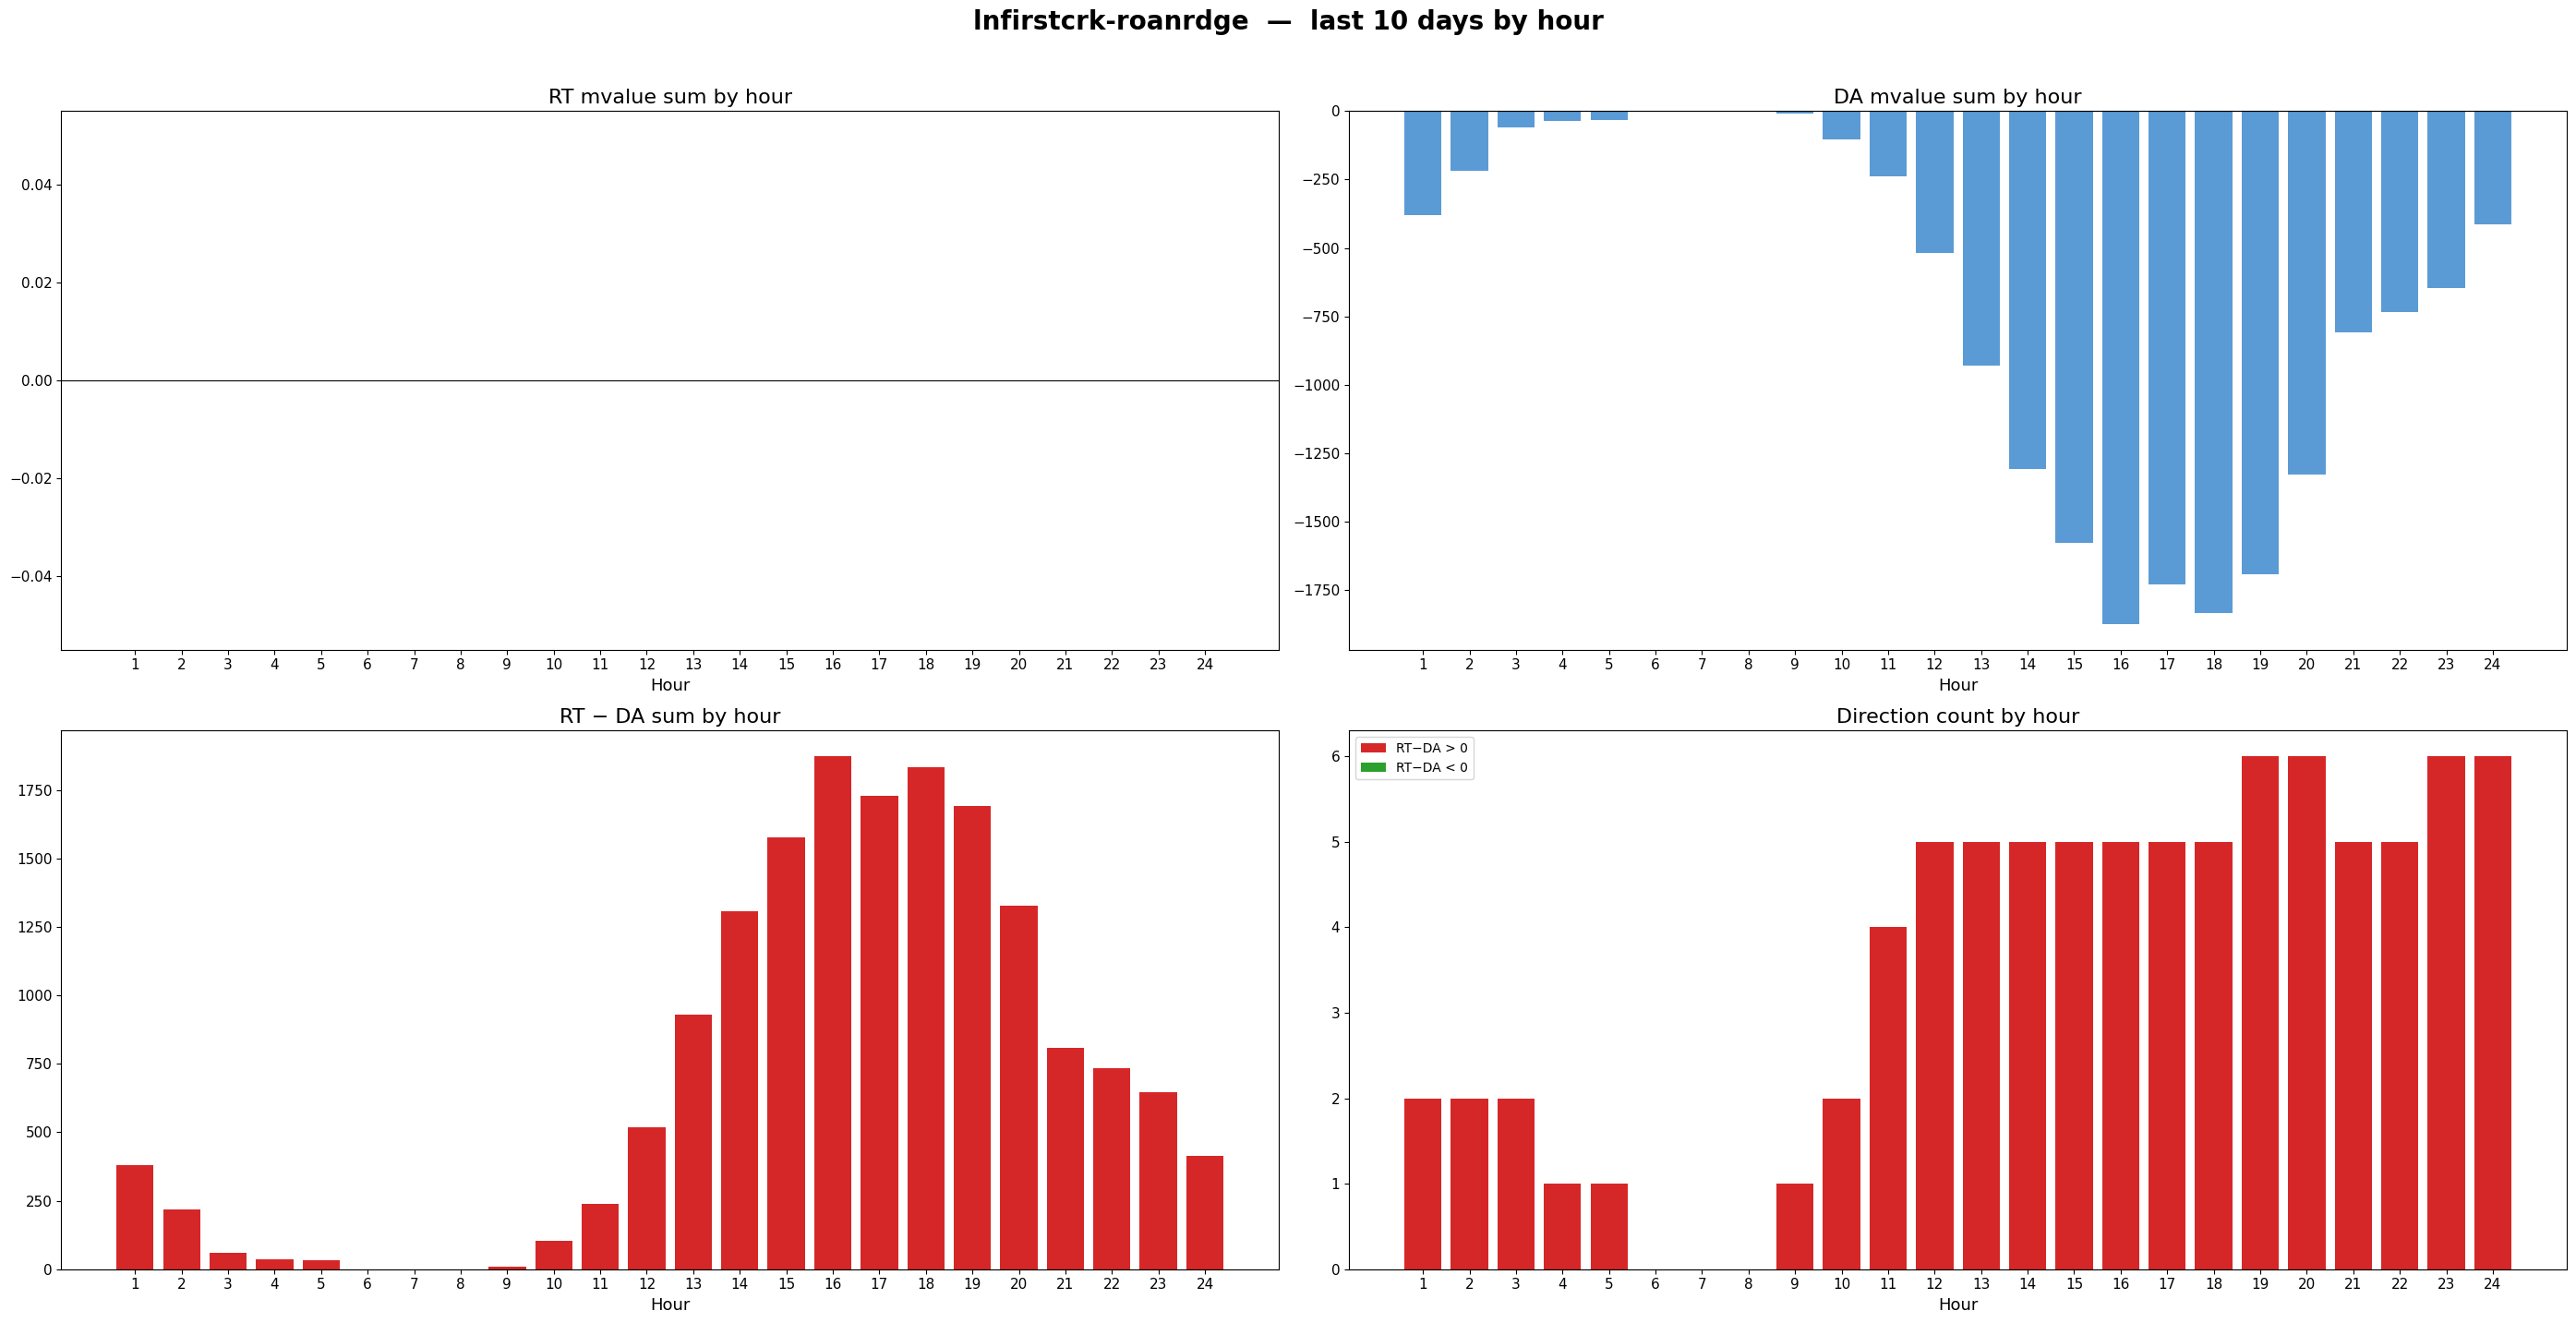


Total rows: 9768

  lnfirstcrk-roanrdge


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,233,0.1212,0.019348,0.688581,-17.711957,3.829394,289.0
1,274,0.0521,0.018718,0.608997,-7.613803,3.797766,289.0
2,232,0.1146,0.012235,0.681661,-16.747444,4.026237,289.0
3,1008,-0.0580,0.011001,0.439446,8.476019,1.046604,289.0
4,237,0.1158,0.009707,0.678201,-16.922810,4.290742,289.0
5,1671,0.0573,0.002418,0.653979,-8.373722,4.689351,289.0
6,228,0.1284,0.001691,0.692042,-18.764152,4.241175,289.0
7,230,0.1284,0.001690,0.692042,-18.764152,4.241056,289.0
8,1711,0.0613,-0.008755,0.643599,-8.958275,4.237197,289.0
9,262,0.0747,-0.015663,0.653979,-10.916528,4.658044,289.0


Constraint  : 'lnaur1241-rdspg5'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0377  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnaur1241-rdspg5,4,rz4_spp_res_zonal_wind_forecast_f,0.0377,0.1854,3.92
1,lnaur1241-rdspg5,4,rz4_spp_res_zonal_load_forecast_f,0.0377,0.0034,-0.91


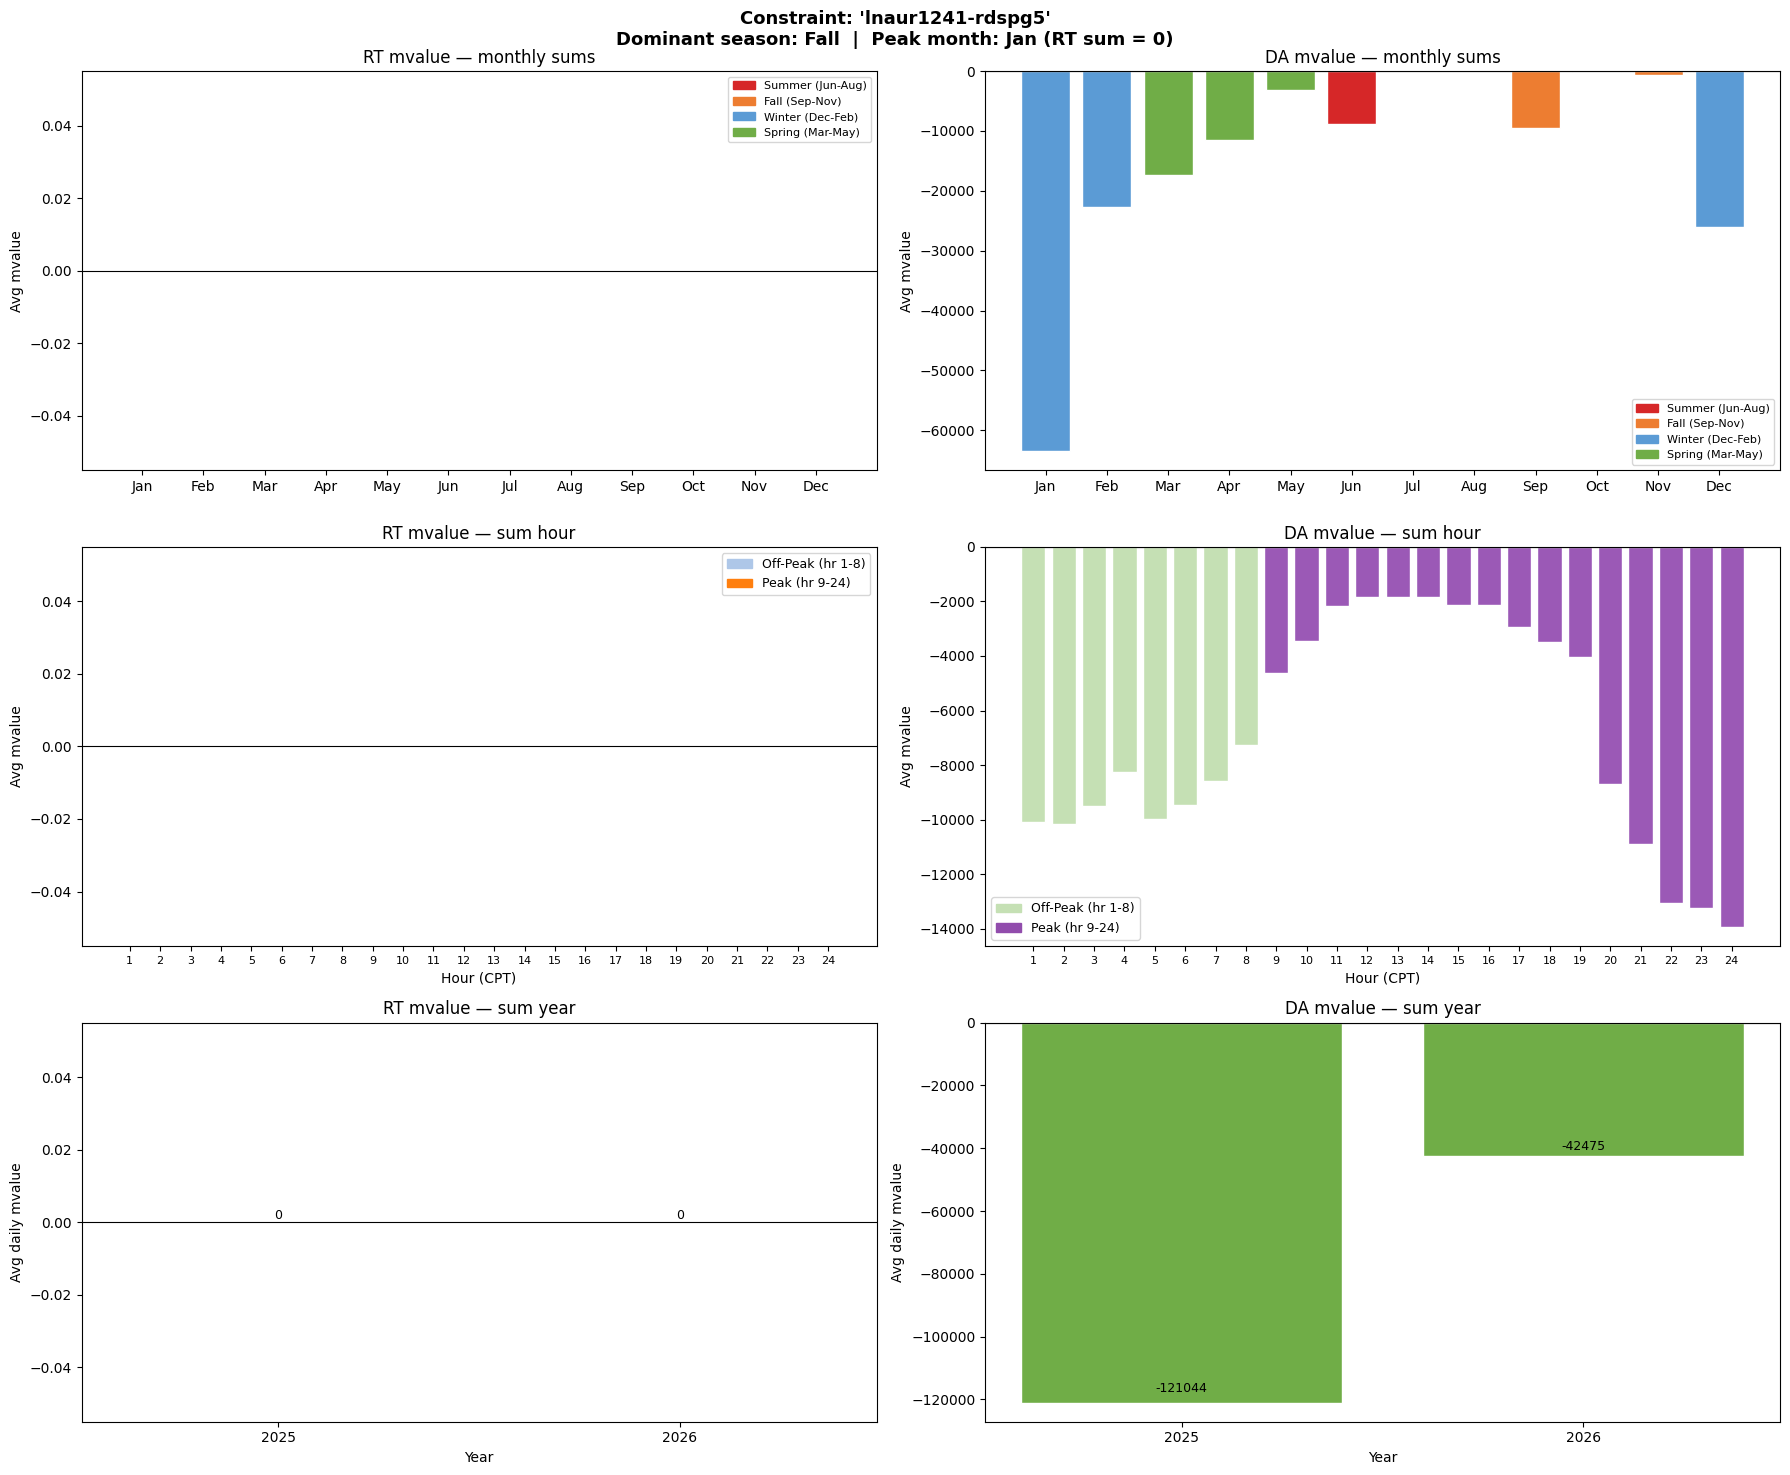

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -90243.13  |  off-peak (hr 1-8):  -73275.86
'lnaur1241-rdspg5'  |  2026-05-30 → 2026-06-09  |  5 days


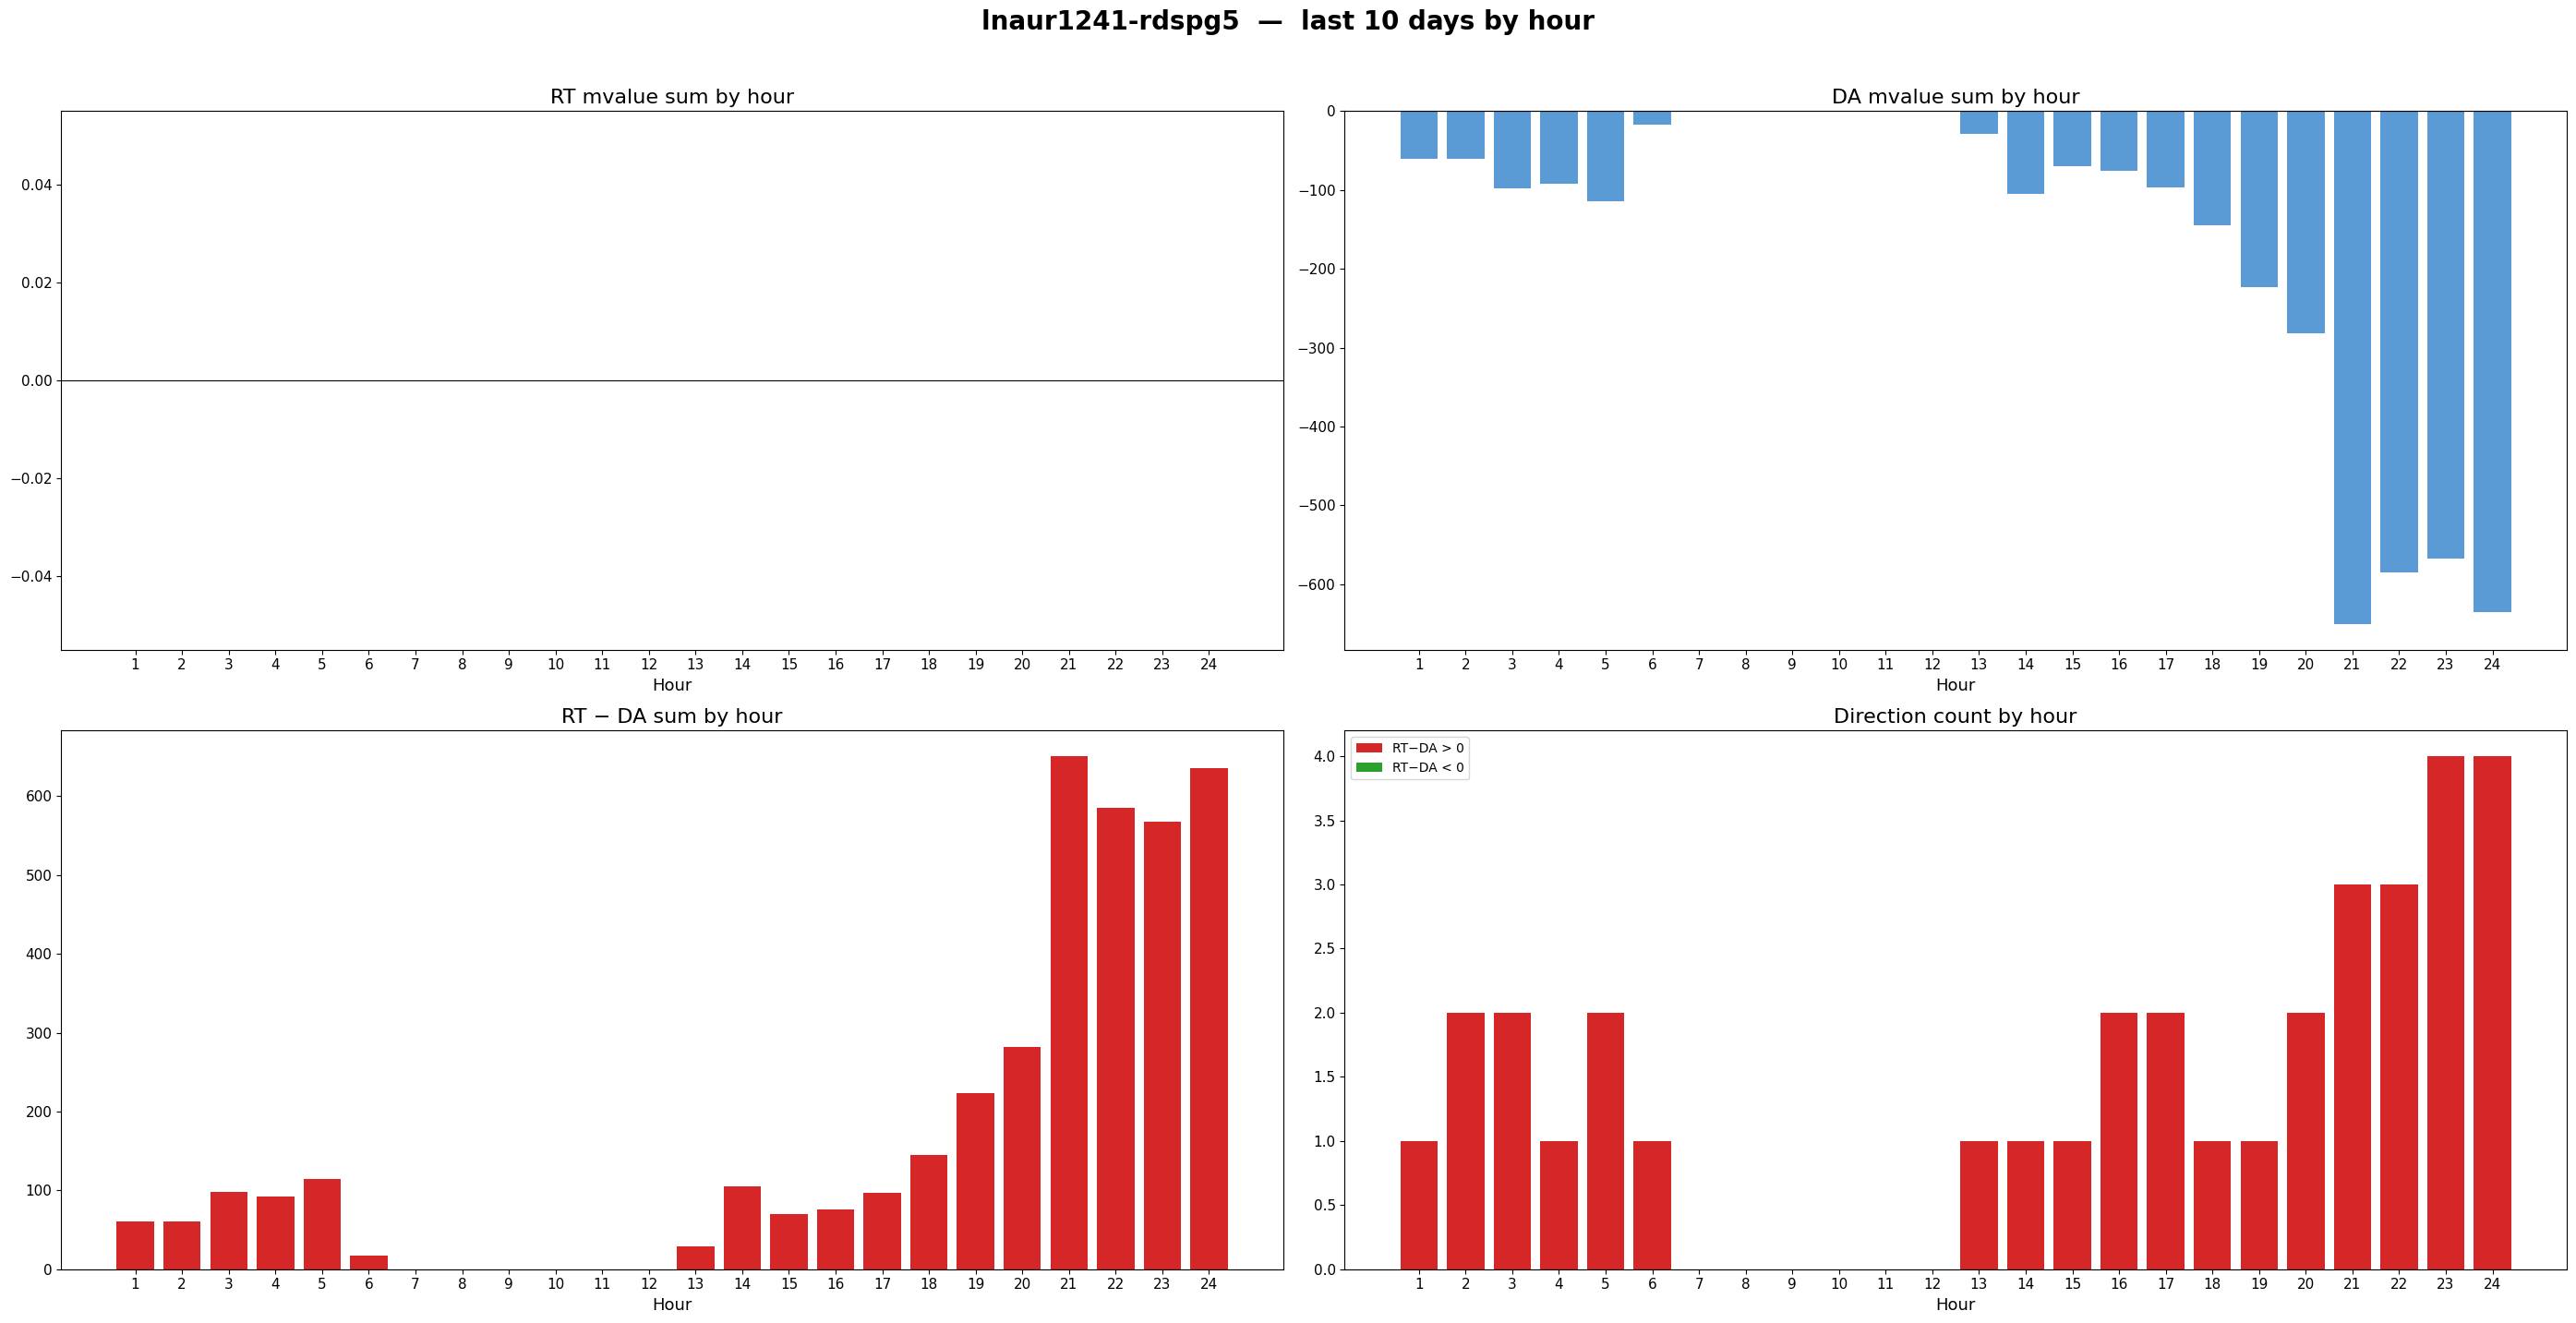


Total rows: 7896

  lnaur1241-rdspg5


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1213,-0.1121,0.376056,0.636086,27.978820,9.843291,654.0
1,135,-0.0715,0.302467,0.565749,17.845545,4.876833,654.0
2,136,-0.0715,0.302467,0.565749,17.845545,4.876833,654.0
3,1220,-0.0715,0.302467,0.565749,17.845545,4.876833,654.0
4,133,-0.0715,0.302436,0.565749,17.845545,4.876990,654.0
5,134,-0.0715,0.302428,0.565749,17.845545,4.879297,654.0
6,1591,-0.0522,0.272065,0.526690,14.527176,4.773533,281.0
7,1264,-0.0508,0.259139,0.509174,12.679073,2.776859,654.0
8,143,0.2265,0.145491,0.761468,-56.531692,-19.408630,654.0
9,144,0.2265,0.145491,0.761468,-56.531692,-19.408630,654.0


Constraint  : 'lnquail-skyln'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0463  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnquail-skyln,4,rz4_spp_res_zonal_wind_forecast_f,0.0463,0.2162,3.67
1,lnquail-skyln,4,rz4_spp_res_zonal_load_forecast_f,0.0463,0.0275,-0.41


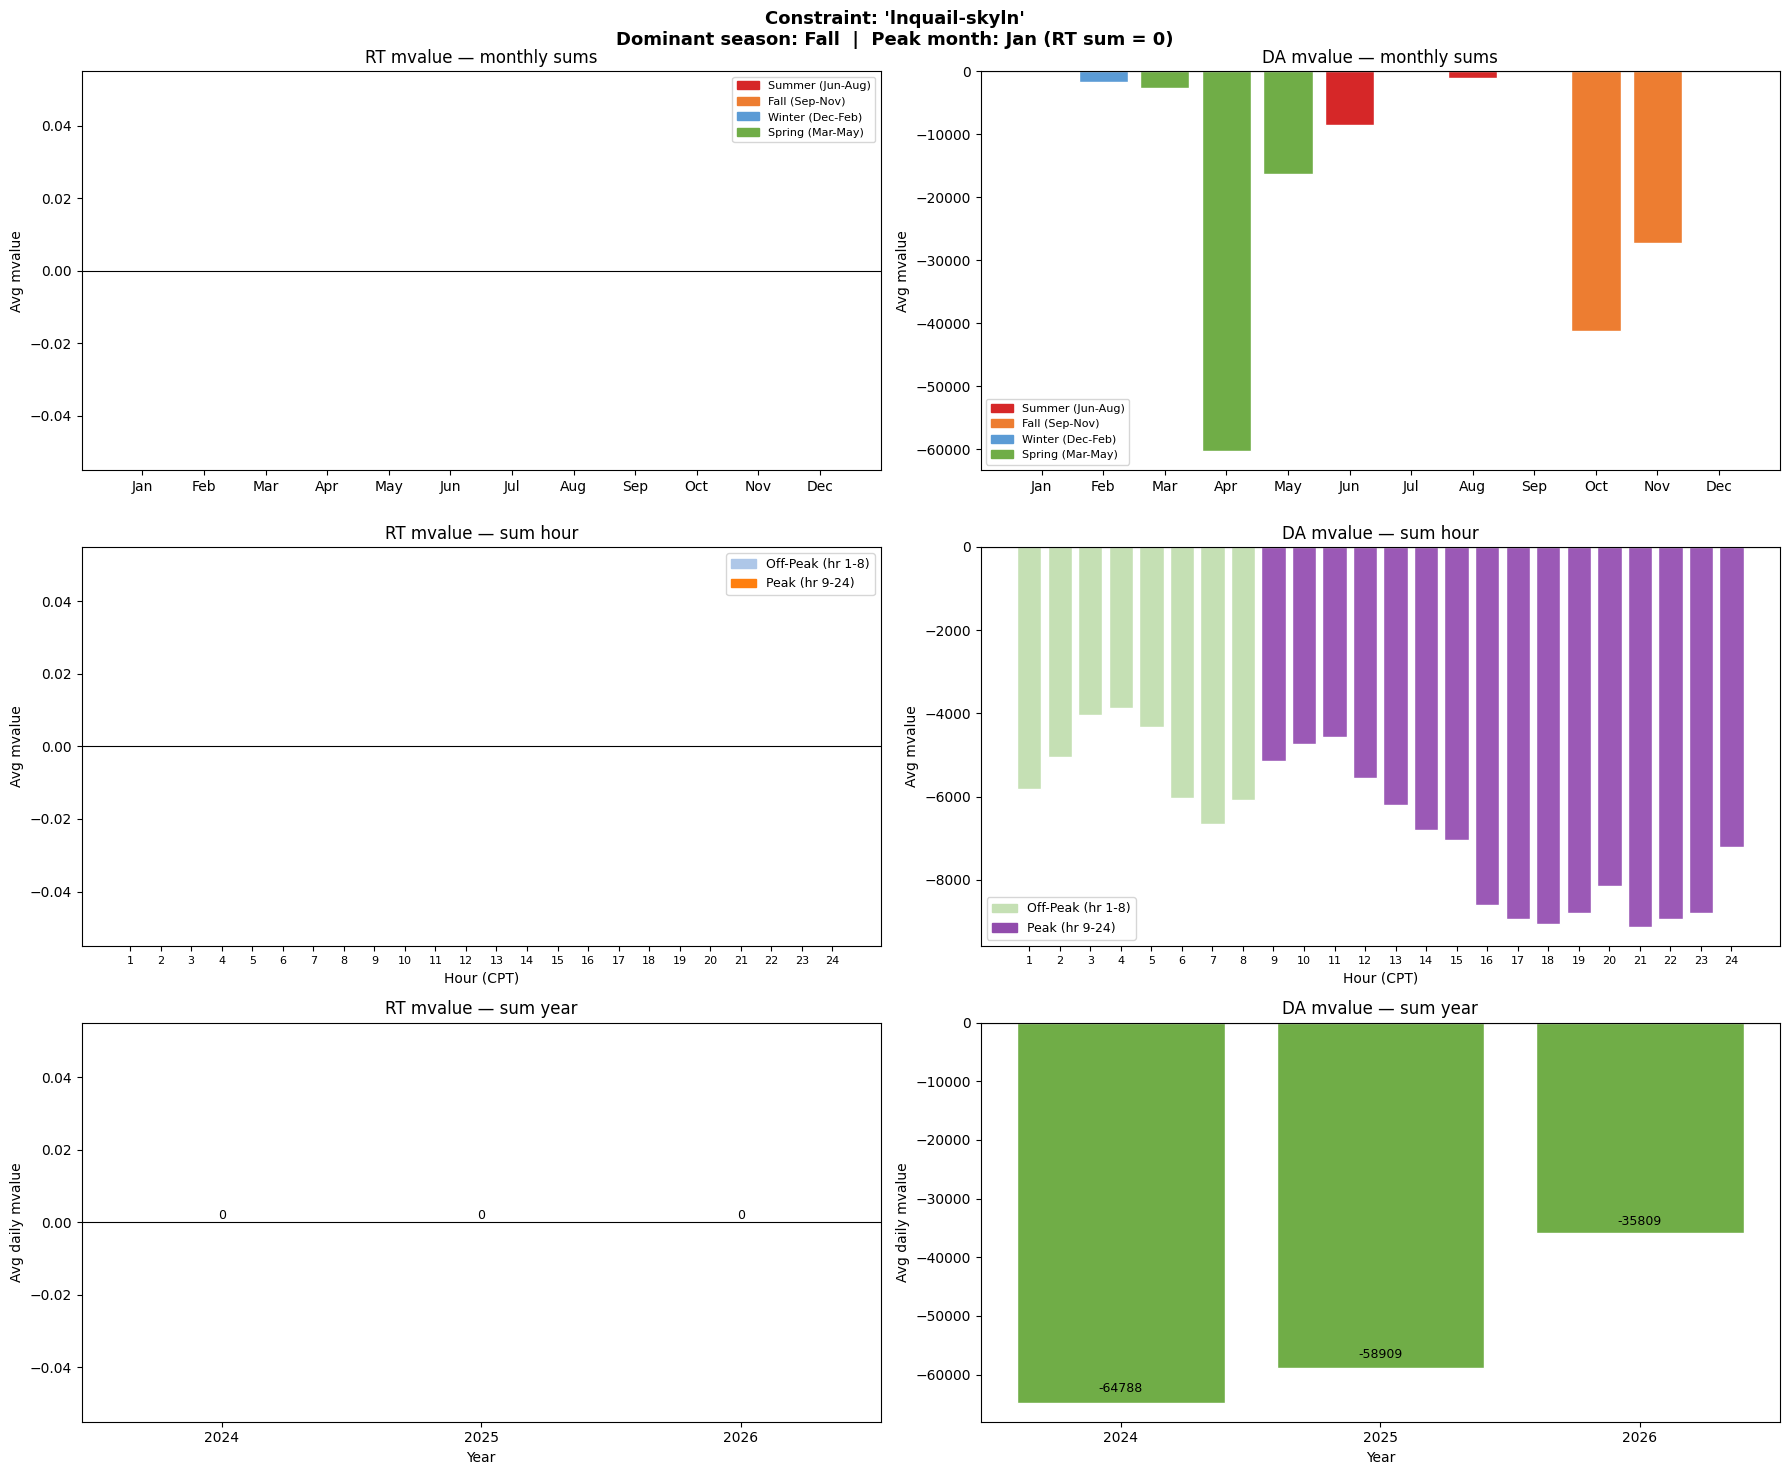

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24): -117650.72  |  off-peak (hr 1-8):  -41854.97
'lnquail-skyln'  |  2026-05-30 → 2026-06-09  |  7 days


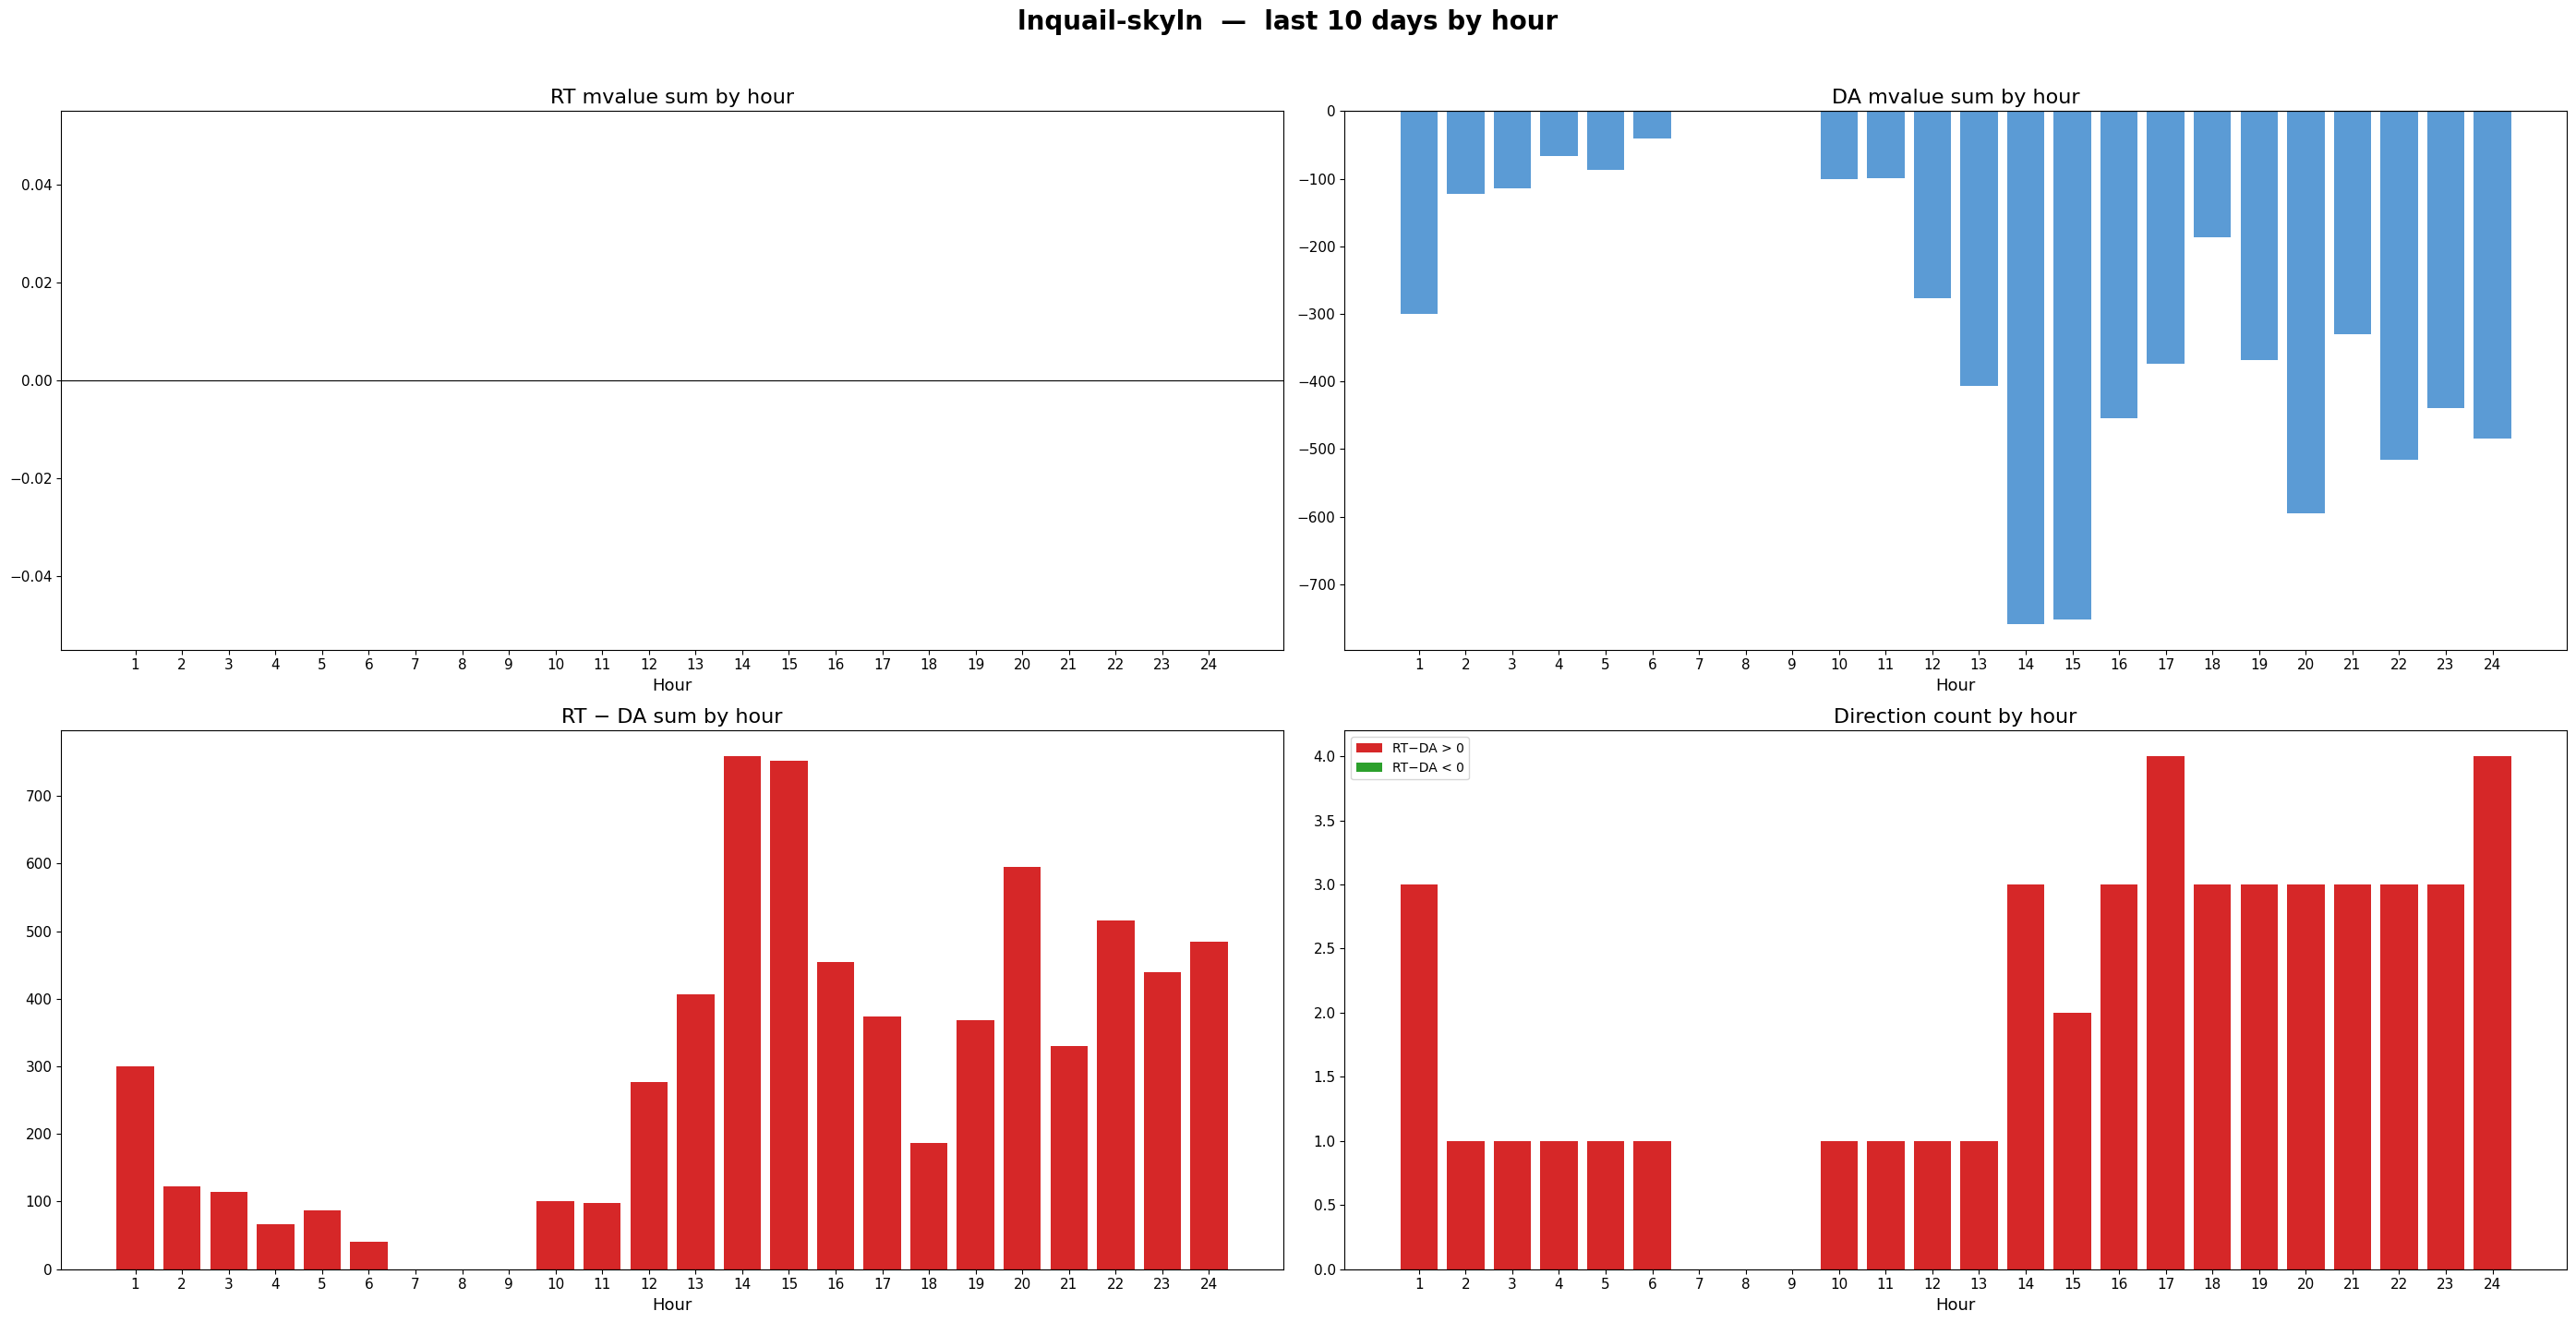


Total rows: 22036

  lnquail-skyln


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,550,0.0580,0.226850,0.737516,-11.505597,-9.066690,781.0
1,501,0.1039,0.221168,0.687850,-22.390905,-9.351886,535.0
2,514,0.0796,0.219755,0.723431,-15.790440,-9.868364,781.0
3,513,0.0796,0.219671,0.722151,-15.790440,-9.866598,781.0
4,515,0.0796,0.219666,0.724712,-15.790440,-9.875400,781.0
5,516,0.0796,0.219572,0.724712,-15.790440,-9.878546,781.0
6,503,0.1039,0.196711,0.677337,-20.610888,-7.157574,781.0
7,502,0.1039,0.195681,0.677337,-20.610888,-7.125247,781.0
8,1419,0.1683,0.177084,0.697196,-36.269386,-20.619009,535.0
9,495,-0.0668,0.087029,0.405890,13.251274,-2.799507,781.0


Constraint  : 'xfmrduncan-duncan'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0836  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,xfmrduncan-duncan,4,rz4_spp_res_zonal_wind_forecast_f,0.0836,0.2357,1.82
1,xfmrduncan-duncan,4,rz4_spp_res_zonal_load_forecast_f,0.0836,0.0961,0.15


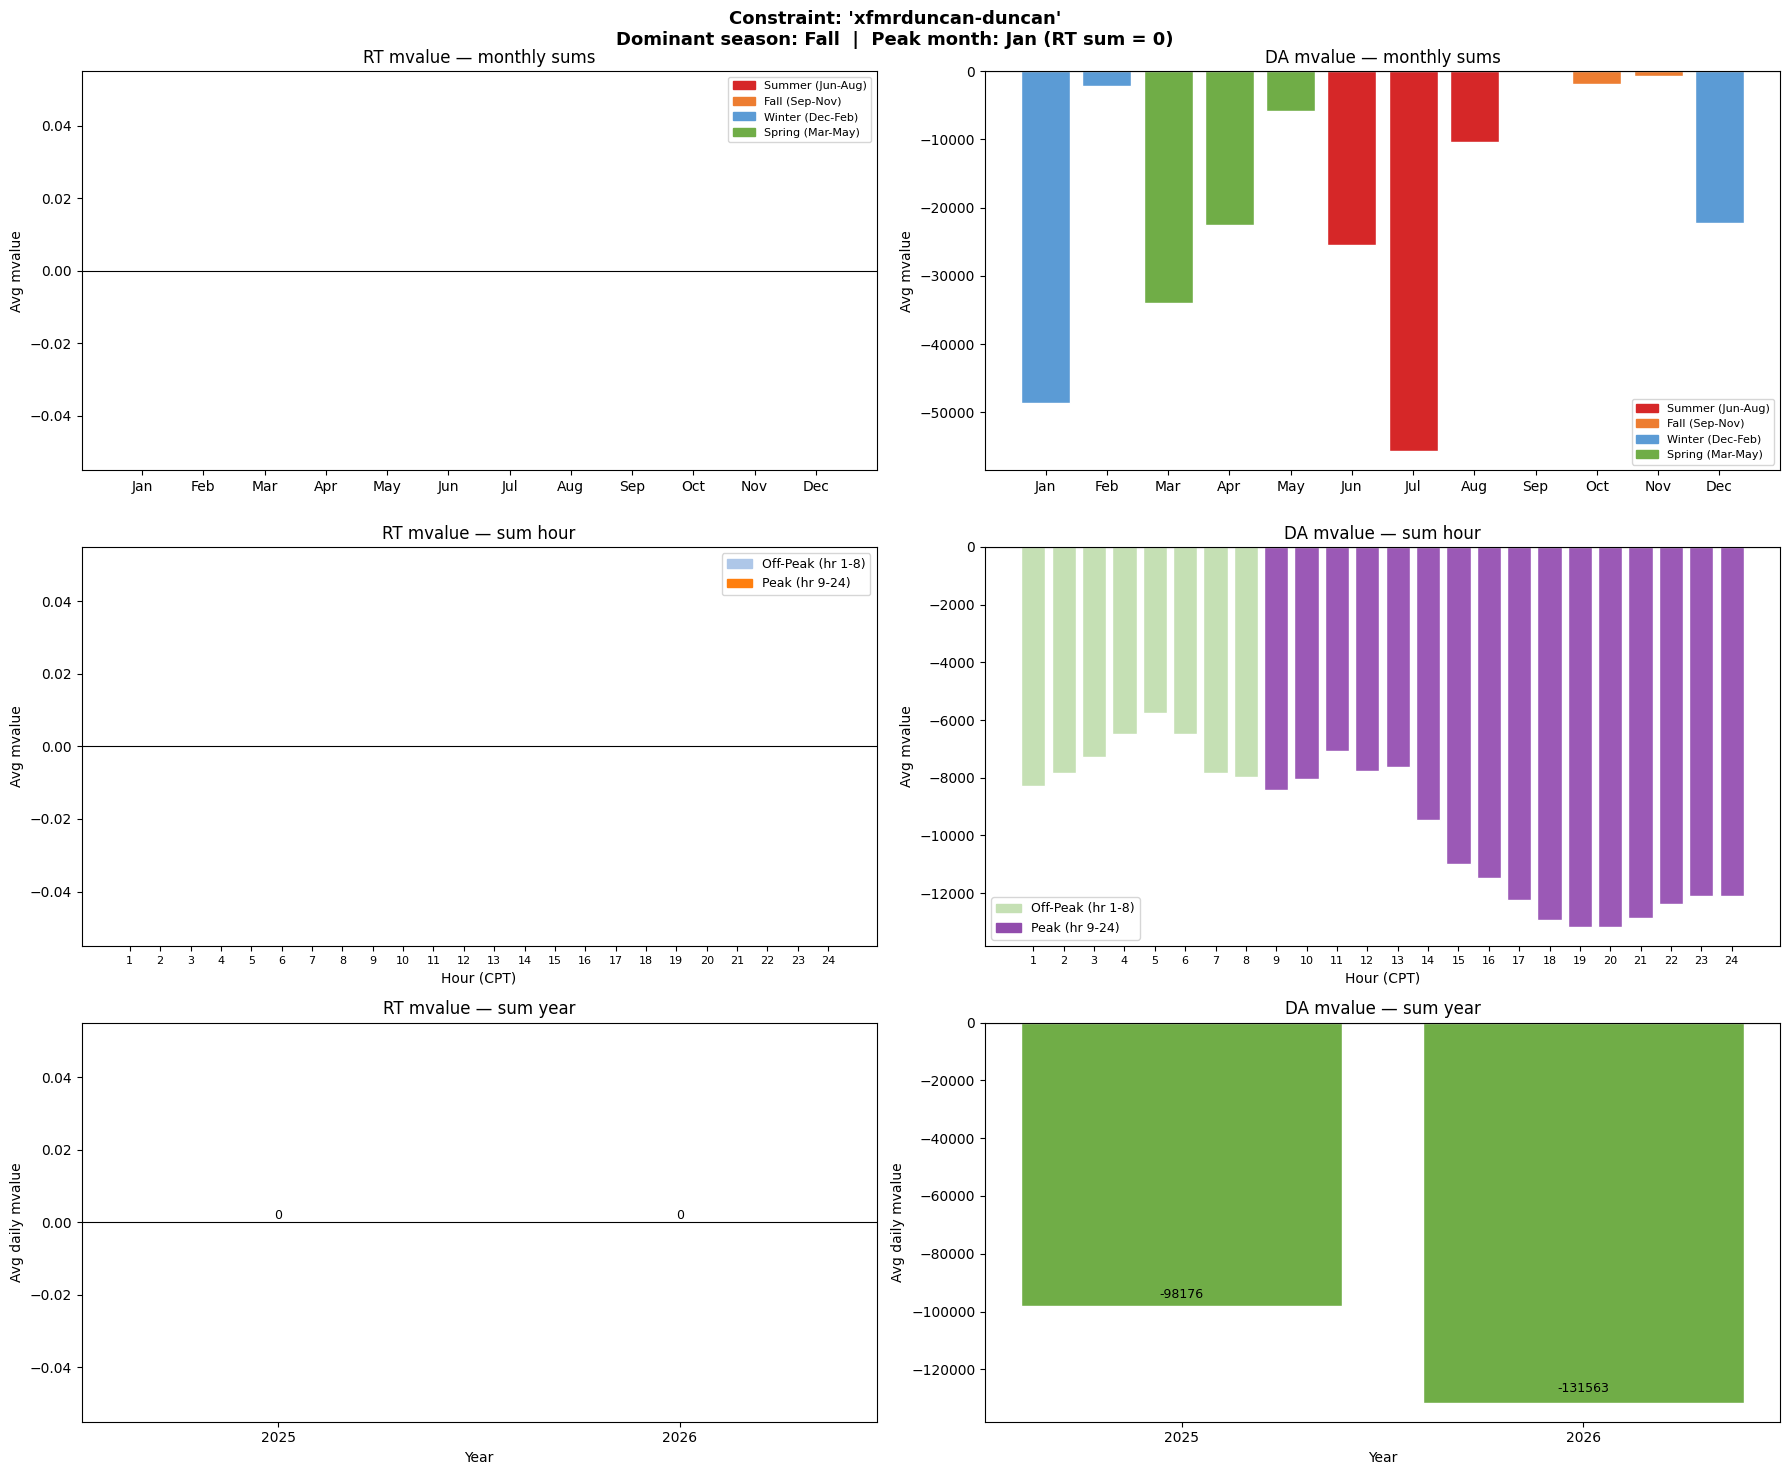

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24): -171811.26  |  off-peak (hr 1-8):  -57927.79
'xfmrduncan-duncan'  |  2026-05-30 → 2026-06-09  |  10 days


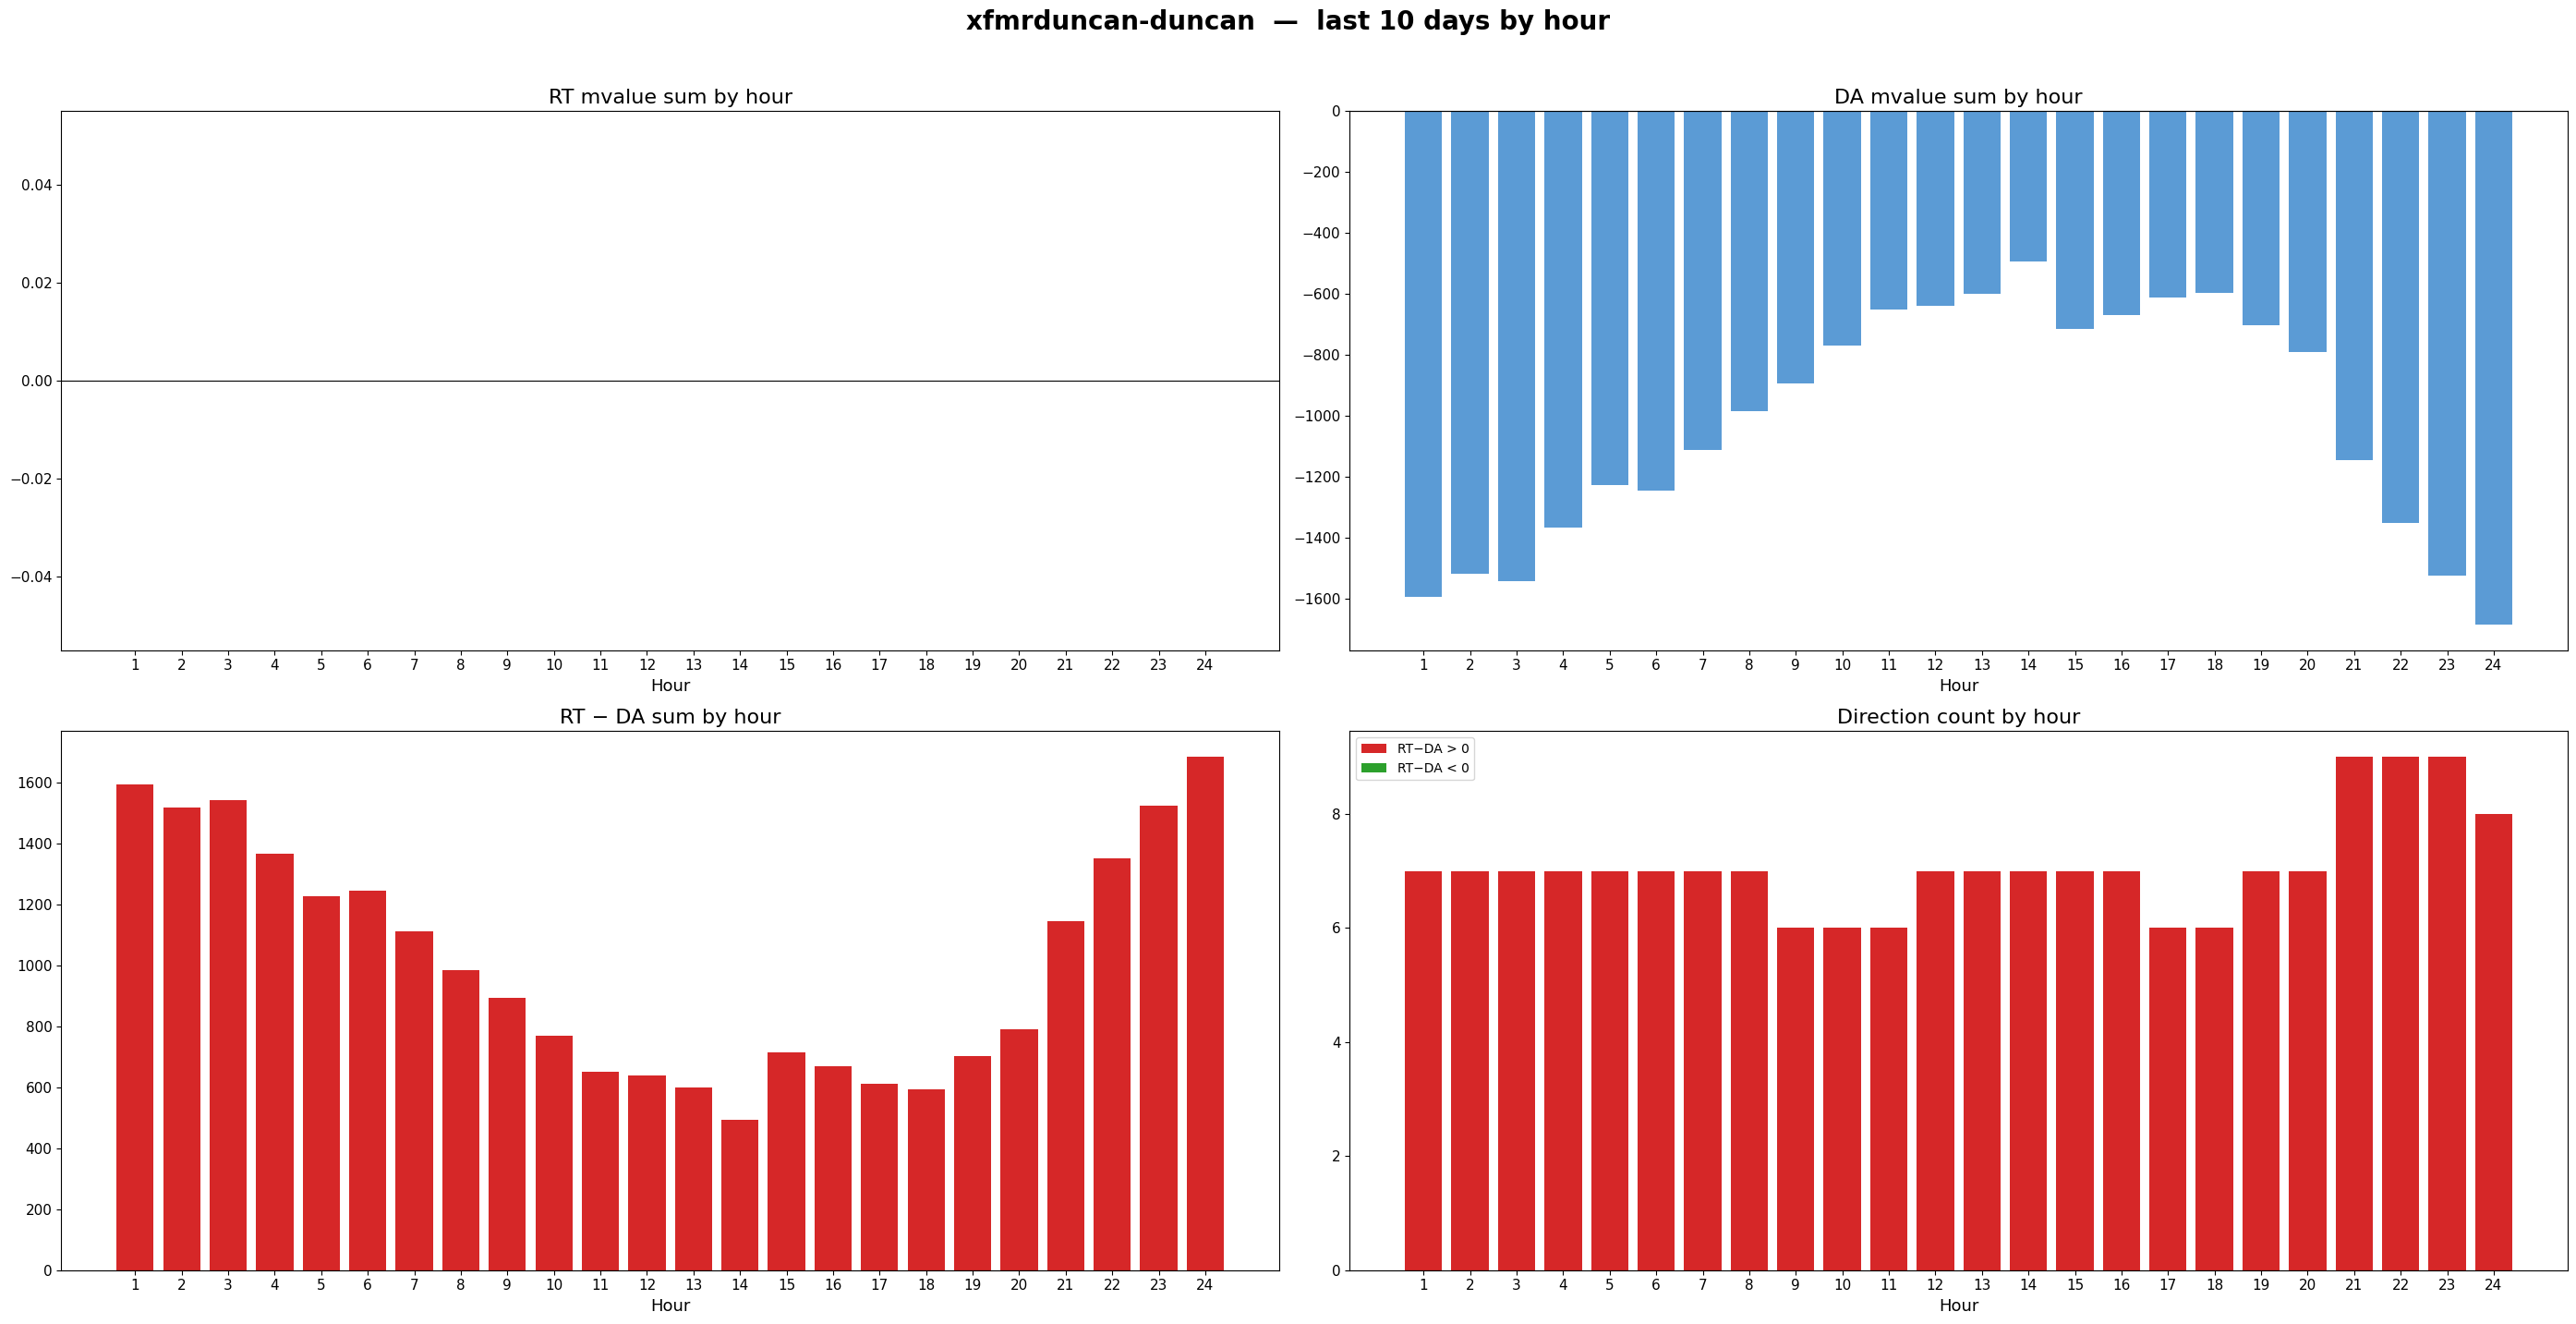


Total rows: 2095

  xfmrduncan-duncan


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1715,0.5448,0.274860,0.773881,-59.179418,-14.812938,1340.0
1,1039,-0.0611,0.097269,0.429936,11.226136,-1.232668,628.0


Constraint  : 'lnosage_og-webbtap4'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.1042  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnosage_og-webbtap4,4,rz4_spp_res_zonal_wind_forecast_f,0.1042,0.2071,0.99
1,lnosage_og-webbtap4,4,rz4_spp_res_zonal_load_forecast_f,0.1042,0.0172,-0.84


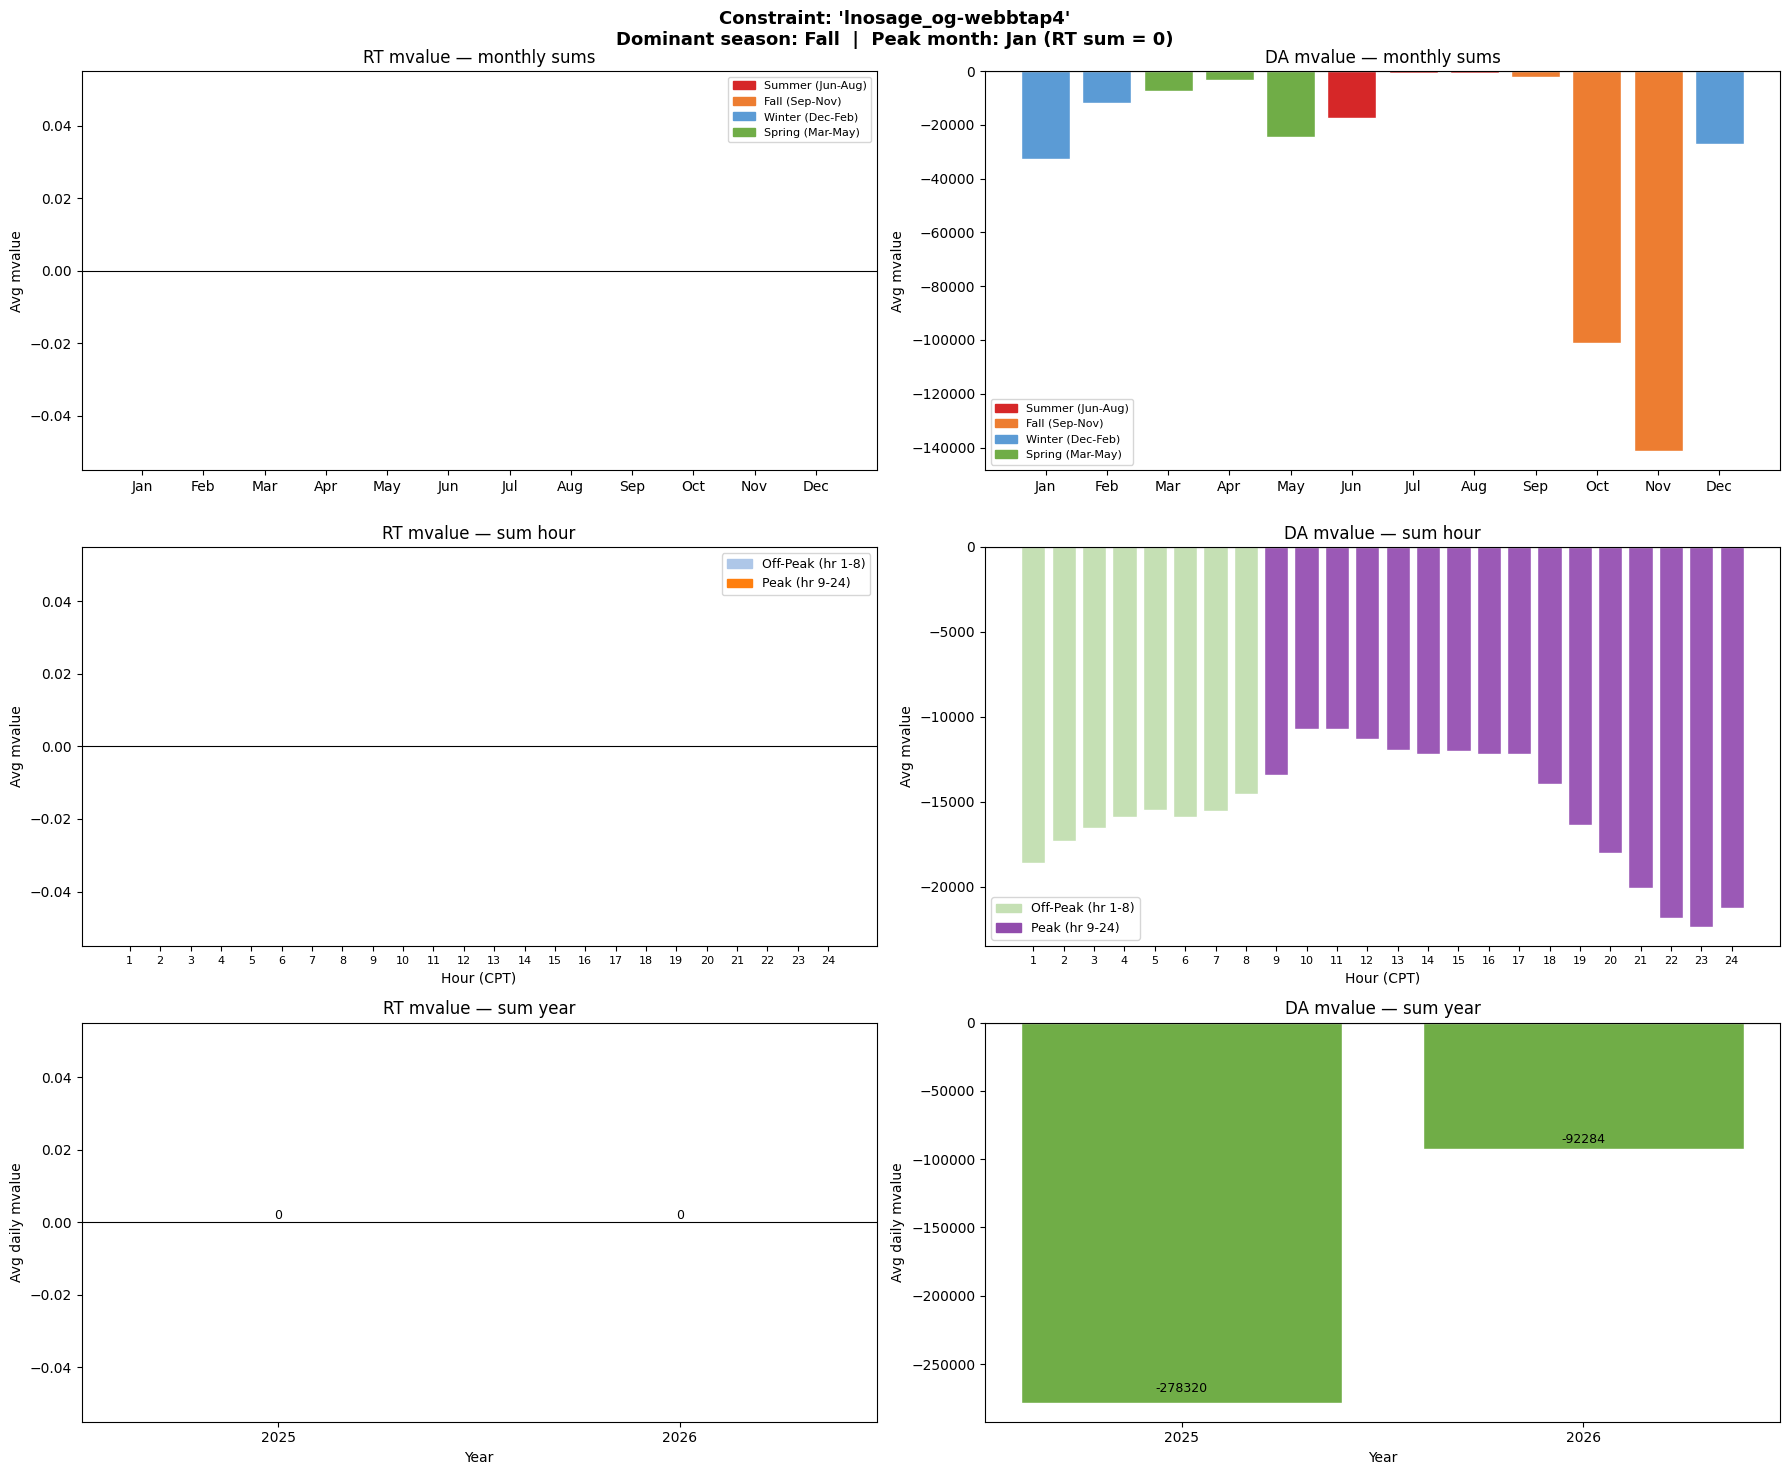

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24): -240659.73  |  off-peak (hr 1-8): -129944.62
'lnosage_og-webbtap4'  |  2026-05-30 → 2026-06-09  |  11 days


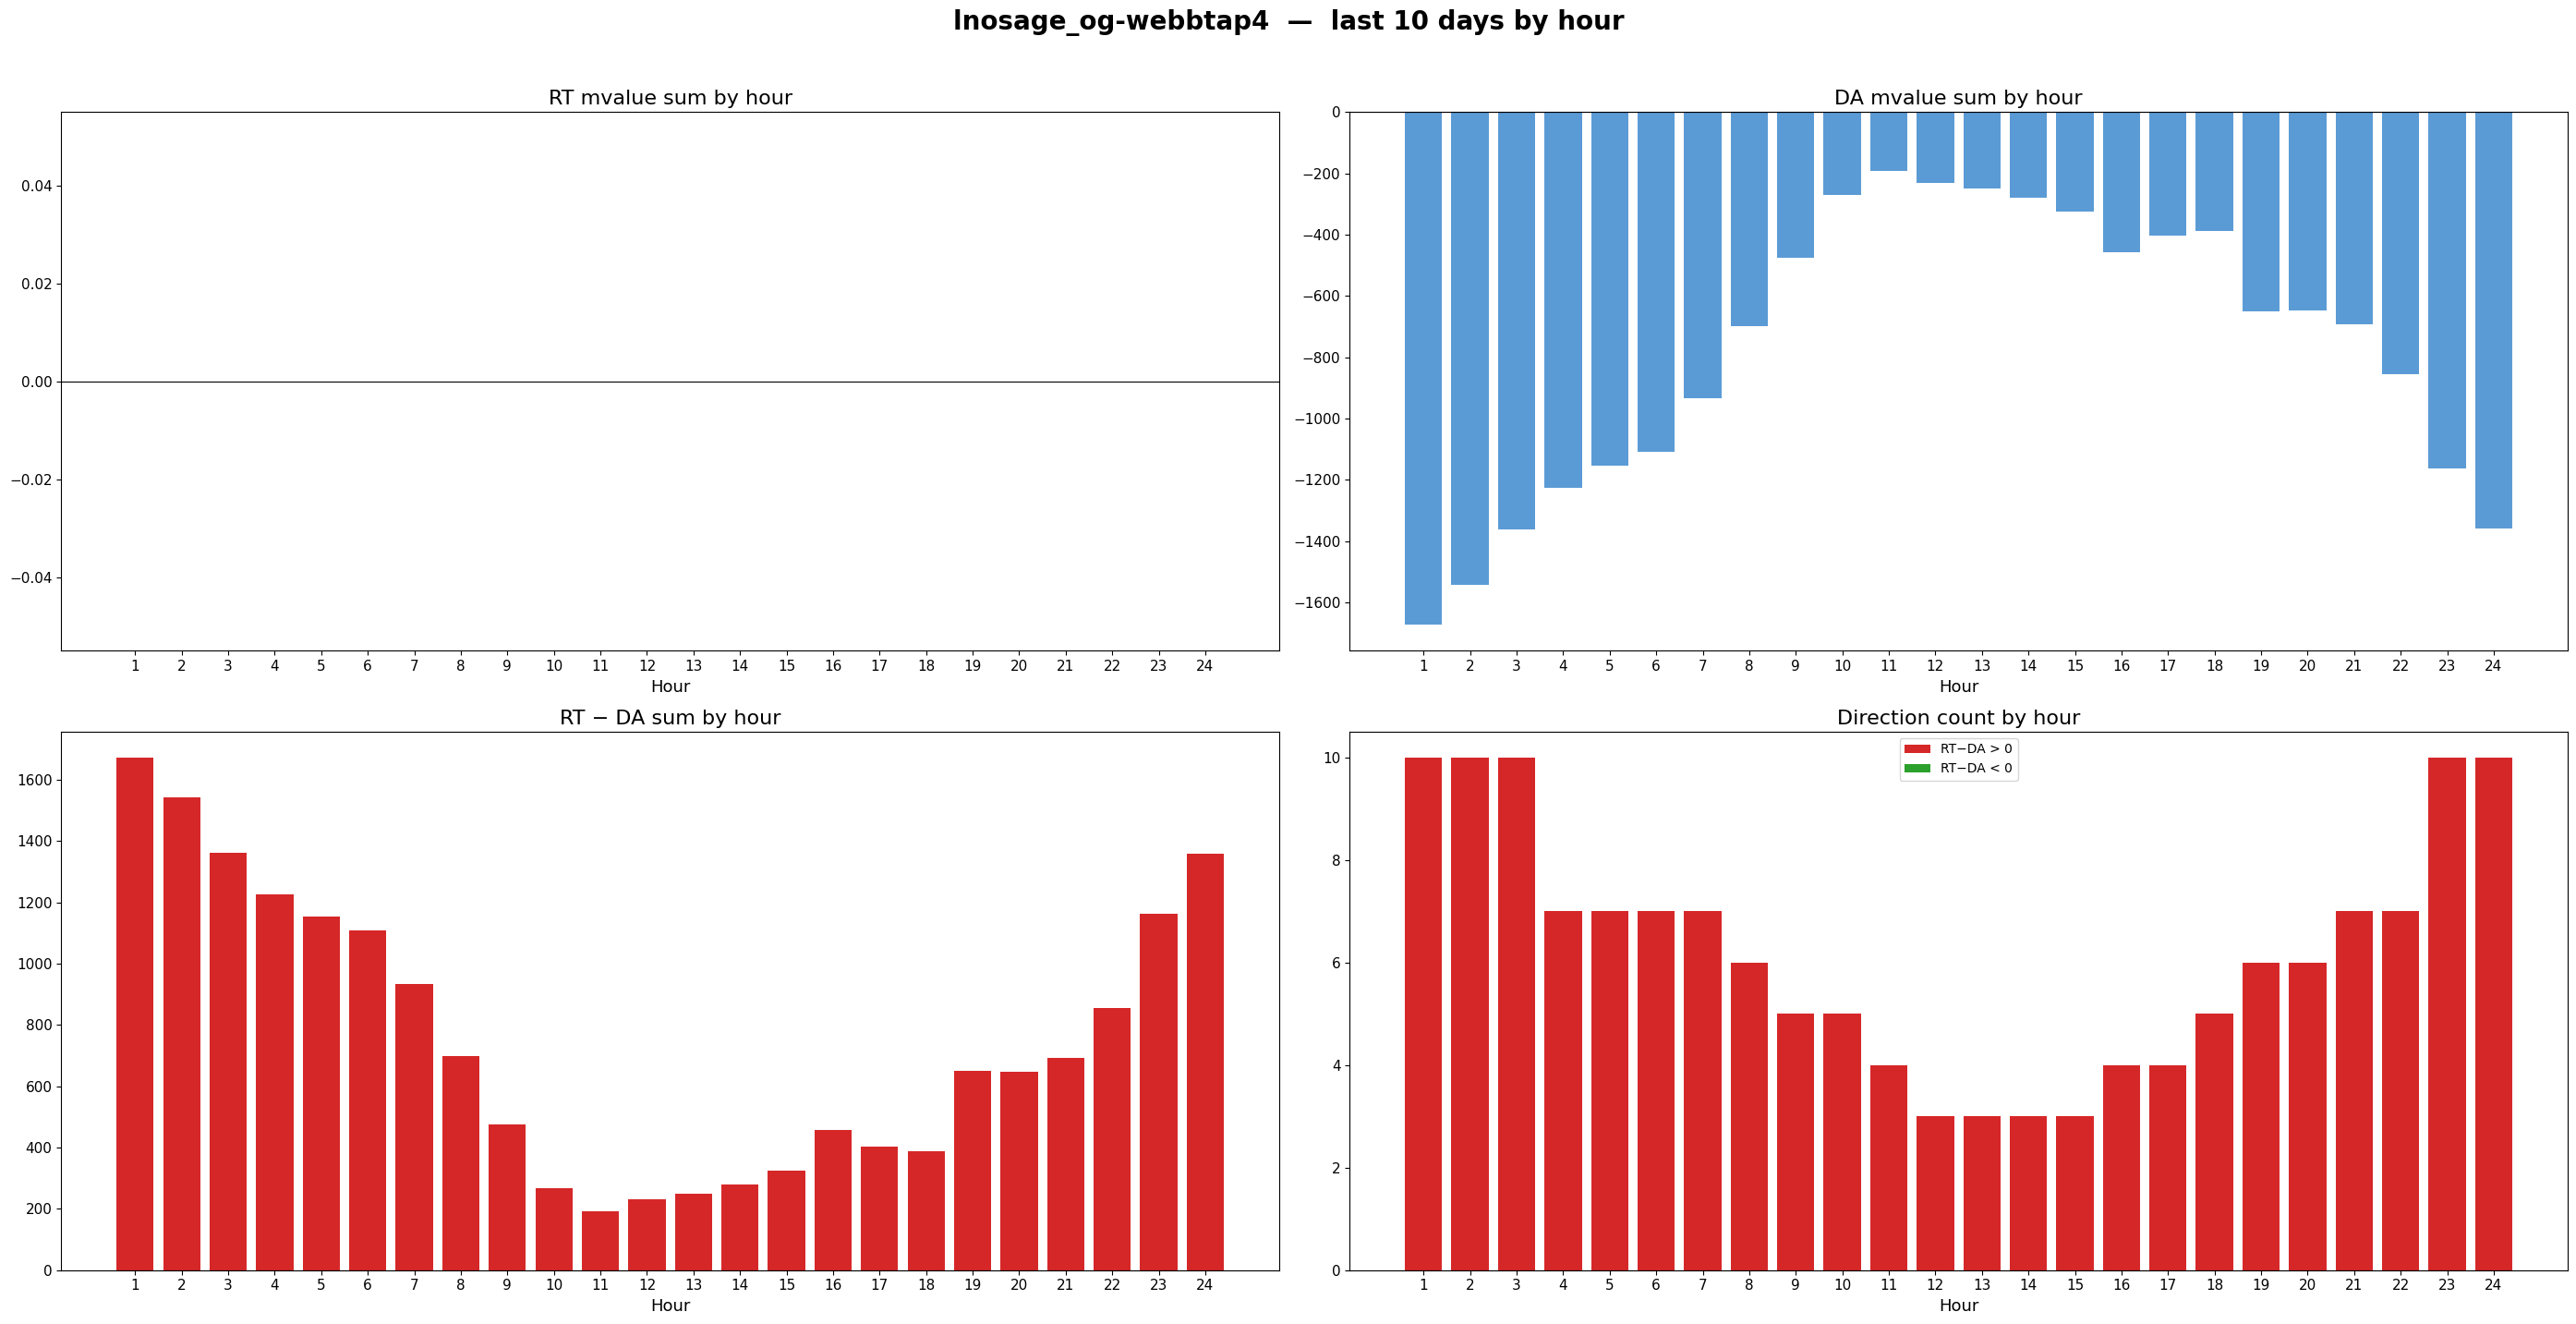


Total rows: 49167

  lnosage_og-webbtap4


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,999,0.0505,0.140689,0.622590,-10.296096,-1.587549,1815.0
1,998,0.0505,0.140689,0.622590,-10.296096,-1.587549,1815.0
2,997,0.0505,0.140689,0.622590,-10.296096,-1.587561,1815.0
3,582,0.0862,0.118937,0.636915,-17.574723,-3.652516,1815.0
4,1399,0.0648,0.084938,0.592837,-13.211625,0.725217,1815.0
5,1489,-0.1067,0.083664,0.492011,21.754326,-1.892017,1815.0
6,499,-0.1224,0.077689,0.502479,24.955291,-2.264634,1815.0
7,546,0.2237,0.028378,0.647934,-45.608649,-2.396512,1815.0
8,847,-0.1035,0.014016,0.441873,21.101900,-5.128224,1815.0
9,830,-0.0635,-0.000341,0.393388,12.946577,-4.978736,1815.0


Constraint  : 'lnrussett-sbrown'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.3170  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnrussett-sbrown,4,rz4_spp_res_zonal_wind_forecast_f,0.317,0.6362,1.01
1,lnrussett-sbrown,4,rz4_spp_res_zonal_load_forecast_f,0.317,0.1545,-0.51


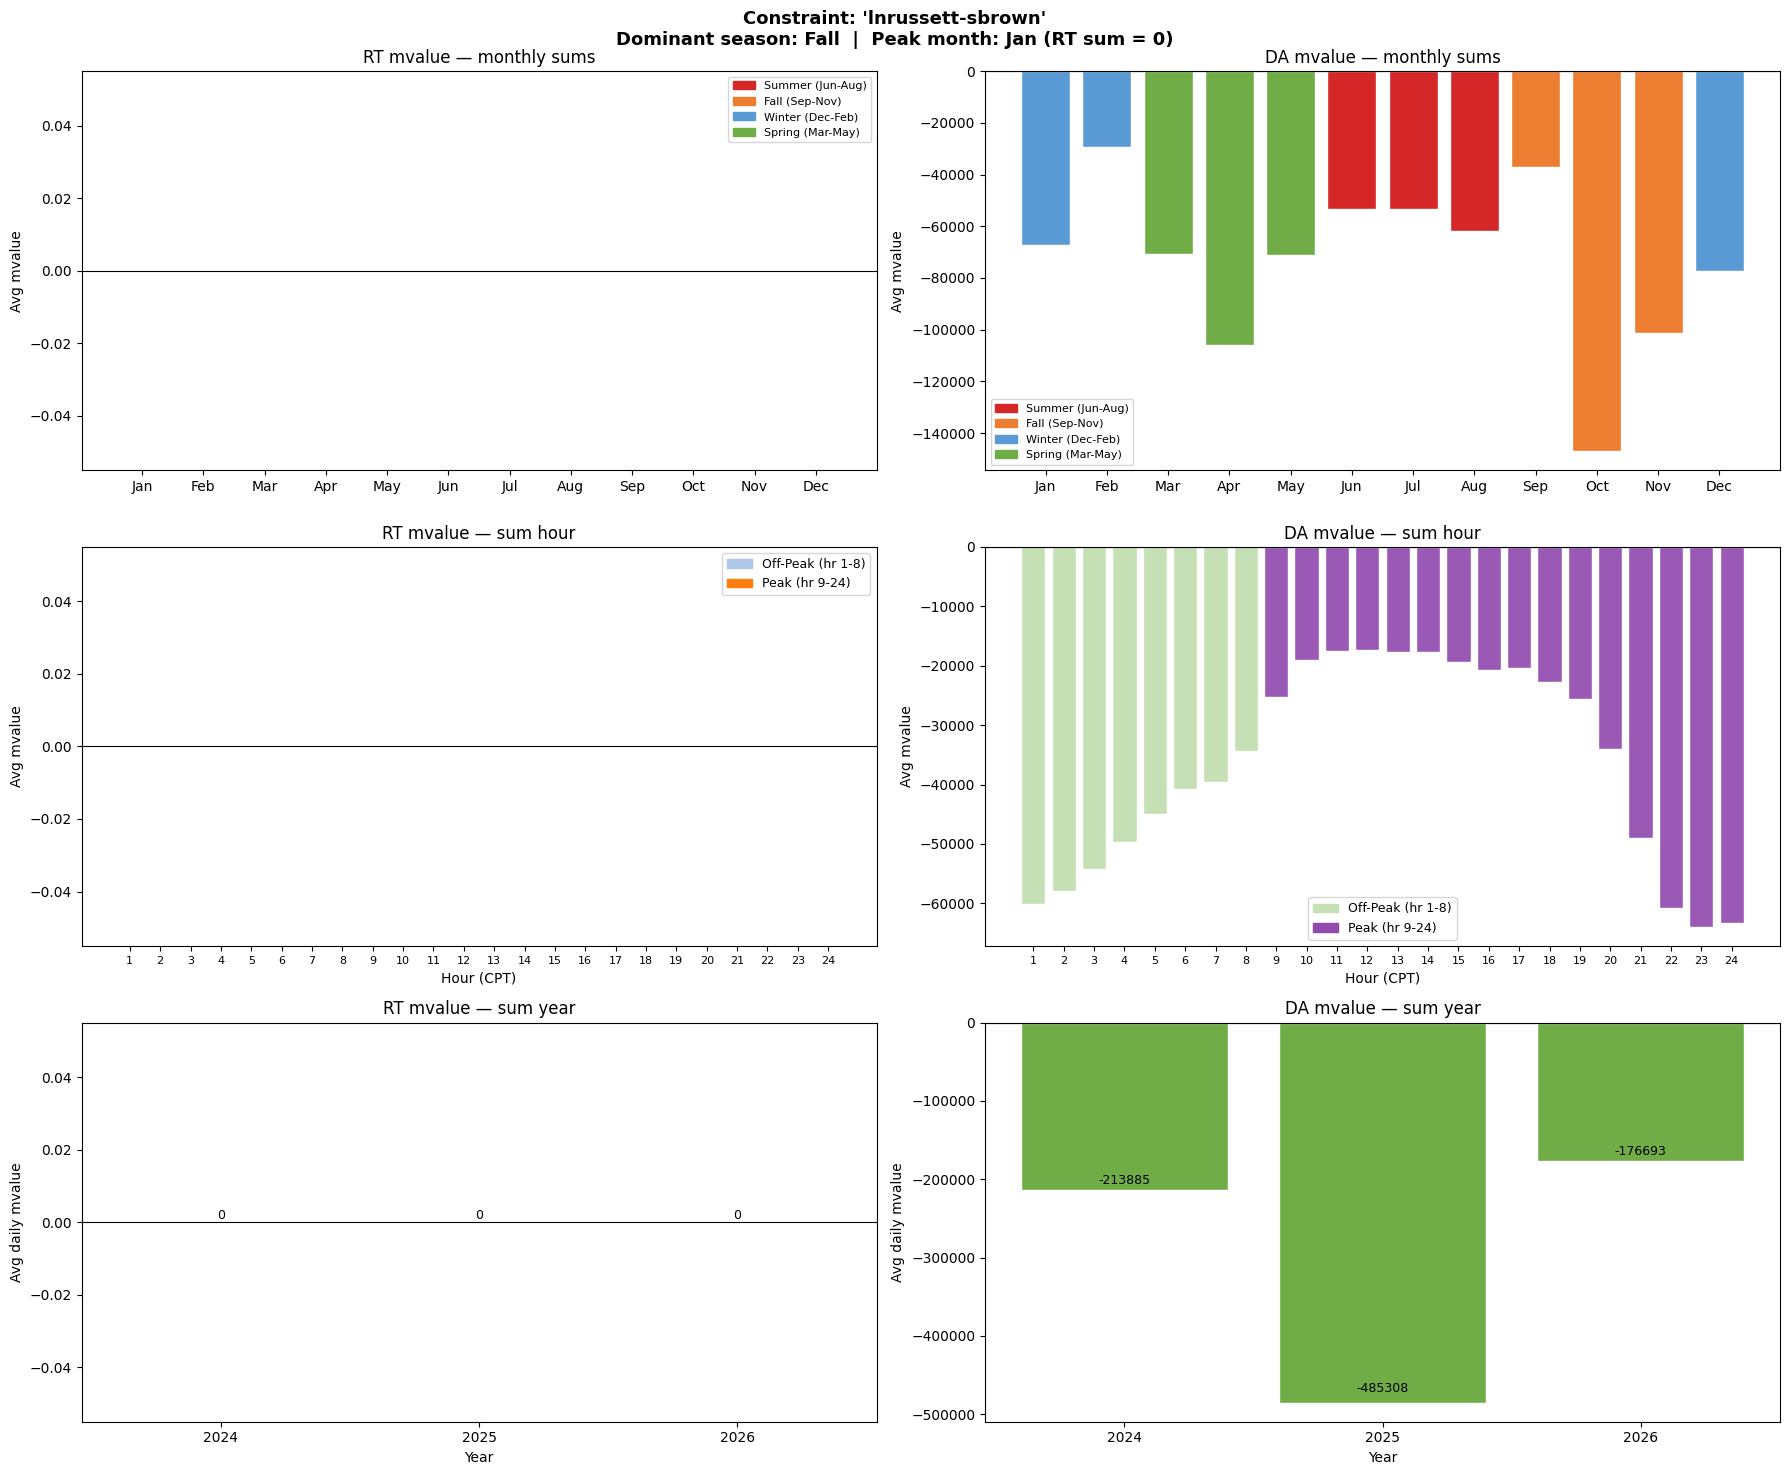

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24): -494359.93  |  off-peak (hr 1-8): -381526.60
'lnrussett-sbrown'  |  2026-05-30 → 2026-06-09  |  11 days


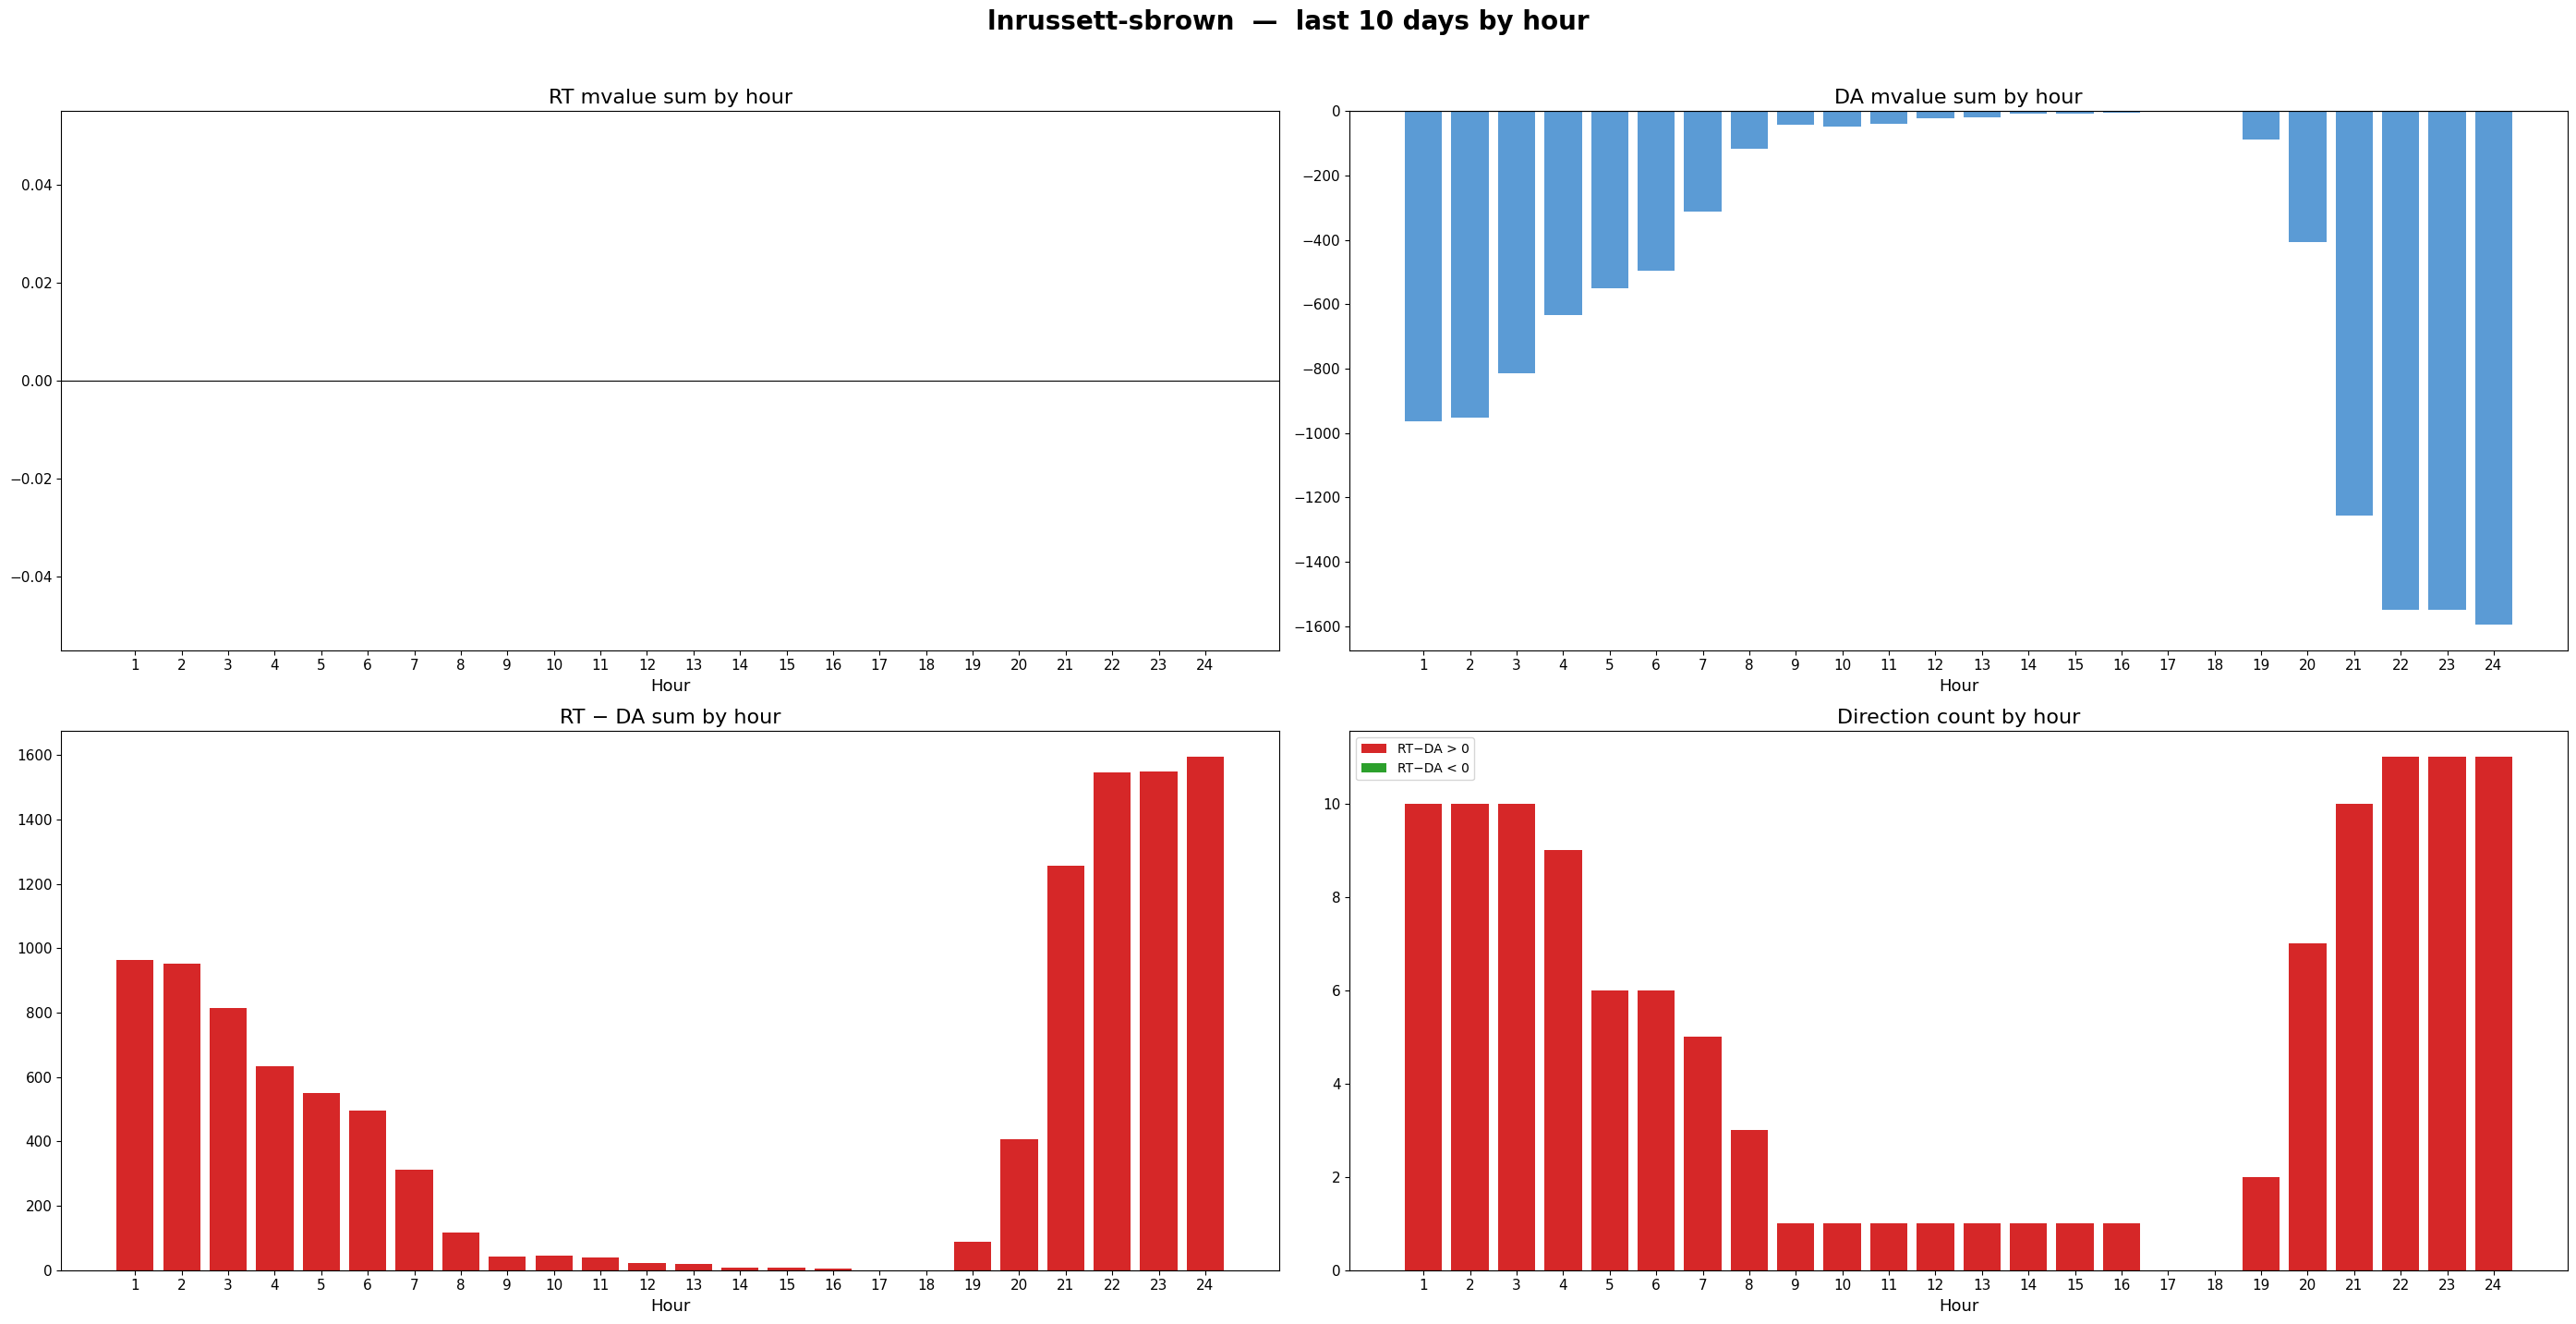


Total rows: 99684

  lnrussett-sbrown


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1384,-0.0960,0.079265,0.472611,15.237692,1.855756,5495.0
1,1499,0.4679,0.052824,0.653139,-74.267876,4.123213,5495.0
2,1532,0.4679,0.052142,0.654256,-73.952690,4.010345,5533.0
3,1533,0.4679,0.052142,0.654256,-73.952690,4.010345,5533.0
4,1229,-0.0646,0.044346,0.409362,10.210181,-2.669909,5533.0
5,492,-0.0539,0.022247,0.432315,8.519021,-1.983654,5533.0
6,1292,-0.0649,0.015984,0.449738,11.089571,-1.892101,2288.0
7,1038,0.0945,0.009608,0.612868,-14.935946,0.449854,5533.0
8,1475,0.0803,-0.015665,0.637087,-12.691603,-1.222105,5533.0
9,1522,0.1086,-0.027280,0.618444,-18.556663,0.119291,2288.0


In [ ]:
from IPython.display import display, HTML
row_counts = hourly_mvalue.groupby('monitored').size().sort_values()
print(row_counts.to_string())

for name in row_counts.index:
    display(HTML(f'''
    <hr style="border: 3px solid black; margin: 30px 0;">
    <h1 style="background:#2c3e50; color:white; padding:12px 20px; border-radius:6px; font-family:monospace;">
        {name} &nbsp;<span style="font-size:0.6em; color:#aaa;">({row_counts[name]:,} rows)</span>
    </h1>
    <hr style="border: 1px solid #aaa; margin-bottom: 20px;">
    '''))

    analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, 4, 95)
    plot_constraint_seasonality(hourly_mvalue, name)
    plot_recent_hourly_distribution(hourly_mvalue, name, bid_dt, days=10)
    table = get_constraints_node_price(hourly_mvalue, dfax, [name])
    get_metrics_for_nodes(table)

In [5]:
# name = 'lnraun-tekamho'
# zone= 1
# analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, zone, 90)
# plot_constraint_seasonality(hourly_mvalue, name)
# table = get_constraints_node_price(hourly_mvalue, dfax, [name])
# get_metrics_for_nodes(table)

In [5]:
fundamentals = get_weather_date(hourly_mvalue, bid_dt)

Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']


In [6]:
tomorrow_pct = predict_tomorrow_percentile(fundamentals, bid_dt)


--- Zone 1 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,1067.8,41.9,4688.2,93.5
1,2,1197.5,41.9,4462.1,93.5
2,3,1275.2,48.4,4380.3,96.8
3,4,1253.6,51.6,4392.0,96.8
4,5,1186.7,51.6,4387.9,93.5
5,6,1155.4,51.6,4547.8,96.8
6,7,1210.4,51.6,4715.1,93.5
7,8,1388.0,64.5,4877.6,96.8
8,9,1689.6,83.9,5024.0,90.3
9,10,2043.6,93.5,5177.2,90.3



--- Zone 2 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,6025.2,93.5,775.5,96.8
1,2,6024.9,93.5,746.3,96.8
2,3,5992.7,87.1,706.8,93.5
3,4,5938.2,87.1,699.1,93.5
4,5,5970.6,87.1,699.0,93.5
5,6,6010.3,93.5,714.8,93.5
6,7,5945.3,93.5,719.1,74.2
7,8,5797.3,93.5,738.6,87.1
8,9,5673.7,100.0,774.9,90.3
9,10,5669.9,100.0,807.4,90.3



--- Zone 3 ---


...


--- Zone 5 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,1891.4,29.0,3709.4,87.1
1,2,1974.3,29.0,3636.0,90.3
2,3,2102.3,41.9,3553.7,67.7
3,4,2174.9,41.9,3552.5,67.7
4,5,2285.6,58.1,3614.3,83.9
5,6,2416.0,71.0,3683.5,90.3
6,7,2514.7,77.4,3803.6,77.4
7,8,2593.7,80.6,3975.9,93.5
8,9,2672.2,83.9,4056.5,96.8
9,10,2778.2,87.1,4105.9,93.5



--- Zone 21 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,640.4,32.3,3055.9,87.1
1,2,642.7,32.3,2896.8,90.3
2,3,705.5,54.8,2794.8,87.1
3,4,833.2,93.5,2697.2,83.9
4,5,922.1,100.0,2632.8,83.9
5,6,957.4,100.0,2623.2,83.9
6,7,987.4,100.0,2670.5,80.6
7,8,985.4,100.0,2754.1,87.1
8,9,989.3,100.0,2866.8,90.3
9,10,995.2,100.0,2951.2,90.3



--- Summary (median pct by zone / peak) ---
1: ow: 96, fw: 50, ol: 58, fl: 93
2: ow: 96, fw: 90, ol: 62, fl: 93
3: ow: 70, fw: 96, ol: 96, fl: 100
4: ow: 80, fw: 95, ol: 96, fl: 98
5: ow: 93, fw: 50, ol: 71, fl: 80
21: ow: 96, fw: 74, ol: 80, fl: 83
